<a href="https://colab.research.google.com/github/PromitMukherjee/Machine_learning_Algorithm/blob/main/Supervised_Learning/Decision_Tree_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unified Decision Tree Regressor

This repository presents a **Unified Decision Tree Regressor** implemented from scratch using only NumPy and Matplotlib. It serves as a comprehensive educational tool to explore various aspects of decision tree construction and pruning, specifically tailored for regression tasks. The implementation includes:

*   **Multiple Splitting Criteria:** `squared_error`, `friedman_mse`, `absolute_error`, `poisson`, and `variance`.
*   **Diverse Split Strategies:** `Threshold` (for numerical features) and `Category_Subset` (for categorical features).
*   **Pruning Methods:** `Pre-pruning` (stopping tree growth early) and `Post-pruning` (cost-complexity pruning).

The notebook benchmarks 20 different configurations of the regressor across these criteria, strategies, and pruning types to analyze their impact on predictive accuracy, computational efficiency, and model complexity.

## Core `UnifiedDecisionTreeRegressor` Class

The `UnifiedDecisionTreeRegressor` class is designed to handle different regression criteria by abstracting the impurity calculation and leaf prediction logic. Key methods include:

*   `_calc_leaf_pred(y)`: Determines the prediction at a leaf node (mean for most criteria, median for `absolute_error`).
*   `_calc_impurity(y)`: Calculates the impurity of a node based on the chosen criterion (e.g., variance for `squared_error`, mean absolute deviation for `absolute_error`, deviance for `poisson`).
*   `_impurity_decrease(...)`: Computes the reduction in impurity achieved by a potential split, which is the primary metric for selecting the best split.
*   `_build_tree(...)`: Recursively constructs the tree, incorporating pre-pruning conditions such as `max_depth`, `min_samples_split`, and `min_samples_leaf`.
*   `_find_best_split(...)`: Iterates through features and potential split points (thresholds for numerical, subsets for categorical) to find the split that maximizes impurity decrease.
*   `_post_prune(...)`: Implements cost-complexity pruning (CCP) by comparing the cost of a subtree with the cost of collapsing it into a single leaf, based on the `ccp_alpha` parameter.

## Data Generation and Benchmarking Setup

To thoroughly evaluate the different configurations, a synthetic dataset is generated with both a continuous numerical feature and a categorical feature. The target variable (`y_synthetic`) is designed to have a non-linear relationship with the features and includes random noise, making it suitable for a regression task. The target values are also ensured to be non-negative, which is crucial for the `poisson` criterion.

The benchmarking process involves:

1.  **20 Unique Configurations:** Every combination of the 5 criteria, 2 split strategies, and 2 pruning methods is tested.
2.  **Feature Selection for Split Strategy:** For `Threshold` splits, only the numerical feature is used. For `Category_Subset` splits, only the categorical feature is used. This prevents inappropriate application of split strategies.
3.  **Performance Metrics:** For each configuration, the following are recorded:
    *   `R2_Score`: Coefficient of determination.
    *   `MSE`: Mean Squared Error.
    *   `MAE`: Mean Absolute Error.
    *   `Fit_Time_ms`: Time taken to train the model.
    *   `Infer_Time_ms`: Time taken to make predictions.
    *   `Depth`: Maximum depth of the tree.
    *   `Leaves`: Number of leaf nodes.
    *   `Nodes`: Total number of nodes in the tree.

These metrics allow for a comprehensive analysis of accuracy, efficiency, and model complexity.



                 DECISION TREE REGRESSOR RESULTS
Model                                                R²         MSE     Depth    Leaves
------------------------------------------------------------------------------------------
Squared Error - Threshold - Pre                  1.0000      0.0000        13        80
Squared Error - Threshold - Post                 0.9835      2.0022         4         9
Squared Error - Category_Subset - Pre            1.0000      0.0000        10        80
Squared Error - Category_Subset - Post           0.9949      0.6215         4        10


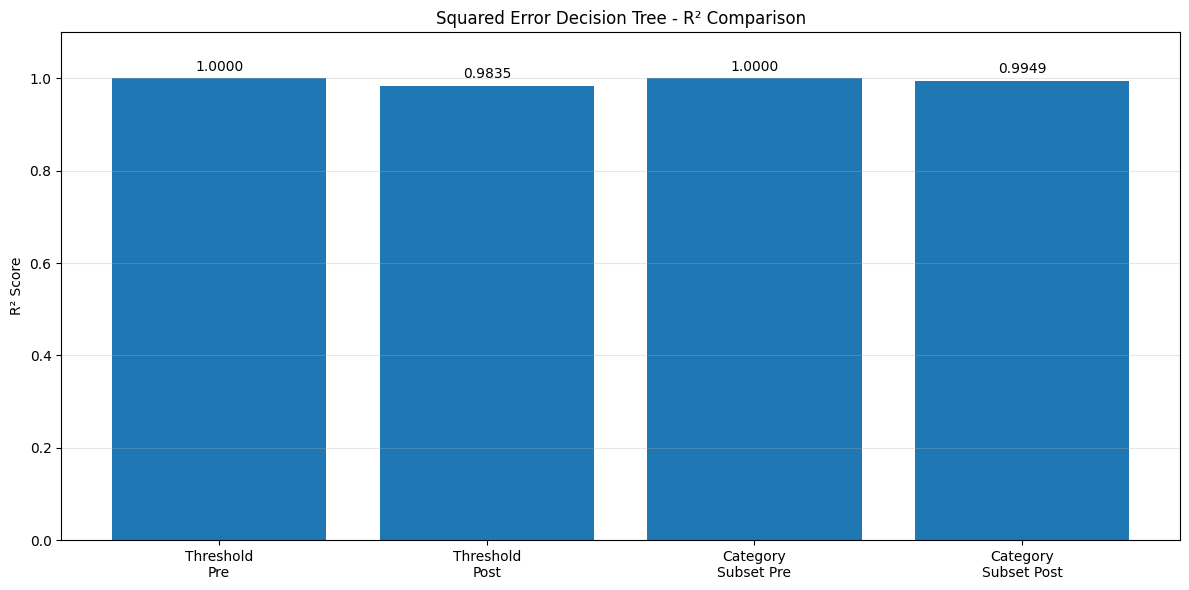

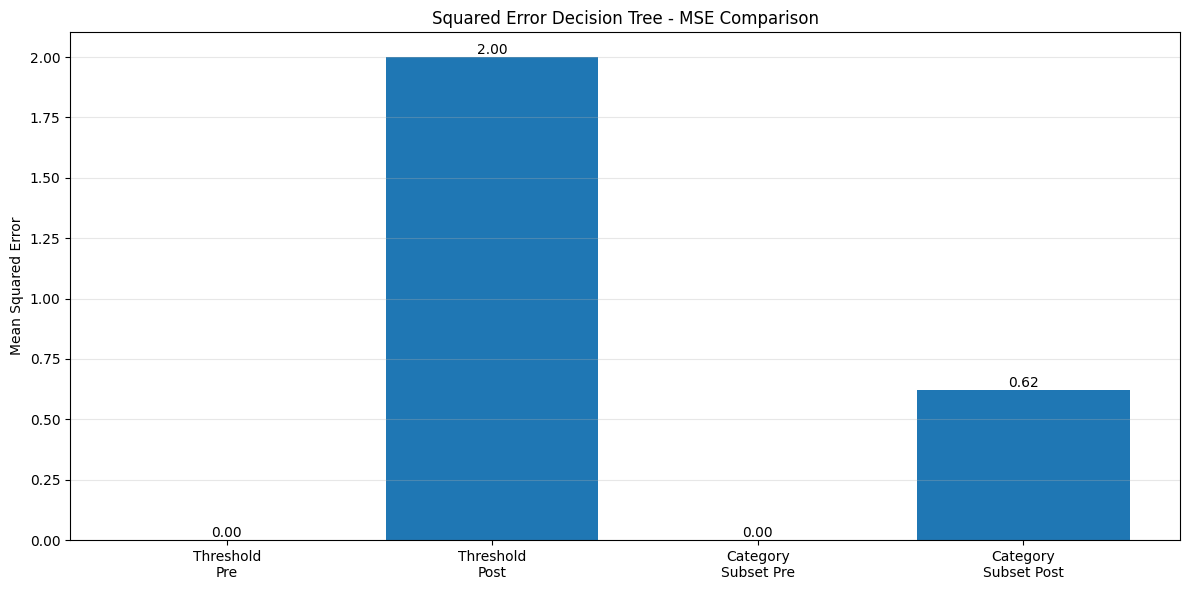

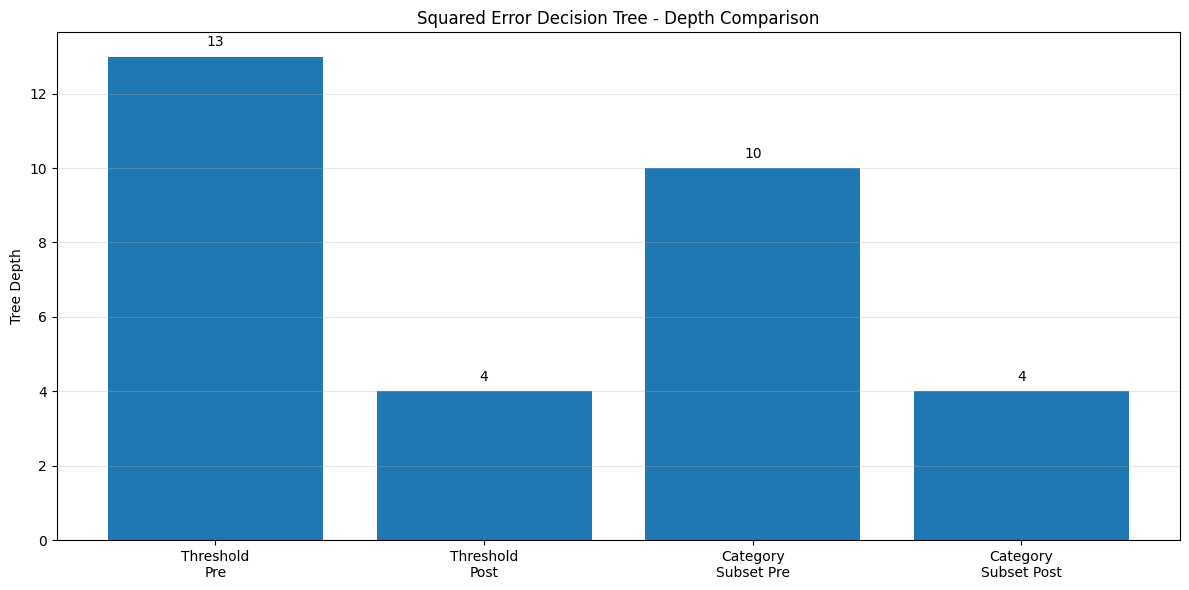

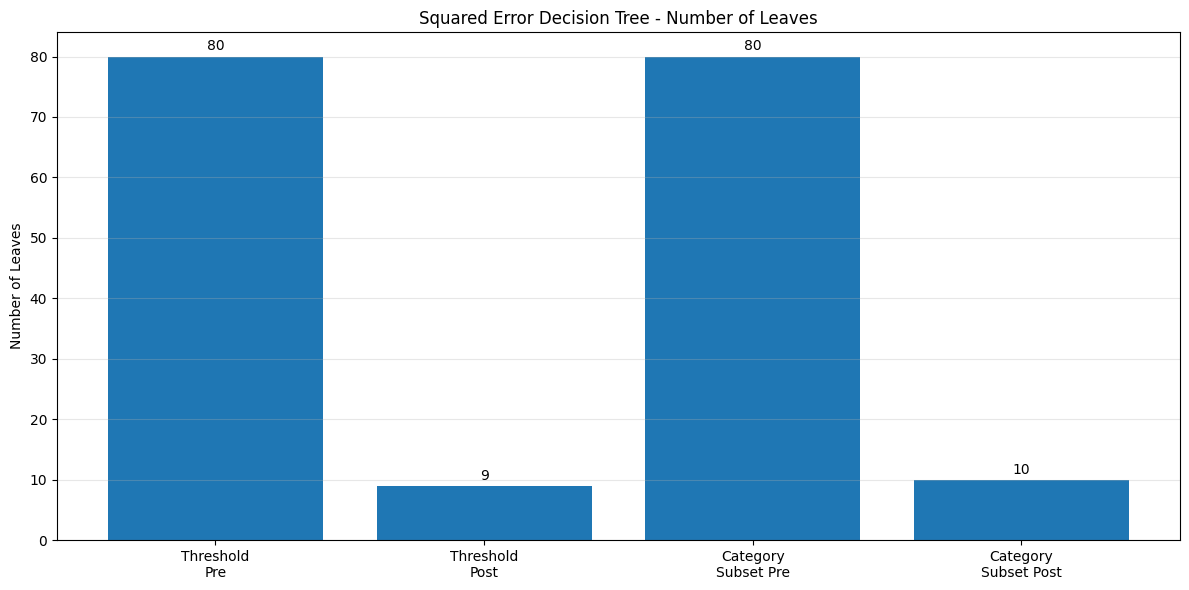

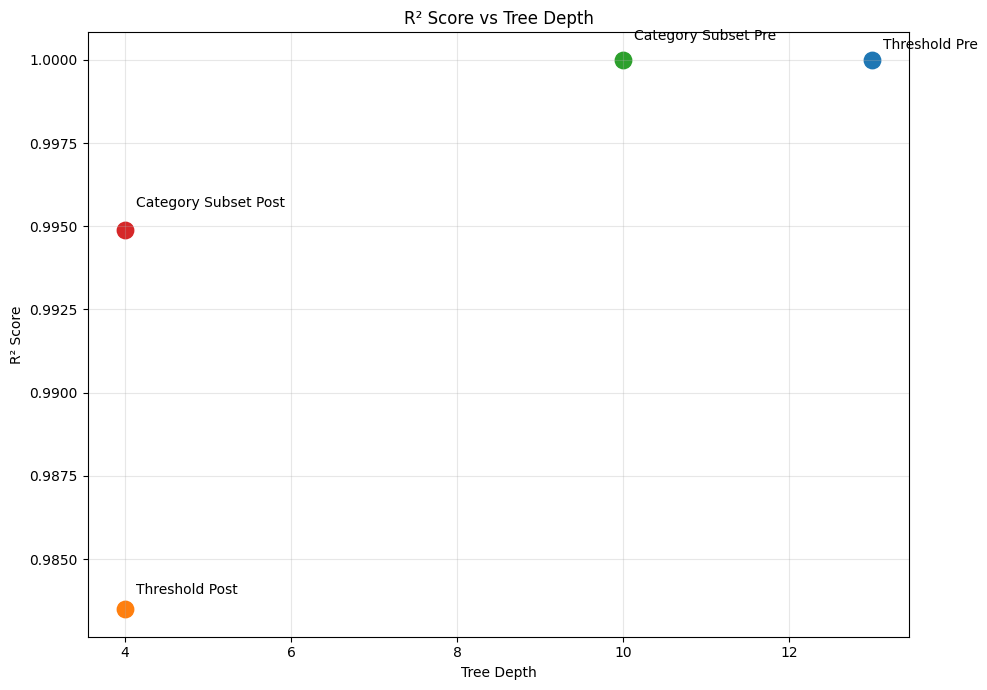

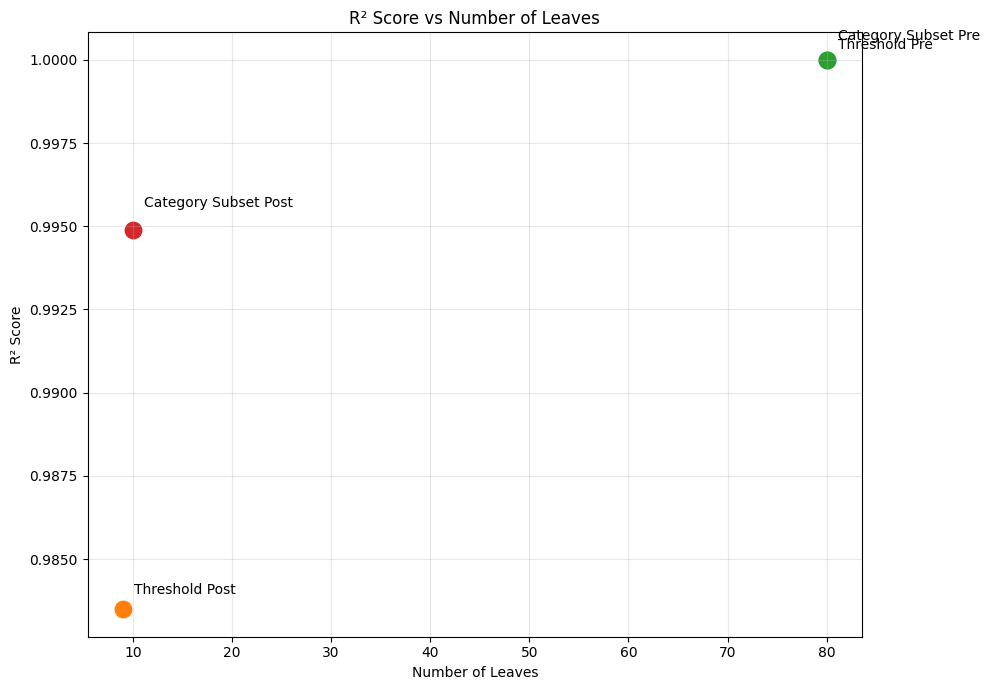

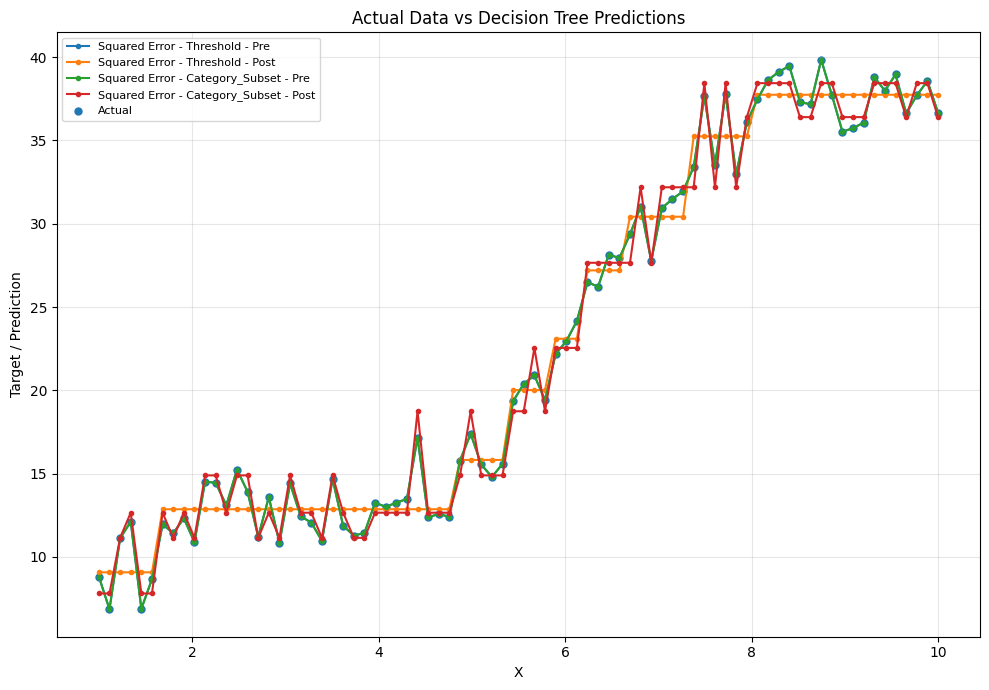

In [ ]:
# Supervised Learning: Decision_Tree_Regression
# squared_erro
# ============================================================
# DECISION TREE REGRESSOR FROM SCRATCH
#
# Criterion:
#     squared_error
#
# Split strategies:
#     Threshold
#     Category_Subset
#
# Pruning:
#     Pre
#     Post
#
# No sklearn is used.
# Only NumPy and Matplotlib are used.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        split_value=None,
        category_subset=None,
        left=None,
        right=None,
        prediction=None,
        is_leaf=False
    ):

        self.feature_index = feature_index
        self.split_value = split_value
        self.category_subset = category_subset

        self.left = left
        self.right = right

        # Mean target value at this node
        self.prediction = prediction

        self.is_leaf = is_leaf


# ============================================================
# 2. DECISION TREE REGRESSOR
# ============================================================

class DecisionTreeRegressor:

    def __init__(
        self,
        criterion="squared_error",
        split_strategy="Threshold",
        pruning="Pre",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0,
        random_state=None
    ):

        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes
        self.min_impurity_decrease = min_impurity_decrease

        self.ccp_alpha = ccp_alpha
        self.random_state = random_state

        self.rng = np.random.default_rng(
            random_state
        )

        self.root_ = None

        self.n_features_in_ = None

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0


    # ========================================================
    # 3. FIT
    # ========================================================

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y, dtype=float).ravel()

        if X.ndim != 2:
            raise ValueError(
                "X must be a 2-dimensional array."
            )

        if X.shape[0] != y.shape[0]:
            raise ValueError(
                f"X and y have inconsistent numbers of samples: "
                f"{X.shape[0]} and {y.shape[0]}"
            )

        if X.shape[0] == 0:
            raise ValueError(
                "X and y cannot be empty."
            )

        if self.criterion != "squared_error":
            raise ValueError(
                'This implementation supports '
                'criterion="squared_error".'
            )

        if self.split_strategy not in [
            "Threshold",
            "Category_Subset"
        ]:
            raise ValueError(
                'split_strategy must be "Threshold" '
                'or "Category_Subset".'
            )

        if self.pruning not in [
            "Pre",
            "Post"
        ]:
            raise ValueError(
                'pruning must be "Pre" or "Post".'
            )

        self.n_features_in_ = X.shape[1]

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0

        # Used to enforce max_leaf_nodes
        self._current_leaf_count = 0

        self.root_ = self._build_tree(
            X,
            y,
            depth=0
        )

        # ----------------------------------------------------
        # POST PRUNING
        # ----------------------------------------------------

        if self.pruning == "Post":

            self.root_ = self._post_prune(
                self.root_,
                X,
                y
            )

        # ----------------------------------------------------
        # Final tree statistics
        # ----------------------------------------------------

        self.n_leaves_ = self._count_leaves(
            self.root_
        )

        self.tree_depth_ = self._calculate_depth(
            self.root_
        )

        self.node_count_ = self._count_nodes(
            self.root_
        )

        return self


    # ========================================================
    # 4. MEAN PREDICTION
    # ========================================================

    def _mean_prediction(self, y):

        if len(y) == 0:
            return 0.0

        return float(
            np.mean(y)
        )


    # ========================================================
    # 5. SQUARED ERROR IMPURITY
    #
    # SSE = sum((y_i - mean(y))^2)
    # ========================================================

    def _squared_error(self, y):

        if len(y) == 0:
            return 0.0

        mean = np.mean(y)

        return float(
            np.sum(
                (y - mean) ** 2
            )
        )


    # ========================================================
    # 6. IMPURITY DECREASE
    #
    # Parent SSE - Left SSE - Right SSE
    # ========================================================

    def _impurity_decrease(
        self,
        parent_y,
        left_y,
        right_y
    ):

        parent_error = (
            self._squared_error(parent_y)
        )

        left_error = (
            self._squared_error(left_y)
        )

        right_error = (
            self._squared_error(right_y)
        )

        decrease = (
            parent_error
            -
            left_error
            -
            right_error
        )

        return decrease


    # ========================================================
    # 7. BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth
    ):

        self.node_count_ += 1

        prediction = (
            self._mean_prediction(y)
        )

        # ----------------------------------------------------
        # STOPPING CONDITIONS
        # ----------------------------------------------------

        if self._should_stop(
            X,
            y,
            depth
        ):

            self._current_leaf_count += 1

            return TreeNode(
                prediction=prediction,
                is_leaf=True
            )

        # ----------------------------------------------------
        # FIND BEST SPLIT
        # ----------------------------------------------------

        best_split = self._find_best_split(
            X,
            y
        )

        if best_split is None:

            self._current_leaf_count += 1

            return TreeNode(
                prediction=prediction,
                is_leaf=True
            )

        decrease = (
            best_split["impurity_decrease"]
        )

        # ----------------------------------------------------
        # MIN IMPURITY DECREASE
        # ----------------------------------------------------

        if decrease < self.min_impurity_decrease:

            self._current_leaf_count += 1

            return TreeNode(
                prediction=prediction,
                is_leaf=True
            )

        # ----------------------------------------------------
        # MAX LEAF NODES
        #
        # If splitting would exceed the allowed number of
        # leaves, stop splitting.
        # ----------------------------------------------------

        if (
            self.max_leaf_nodes is not None
            and
            self._current_leaf_count + 2
            >
            self.max_leaf_nodes
        ):

            self._current_leaf_count += 1

            return TreeNode(
                prediction=prediction,
                is_leaf=True
            )

        # ----------------------------------------------------
        # GET SPLIT INFORMATION
        # ----------------------------------------------------

        feature_index = (
            best_split["feature_index"]
        )

        split_value = (
            best_split["split_value"]
        )

        category_subset = (
            best_split["category_subset"]
        )

        left_indices = (
            best_split["left_indices"]
        )

        right_indices = (
            best_split["right_indices"]
        )

        X_left = X[left_indices]
        y_left = y[left_indices]

        X_right = X[right_indices]
        y_right = y[right_indices]

        # ----------------------------------------------------
        # BUILD CHILDREN
        # ----------------------------------------------------

        left_child = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right_child = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return TreeNode(
            feature_index=feature_index,
            split_value=split_value,
            category_subset=category_subset,
            left=left_child,
            right=right_child,
            prediction=prediction,
            is_leaf=False
        )


    # ========================================================
    # 8. PRE-PRUNING / STOPPING CONDITIONS
    # ========================================================

    def _should_stop(
        self,
        X,
        y,
        depth
    ):

        # All target values are identical
        if np.allclose(
            y,
            y[0]
        ):
            return True

        # Maximum depth
        if (
            self.max_depth is not None
            and
            depth >= self.max_depth
        ):
            return True

        # Minimum samples required for splitting
        if (
            len(y)
            <
            self.min_samples_split
        ):
            return True

        # Both children must contain at least
        # min_samples_leaf observations
        if (
            len(y)
            <
            2 * self.min_samples_leaf
        ):
            return True

        return False


    # ========================================================
    # 9. FIND BEST SPLIT
    # ========================================================

    def _find_best_split(
        self,
        X,
        y
    ):

        best_split = None

        best_decrease = -np.inf

        feature_indices = np.arange(
            X.shape[1]
        )

        # ----------------------------------------------------
        # MAX FEATURES
        # ----------------------------------------------------

        if self.max_features is not None:

            if isinstance(
                self.max_features,
                int
            ):

                n_features = min(
                    self.max_features,
                    X.shape[1]
                )

                feature_indices = (
                    self.rng.choice(
                        X.shape[1],
                        size=n_features,
                        replace=False
                    )
                )

        # ----------------------------------------------------
        # SEARCH FEATURES
        # ----------------------------------------------------

        for feature_index in feature_indices:

            column = X[
                :,
                feature_index
            ]

            if self.split_strategy == "Threshold":

                split = (
                    self._find_threshold_split(
                        column,
                        y,
                        feature_index
                    )
                )

            else:

                split = (
                    self._find_category_subset_split(
                        column,
                        y,
                        feature_index
                    )
                )

            if split is not None:

                decrease = (
                    split["impurity_decrease"]
                )

                if decrease > best_decrease:

                    best_decrease = decrease

                    best_split = split

        return best_split


    # ========================================================
    # 10. THRESHOLD SPLIT
    #
    # Example:
    #
    # X <= 5.5
    # X >  5.5
    # ========================================================

    def _find_threshold_split(
        self,
        column,
        y,
        feature_index
    ):

        try:

            values = column.astype(float)

        except:

            return None

        unique_values = np.unique(
            values
        )

        if len(unique_values) < 2:
            return None

        # Midpoints between consecutive values
        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0

        best_split = None

        best_decrease = -np.inf

        for threshold in thresholds:

            left_indices = np.where(
                values <= threshold
            )[0]

            right_indices = np.where(
                values > threshold
            )[0]

            # min_samples_leaf
            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):
                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):
                continue

            left_y = y[
                left_indices
            ]

            right_y = y[
                right_indices
            ]

            decrease = (
                self._impurity_decrease(
                    y,
                    left_y,
                    right_y
                )
            )

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        threshold,

                    "category_subset":
                        None,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 11. CATEGORY SUBSET SPLIT
    #
    # Intended for categorical variables.
    #
    # Example:
    #
    # {A, B}  vs  {C, D}
    #
    # IMPORTANT:
    # If a continuous numeric feature is passed here,
    # every unique numeric value becomes a category.
    # Therefore Category_Subset should normally be used
    # with categorical/string features.
    # ========================================================

    def _find_category_subset_split(
        self,
        column,
        y,
        feature_index
    ):

        categories = np.unique(
            column
        )

        if len(categories) < 2:
            return None

        # ----------------------------------------------------
        # TWO CATEGORIES
        # ----------------------------------------------------

        if len(categories) == 2:

            subsets = [
                {categories[0]}
            ]

        # ----------------------------------------------------
        # MULTIPLE CATEGORIES
        # ----------------------------------------------------

        else:

            subsets = []

            # Exhaustive search is reasonable for small
            # numbers of categories.
            if len(categories) <= 10:

                from itertools import combinations

                first_category = categories[0]

                remaining = categories[1:]

                for r in range(
                    0,
                    len(remaining)
                ):

                    for combo in combinations(
                        remaining,
                        r
                    ):

                        subset = {
                            first_category,
                            *combo
                        }

                        if (
                            len(subset)
                            <
                            len(categories)
                        ):

                            subsets.append(
                                subset
                            )

            # ------------------------------------------------
            # For many categories, use an ordered heuristic.
            # ------------------------------------------------

            else:

                category_means = []

                for category in categories:

                    mask = (
                        column == category
                    )

                    category_y = y[
                        mask
                    ]

                    mean_value = np.mean(
                        category_y
                    )

                    category_means.append(
                        (
                            category,
                            mean_value
                        )
                    )

                category_means.sort(
                    key=lambda x: x[1]
                )

                ordered_categories = [
                    x[0]
                    for x in category_means
                ]

                for i in range(
                    1,
                    len(ordered_categories)
                ):

                    subsets.append(
                        set(
                            ordered_categories[:i]
                        )
                    )

        best_split = None

        best_decrease = -np.inf

        for subset in subsets:

            left_mask = np.array([
                value in subset
                for value in column
            ])

            right_mask = ~left_mask

            left_indices = np.where(
                left_mask
            )[0]

            right_indices = np.where(
                right_mask
            )[0]

            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):
                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):
                continue

            left_y = y[
                left_indices
            ]

            right_y = y[
                right_indices
            ]

            decrease = (
                self._impurity_decrease(
                    y,
                    left_y,
                    right_y
                )
            )

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        None,

                    "category_subset":
                        subset,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 12. PREDICT ONE SAMPLE
    # ========================================================

    def _predict_one(
        self,
        x
    ):

        node = self.root_

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            # ------------------------------------------------
            # Threshold split
            # ------------------------------------------------

            if (
                node.category_subset
                is None
            ):

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            # ------------------------------------------------
            # Category subset split
            # ------------------------------------------------

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 13. PREDICT
    # ========================================================

    def predict(self, X):

        X = np.asarray(X)

        if X.ndim == 1:

            X = X.reshape(
                1,
                -1
            )

        return np.array([
            self._predict_one(x)
            for x in X
        ])


    # ========================================================
    # 14. R² SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        y = np.asarray(
            y,
            dtype=float
        )

        predictions = self.predict(
            X
        )

        ss_res = np.sum(
            (y - predictions) ** 2
        )

        ss_tot = np.sum(
            (y - np.mean(y)) ** 2
        )

        if ss_tot == 0:

            return 1.0

        return 1.0 - (
            ss_res / ss_tot
        )


    # ========================================================
    # 15. MSE
    # ========================================================

    def mean_squared_error(
        self,
        X,
        y
    ):

        y = np.asarray(
            y,
            dtype=float
        )

        predictions = self.predict(
            X
        )

        return np.mean(
            (y - predictions) ** 2
        )


    # ========================================================
    # 16. COUNT LEAVES
    # ========================================================

    def _count_leaves(
        self,
        node
    ):

        if node is None:
            return 0

        if node.is_leaf:
            return 1

        return (
            self._count_leaves(
                node.left
            )
            +
            self._count_leaves(
                node.right
            )
        )


    # ========================================================
    # 17. COUNT NODES
    # ========================================================

    def _count_nodes(
        self,
        node
    ):

        if node is None:
            return 0

        if node.is_leaf:
            return 1

        return (
            1
            +
            self._count_nodes(
                node.left
            )
            +
            self._count_nodes(
                node.right
            )
        )


    # ========================================================
    # 18. CALCULATE TREE DEPTH
    # ========================================================

    def _calculate_depth(
        self,
        node
    ):

        if node is None:
            return 0

        if node.is_leaf:
            return 0

        return (
            1
            +
            max(
                self._calculate_depth(
                    node.left
                ),
                self._calculate_depth(
                    node.right
                )
            )
        )


    # ========================================================
    # 19. GET DEPTH
    # ========================================================

    def get_depth(self):

        return self.tree_depth_


    # ========================================================
    # 20. GET NUMBER OF LEAVES
    # ========================================================

    def get_n_leaves(self):

        return self.n_leaves_


    # ========================================================
    # 21. POST PRUNING
    #
    # Cost-complexity:
    #
    #     Cost = SSE + alpha * number_of_leaves
    #
    # Compare:
    #
    #     Subtree cost
    #
    # with
    #
    #     Leaf cost
    # ========================================================

    def _post_prune(
        self,
        node,
        X,
        y
    ):

        if node is None:
            return node

        if node.is_leaf:
            return node

        if len(y) == 0:
            return node

        # ----------------------------------------------------
        # Find samples belonging to each child
        # ----------------------------------------------------

        left_indices, right_indices = (
            self._split_indices_for_node(
                node,
                X
            )
        )

        X_left = X[
            left_indices
        ]

        y_left = y[
            left_indices
        ]

        X_right = X[
            right_indices
        ]

        y_right = y[
            right_indices
        ]

        # ----------------------------------------------------
        # Recursively prune children
        # ----------------------------------------------------

        node.left = self._post_prune(
            node.left,
            X_left,
            y_left
        )

        node.right = self._post_prune(
            node.right,
            X_right,
            y_right
        )

        # ----------------------------------------------------
        # Error of current subtree
        # ----------------------------------------------------

        subtree_predictions = np.array([
            self._predict_node(
                node,
                x
            )
            for x in X
        ])

        subtree_error = np.sum(
            (
                y
                -
                subtree_predictions
            ) ** 2
        )

        # ----------------------------------------------------
        # Error if current node becomes a leaf
        # ----------------------------------------------------

        leaf_prediction = (
            np.mean(y)
        )

        leaf_error = np.sum(
            (
                y
                -
                leaf_prediction
            ) ** 2
        )

        # ----------------------------------------------------
        # Number of leaves
        # ----------------------------------------------------

        subtree_leaves = (
            self._count_leaves(node)
        )

        # ----------------------------------------------------
        # Cost-complexity
        # ----------------------------------------------------

        subtree_cost = (
            subtree_error
            +
            self.ccp_alpha
            *
            subtree_leaves
        )

        leaf_cost = (
            leaf_error
            +
            self.ccp_alpha
        )

        # ----------------------------------------------------
        # Replace subtree by leaf
        # ----------------------------------------------------

        if leaf_cost <= subtree_cost:

            node = TreeNode(
                prediction=float(
                    leaf_prediction
                ),
                is_leaf=True
            )

        return node


    # ========================================================
    # 22. SPLIT INDICES FOR EXISTING NODE
    # ========================================================

    def _split_indices_for_node(
        self,
        node,
        X
    ):

        values = X[
            :,
            node.feature_index
        ]

        if (
            node.category_subset
            is None
        ):

            values_float = values.astype(
                float
            )

            left_mask = (
                values_float
                <=
                node.split_value
            )

        else:

            left_mask = np.array([
                value in
                node.category_subset
                for value in values
            ])

        right_mask = ~left_mask

        return (
            np.where(left_mask)[0],
            np.where(right_mask)[0]
        )


    # ========================================================
    # 23. PREDICT FROM A SPECIFIC NODE
    # ========================================================

    def _predict_node(
        self,
        node,
        x
    ):

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            if (
                node.category_subset
                is None
            ):

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 24. PRINT TREE
    #
    # NOT called automatically.
    #
    # Use:
    #
    # model.print_tree()
    #
    # only when you actually want to inspect a tree.
    # ========================================================

    def print_tree(
        self,
        node=None,
        depth=0
    ):

        if node is None:
            node = self.root_

        indentation = (
            "    " * depth
        )

        if node.is_leaf:

            print(
                indentation
                +
                f"Leaf: "
                f"prediction="
                f"{node.prediction:.4f}"
            )

            return

        if (
            node.category_subset
            is None
        ):

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"<= "
                f"{node.split_value:.4f}"
            )

        else:

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"in "
                f"{node.category_subset}"
            )

        self.print_tree(
            node.left,
            depth + 1
        )

        self.print_tree(
            node.right,
            depth + 1
        )


# ============================================================
# 25. CREATE REGRESSION DATA
# ============================================================

rng = np.random.default_rng(
    42
)

# 80 observations
X = np.linspace(
    1,
    10,
    80
).reshape(
    -1,
    1
)

# Non-linear regression relationship
y = (
    4 * X[:, 0]
    +
    5 * np.sin(
        X[:, 0]
    )
    +
    rng.normal(
        0,
        2,
        size=80
    )
)


# ============================================================
# 26. FOUR REQUIRED CONFIGURATIONS
# ============================================================

models = {

    "Squared Error - Threshold - Pre":
        DecisionTreeRegressor(
            criterion="squared_error",
            split_strategy="Threshold",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),

    "Squared Error - Threshold - Post":
        DecisionTreeRegressor(
            criterion="squared_error",
            split_strategy="Threshold",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=10.0,
            random_state=42
        ),

    "Squared Error - Category_Subset - Pre":
        DecisionTreeRegressor(
            criterion="squared_error",
            split_strategy="Category_Subset",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),

    "Squared Error - Category_Subset - Post":
        DecisionTreeRegressor(
            criterion="squared_error",
            split_strategy="Category_Subset",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=10.0,
            random_state=42
        )
}


# ============================================================
# 27. TRAIN ALL MODELS
#
# IMPORTANT:
# We do NOT call print_tree() here.
#
# Therefore the huge tree output is removed.
# ============================================================

results = {}

for name, model in models.items():

    model.fit(
        X,
        y
    )

    predictions = model.predict(
        X
    )

    r2 = model.score(
        X,
        y
    )

    mse = model.mean_squared_error(
        X,
        y
    )

    depth = model.get_depth()

    leaves = model.get_n_leaves()

    results[name] = {

        "R2": r2,

        "MSE": mse,

        "Depth": depth,

        "Leaves": leaves
    }


# ============================================================
# 28. CLEAN RESULT TABLE
# ============================================================

print("\n")
print("=" * 90)

print(
    "                 DECISION TREE REGRESSOR RESULTS"
)

print("=" * 90)

print(
    f"{'Model':<45}"
    f"{'R²':>10}"
    f"{'MSE':>12}"
    f"{'Depth':>10}"
    f"{'Leaves':>10}"
)

print("-" * 90)

for name, result in results.items():

    print(
        f"{name:<45}"
        f"{result['R2']:>10.4f}"
        f"{result['MSE']:>12.4f}"
        f"{result['Depth']:>10}"
        f"{result['Leaves']:>10}"
    )

print("=" * 90)


# ============================================================
# 29. PREPARE PLOT DATA
# ============================================================

names = list(
    results.keys()
)

r2_scores = np.array([
    results[name]["R2"]
    for name in names
])

mse_scores = np.array([
    results[name]["MSE"]
    for name in names
])

depths = np.array([
    results[name]["Depth"]
    for name in names
])

leaves = np.array([
    results[name]["Leaves"]
    for name in names
])


# Short names for plots
short_names = [
    "Threshold\nPre",
    "Threshold\nPost",
    "Category\nSubset Pre",
    "Category\nSubset Post"
]

x_pos = np.arange(
    len(short_names)
)


# ============================================================
# 30. R² COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    x_pos,
    r2_scores
)

plt.xticks(
    x_pos,
    short_names
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "Squared Error Decision Tree - R² Comparison"
)

# Add values above bars
for bar, value in zip(
    bars,
    r2_scores
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height()
        +
        0.01,

        f"{value:.4f}",

        ha="center",
        va="bottom"
    )

# Automatically create reasonable limits
minimum_r2 = min(
    0,
    np.min(r2_scores) - 0.1
)

maximum_r2 = max(
    1,
    np.max(r2_scores) + 0.1
)

plt.ylim(
    minimum_r2,
    maximum_r2
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 31. MSE COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    x_pos,
    mse_scores
)

plt.xticks(
    x_pos,
    short_names
)

plt.ylabel(
    "Mean Squared Error"
)

plt.title(
    "Squared Error Decision Tree - MSE Comparison"
)

for bar, value in zip(
    bars,
    mse_scores
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height(),

        f"{value:.2f}",

        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 32. TREE DEPTH COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    x_pos,
    depths
)

plt.xticks(
    x_pos,
    short_names
)

plt.ylabel(
    "Tree Depth"
)

plt.title(
    "Squared Error Decision Tree - Depth Comparison"
)

for bar, value in zip(
    bars,
    depths
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height()
        +
        0.2,

        f"{int(value)}",

        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 33. NUMBER OF LEAVES COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    x_pos,
    leaves
)

plt.xticks(
    x_pos,
    short_names
)

plt.ylabel(
    "Number of Leaves"
)

plt.title(
    "Squared Error Decision Tree - Number of Leaves"
)

for bar, value in zip(
    bars,
    leaves
):

    plt.text(
        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height()
        +
        0.5,

        f"{int(value)}",

        ha="center",
        va="bottom"
    )

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 34. R² vs TREE DEPTH
#
# Fixed:
# Instead of overlapping labels at the exact same position,
# we slightly offset the annotations.
# ============================================================

plt.figure(
    figsize=(10, 7)
)

for i in range(
    len(names)
):

    plt.scatter(
        depths[i],
        r2_scores[i],
        s=140
    )

    plt.annotate(
        short_names[i].replace(
            "\n",
            " "
        ),
        (
            depths[i],
            r2_scores[i]
        ),
        xytext=(
            8,
            8 + i * 3
        ),
        textcoords="offset points"
    )

plt.xlabel(
    "Tree Depth"
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "R² Score vs Tree Depth"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 35. R² vs NUMBER OF LEAVES
# ============================================================

plt.figure(
    figsize=(10, 7)
)

for i in range(
    len(names)
):

    plt.scatter(
        leaves[i],
        r2_scores[i],
        s=140
    )

    plt.annotate(
        short_names[i].replace(
            "\n",
            " "
        ),
        (
            leaves[i],
            r2_scores[i]
        ),
        xytext=(
            8,
            8 + i * 3
        ),
        textcoords="offset points"
    )

plt.xlabel(
    "Number of Leaves"
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "R² Score vs Number of Leaves"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 36. ACTUAL vs PREDICTED
#
# Shows how well each tree fits the training data.
# ============================================================

plt.figure(
    figsize=(10, 7)
)

for name, model in models.items():

    predictions = model.predict(
        X
    )

    plt.plot(
        X[:, 0],
        predictions,
        marker="o",
        markersize=3,
        label=name
    )

plt.scatter(
    X[:, 0],
    y,
    s=25,
    label="Actual"
)

plt.xlabel(
    "X"
)

plt.ylabel(
    "Target / Prediction"
)

plt.title(
    "Actual Data vs Decision Tree Predictions"
)

plt.legend(
    fontsize=8
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()



                 FRIEDMAN MSE RESULTS

Friedman MSE - Threshold - Pre
------------------------------------------------------------
R² Score : 1.0000
MSE      : 0.0000
Depth    : 17
Leaves   : 200

Friedman MSE - Threshold - Post
------------------------------------------------------------
R² Score : 1.0000
MSE      : 0.0001
Depth    : 17
Leaves   : 195

Friedman MSE - Category_Subset - Pre
------------------------------------------------------------
R² Score : 0.1299
MSE      : 121.6066
Depth    : 2
Leaves   : 4

Friedman MSE - Category_Subset - Post
------------------------------------------------------------
R² Score : 0.1299
MSE      : 121.6066
Depth    : 2
Leaves   : 4



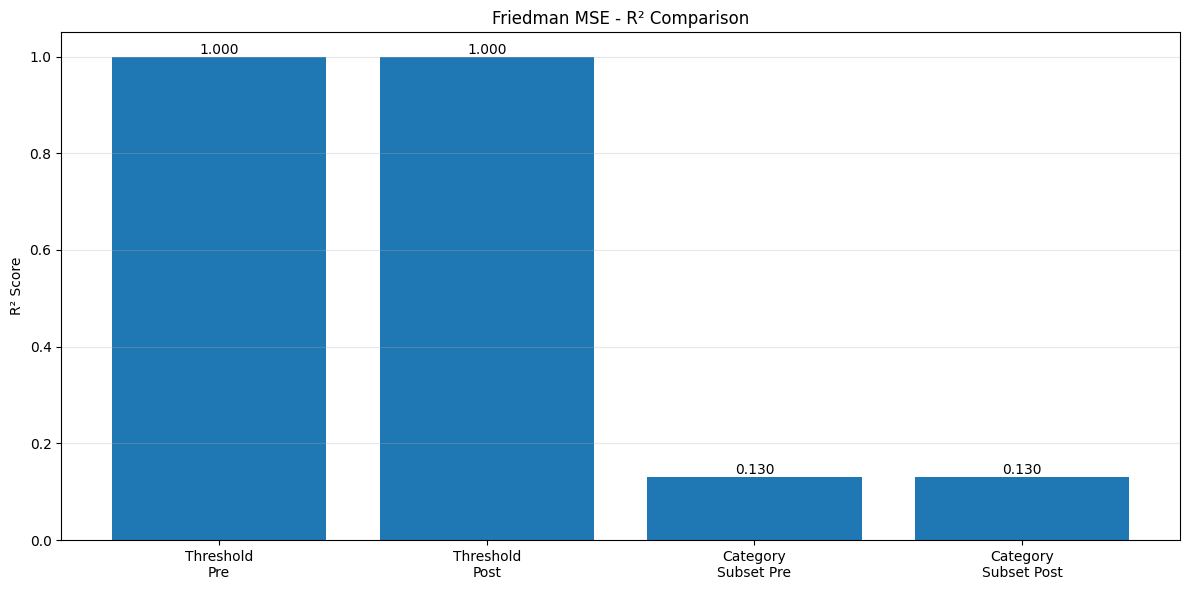

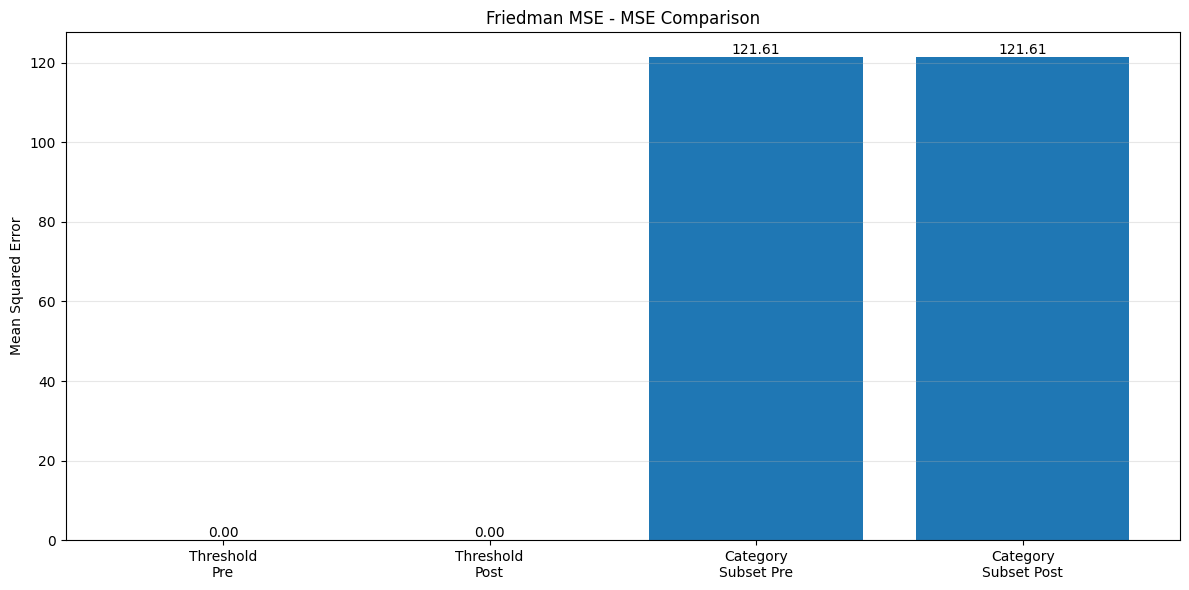

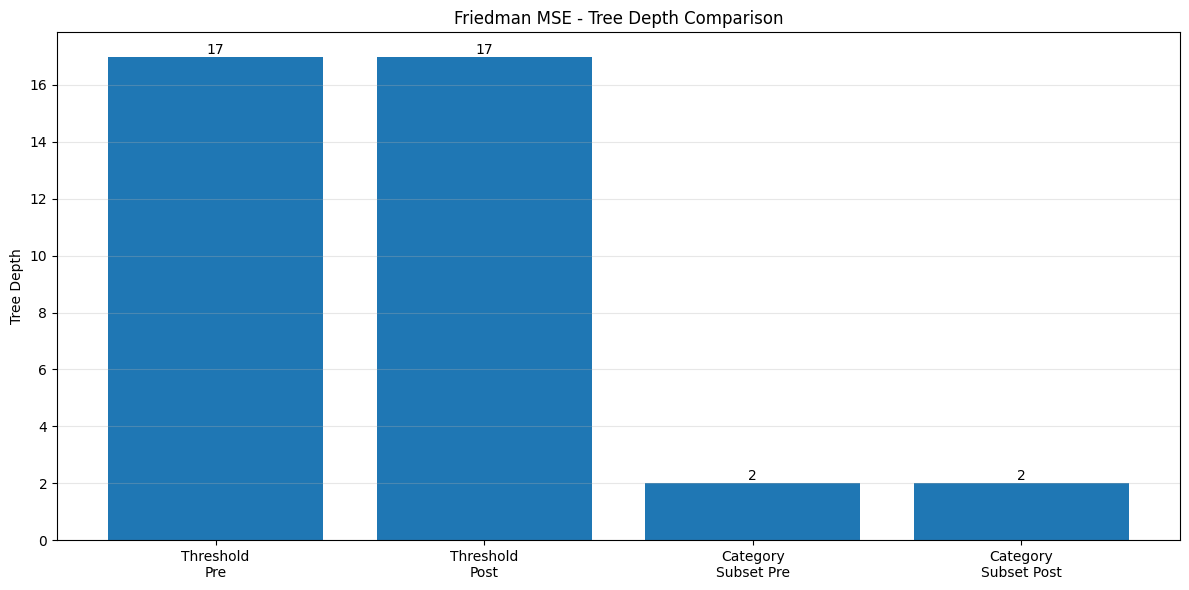

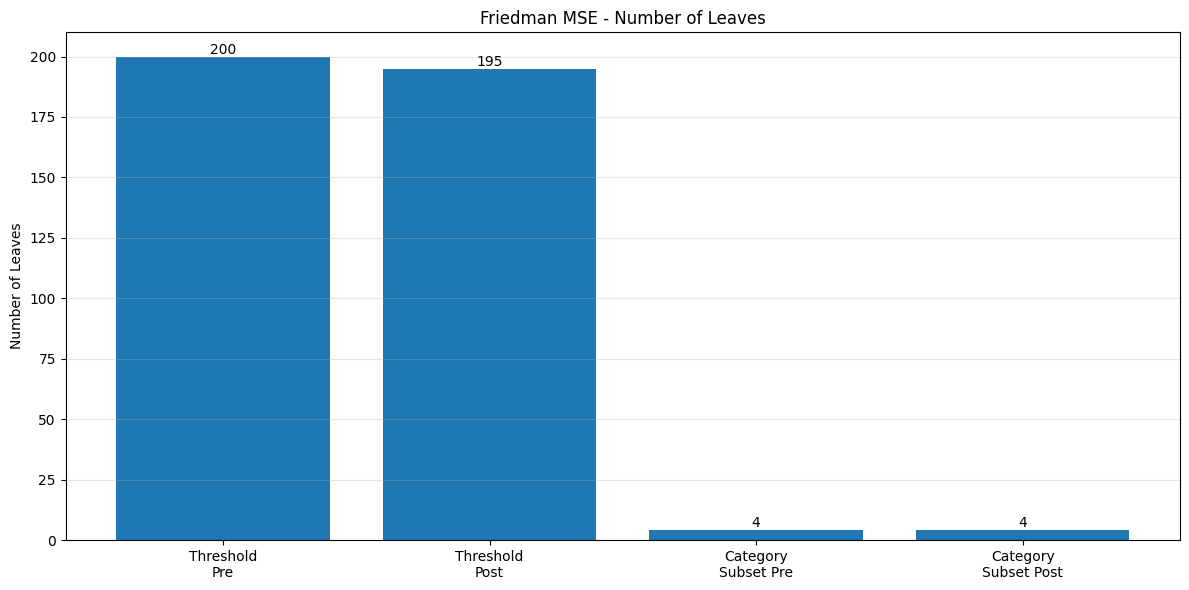

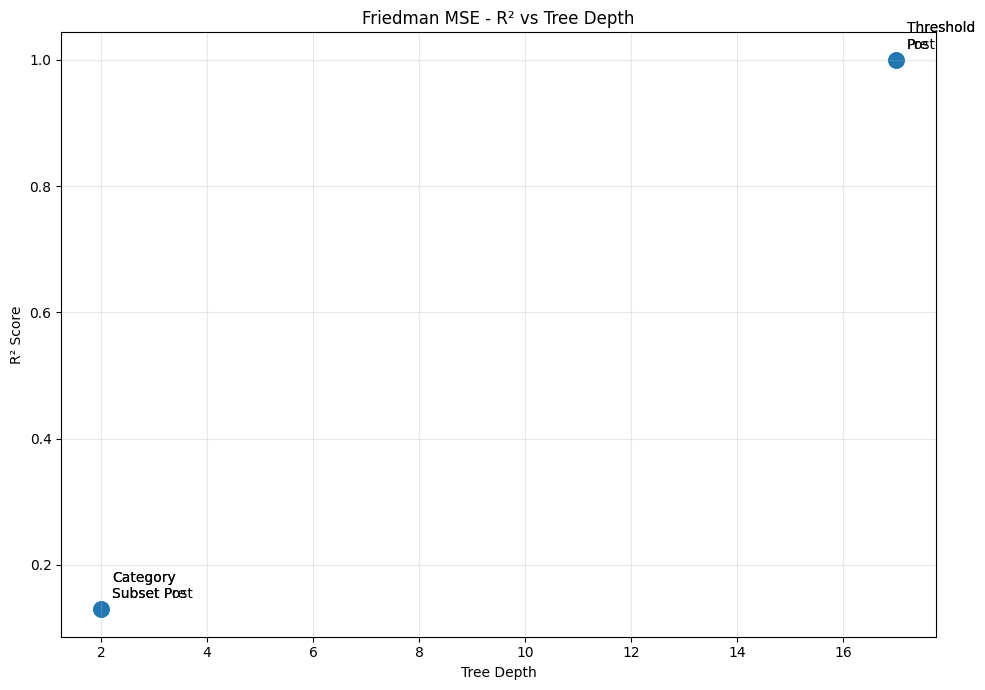

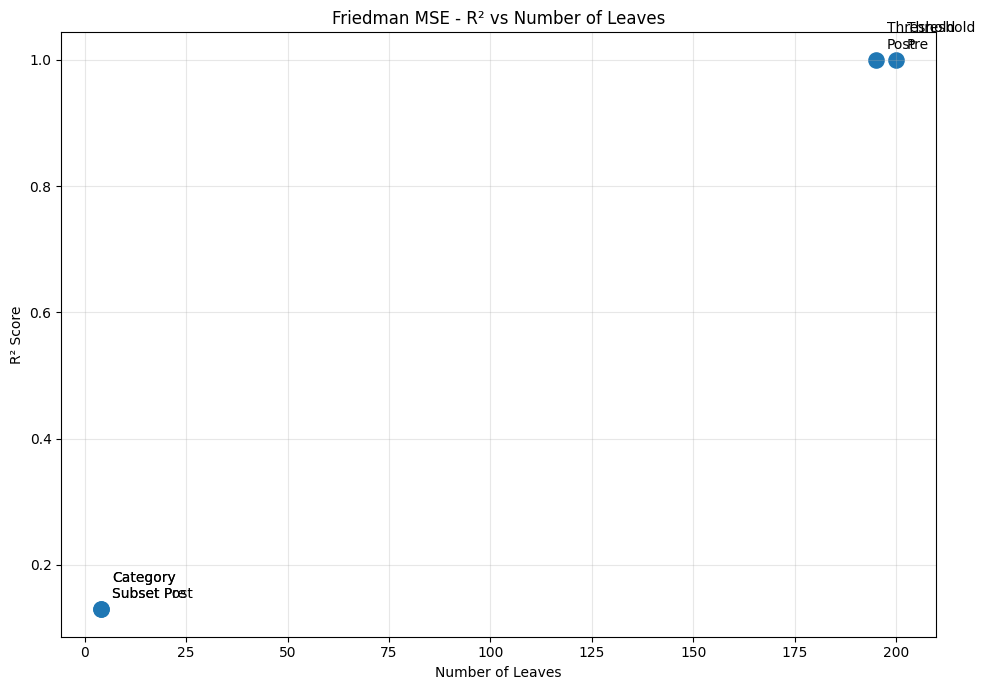

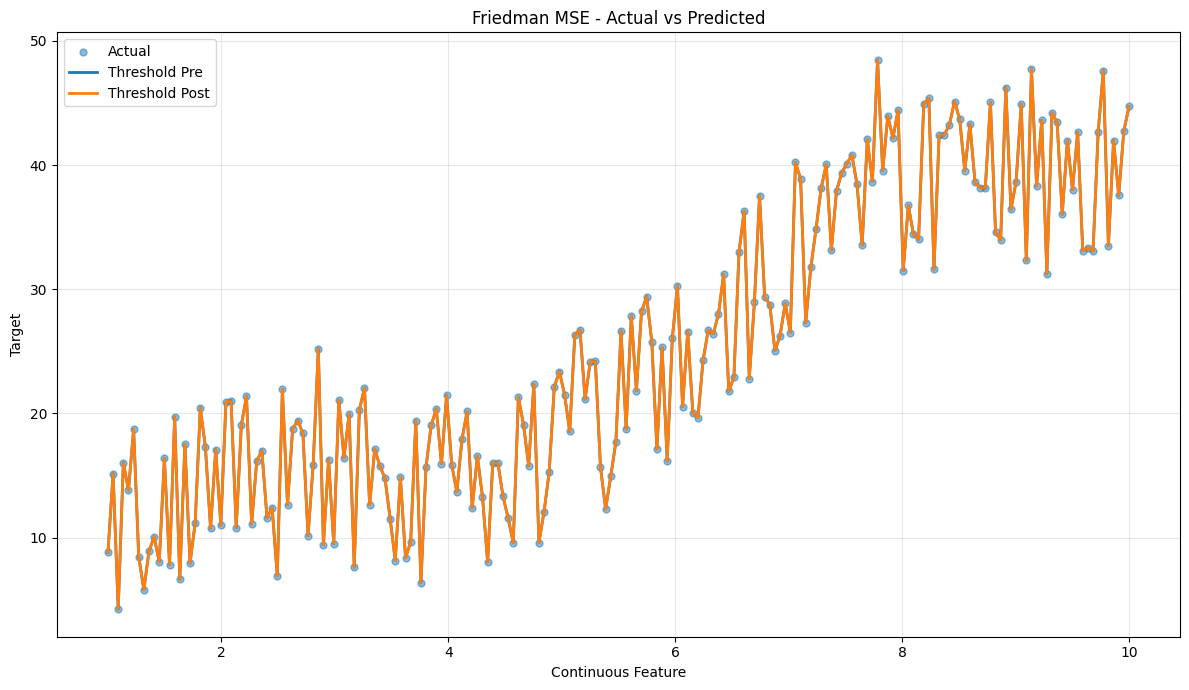



Configuration                                   R²         MSE     Depth    Leaves
Friedman MSE - Threshold - Pre              1.0000      0.0000        17       200
Friedman MSE - Threshold - Post             1.0000      0.0001        17       195
Friedman MSE - Category_Subset - Pre        0.1299    121.6066         2         4
Friedman MSE - Category_Subset - Post       0.1299    121.6066         2         4


In [ ]:
# ============================================================
# FRIEDMAN MSE DECISION TREE REGRESSOR FROM SCRATCH
#
# Criterion:
#     friedman_mse
#
# Split strategies:
#     Threshold
#     Category_Subset
#
# Pruning:
#     Pre
#     Post
#
# No sklearn is used.
# Only NumPy and Matplotlib are used.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        split_value=None,
        category_subset=None,
        left=None,
        right=None,
        prediction=None,
        impurity=None,
        n_samples=0,
        is_leaf=False
    ):

        self.feature_index = feature_index
        self.split_value = split_value
        self.category_subset = category_subset

        self.left = left
        self.right = right

        self.prediction = prediction
        self.impurity = impurity
        self.n_samples = n_samples

        self.is_leaf = is_leaf


# ============================================================
# 2. DECISION TREE REGRESSOR
# ============================================================

class DecisionTreeRegressor:

    def __init__(
        self,
        criterion="friedman_mse",
        split_strategy="Threshold",
        pruning="Pre",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0,
        random_state=None
    ):

        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes
        self.min_impurity_decrease = min_impurity_decrease

        self.ccp_alpha = ccp_alpha
        self.random_state = random_state

        self.rng = np.random.default_rng(
            random_state
        )

        self.root_ = None

        self.n_features_in_ = None

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0


    # ========================================================
    # 3. FIT
    # ========================================================

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y, dtype=float)

        if X.ndim != 2:
            raise ValueError(
                "X must be a 2-dimensional array."
            )

        if y.ndim != 1:
            y = y.ravel()

        if X.shape[0] != y.shape[0]:
            raise ValueError(
                f"X and y have inconsistent numbers of samples: "
                f"{X.shape[0]} and {y.shape[0]}"
            )

        if X.shape[0] == 0:
            raise ValueError(
                "X and y cannot be empty."
            )

        if self.criterion != "friedman_mse":
            raise ValueError(
                'This implementation supports '
                'criterion="friedman_mse".'
            )

        if self.split_strategy not in [
            "Threshold",
            "Category_Subset"
        ]:
            raise ValueError(
                'split_strategy must be "Threshold" '
                'or "Category_Subset".'
            )

        if self.pruning not in [
            "Pre",
            "Post"
        ]:
            raise ValueError(
                'pruning must be "Pre" or "Post".'
            )

        self.n_features_in_ = X.shape[1]

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0

        # Build tree
        self.root_ = self._build_tree(
            X,
            y,
            depth=0
        )

        # Post pruning
        if self.pruning == "Post":

            self.root_ = self._post_prune(
                self.root_,
                X,
                y
            )

        # Recalculate tree statistics
        self.n_leaves_ = self._count_leaves(
            self.root_
        )

        self.tree_depth_ = self._calculate_depth(
            self.root_
        )

        self.node_count_ = self._count_nodes(
            self.root_
        )

        return self


    # ========================================================
    # 4. NODE PREDICTION
    #
    # For regression, prediction at a leaf is the mean target.
    # ========================================================

    def _node_prediction(self, y):

        if len(y) == 0:
            return 0.0

        return float(
            np.mean(y)
        )


    # ========================================================
    # 5. MSE IMPURITY
    # ========================================================

    def _mse(self, y):

        if len(y) == 0:
            return 0.0

        mean = np.mean(y)

        return np.mean(
            (y - mean) ** 2
        )


    # ========================================================
    # 6. SUM OF SQUARED ERRORS
    # ========================================================

    def _sse(self, y):

        if len(y) == 0:
            return 0.0

        mean = np.mean(y)

        return np.sum(
            (y - mean) ** 2
        )


    # ========================================================
    # 7. FRIEDMAN MSE IMPURITY DECREASE
    #
    # Friedman MSE split improvement:
    #
    #   Improvement =
    #
    #   (n_left * n_right / n)
    #   * (mean_left - mean_right)^2
    #
    # This is the quantity used to compare candidate splits.
    # ========================================================

    def _friedman_mse_decrease(
        self,
        parent_y,
        left_y,
        right_y
    ):

        n = len(parent_y)

        if n == 0:
            return 0.0

        n_left = len(left_y)
        n_right = len(right_y)

        if n_left == 0 or n_right == 0:
            return 0.0

        mean_left = np.mean(left_y)
        mean_right = np.mean(right_y)

        decrease = (
            (n_left * n_right) / n
        ) * (
            mean_left - mean_right
        ) ** 2

        return float(decrease)


    # ========================================================
    # 8. BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth
    ):

        self.node_count_ += 1

        prediction = self._node_prediction(
            y
        )

        impurity = self._mse(
            y
        )

        # ----------------------------------------------------
        # PRE-PRUNING / STOPPING CONDITIONS
        # ----------------------------------------------------

        if self._should_stop(
            X,
            y,
            depth
        ):

            return TreeNode(
                prediction=prediction,
                impurity=impurity,
                n_samples=len(y),
                is_leaf=True
            )

        # ----------------------------------------------------
        # FIND BEST SPLIT
        # ----------------------------------------------------

        best_split = self._find_best_split(
            X,
            y
        )

        if best_split is None:

            return TreeNode(
                prediction=prediction,
                impurity=impurity,
                n_samples=len(y),
                is_leaf=True
            )

        decrease = best_split[
            "impurity_decrease"
        ]

        # ----------------------------------------------------
        # MIN IMPURITY DECREASE
        # ----------------------------------------------------

        if decrease < self.min_impurity_decrease:

            return TreeNode(
                prediction=prediction,
                impurity=impurity,
                n_samples=len(y),
                is_leaf=True
            )

        # ----------------------------------------------------
        # SPLIT DATA
        # ----------------------------------------------------

        left_indices = best_split[
            "left_indices"
        ]

        right_indices = best_split[
            "right_indices"
        ]

        X_left = X[
            left_indices
        ]

        y_left = y[
            left_indices
        ]

        X_right = X[
            right_indices
        ]

        y_right = y[
            right_indices
        ]

        # ----------------------------------------------------
        # RECURSIVELY BUILD CHILDREN
        # ----------------------------------------------------

        left_child = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right_child = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return TreeNode(
            feature_index=best_split[
                "feature_index"
            ],

            split_value=best_split[
                "split_value"
            ],

            category_subset=best_split[
                "category_subset"
            ],

            left=left_child,
            right=right_child,

            prediction=prediction,
            impurity=impurity,
            n_samples=len(y),

            is_leaf=False
        )


    # ========================================================
    # 9. PRE-PRUNING CONDITIONS
    # ========================================================

    def _should_stop(
        self,
        X,
        y,
        depth
    ):

        # Pure target / zero variance
        if np.allclose(
            y,
            y[0]
        ):
            return True

        # Maximum depth
        if (
            self.max_depth is not None
            and depth >= self.max_depth
        ):
            return True

        # Minimum samples for splitting
        if (
            len(y)
            <
            self.min_samples_split
        ):
            return True

        # Minimum samples required
        # for both children
        if (
            len(y)
            <
            2 * self.min_samples_leaf
        ):
            return True

        return False


    # ========================================================
    # 10. FIND BEST SPLIT
    # ========================================================

    def _find_best_split(
        self,
        X,
        y
    ):

        best_split = None

        best_decrease = -np.inf

        feature_indices = np.arange(
            X.shape[1]
        )

        # ----------------------------------------------------
        # MAX FEATURES
        # ----------------------------------------------------

        if self.max_features is not None:

            if isinstance(
                self.max_features,
                int
            ):

                n_features = min(
                    self.max_features,
                    X.shape[1]
                )

                feature_indices = (
                    self.rng.choice(
                        X.shape[1],
                        size=n_features,
                        replace=False
                    )
                )

            elif self.max_features == "sqrt":

                n_features = max(
                    1,
                    int(
                        np.sqrt(
                            X.shape[1]
                        )
                    )
                )

                feature_indices = (
                    self.rng.choice(
                        X.shape[1],
                        size=n_features,
                        replace=False
                    )
                )

            elif self.max_features == "log2":

                n_features = max(
                    1,
                    int(
                        np.log2(
                            X.shape[1]
                        )
                    )
                )

                feature_indices = (
                    self.rng.choice(
                        X.shape[1],
                        size=n_features,
                        replace=False
                    )
                )

        # ----------------------------------------------------
        # SEARCH ALL SELECTED FEATURES
        # ----------------------------------------------------

        for feature_index in feature_indices:

            column = X[
                :,
                feature_index
            ]

            if self.split_strategy == "Threshold":

                split = (
                    self._find_threshold_split(
                        column,
                        y,
                        feature_index
                    )
                )

            else:

                split = (
                    self._find_category_subset_split(
                        column,
                        y,
                        feature_index
                    )
                )

            if split is not None:

                decrease = split[
                    "impurity_decrease"
                ]

                if decrease > best_decrease:

                    best_decrease = decrease

                    best_split = split

        return best_split


    # ========================================================
    # 11. THRESHOLD SPLITTING
    # ========================================================

    def _find_threshold_split(
        self,
        column,
        y,
        feature_index
    ):

        try:

            values = column.astype(
                float
            )

        except (ValueError, TypeError):

            return None

        unique_values = np.unique(
            values
        )

        if len(unique_values) < 2:
            return None

        # Candidate thresholds are midpoints
        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0

        best_split = None

        best_decrease = -np.inf

        for threshold in thresholds:

            left_indices = np.where(
                values <= threshold
            )[0]

            right_indices = np.where(
                values > threshold
            )[0]

            # Minimum leaf size
            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):
                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):
                continue

            left_y = y[
                left_indices
            ]

            right_y = y[
                right_indices
            ]

            # Friedman MSE improvement
            decrease = (
                self._friedman_mse_decrease(
                    y,
                    left_y,
                    right_y
                )
            )

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        threshold,

                    "category_subset":
                        None,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 12. CATEGORY SUBSET SPLITTING
    #
    # For regression:
    #
    # Categories are ordered according to their mean target.
    #
    # Example:
    #
    # Category A -> mean 10
    # Category B -> mean 15
    # Category C -> mean 30
    #
    # Candidate splits:
    #
    # {A} vs {B,C}
    # {A,B} vs {C}
    #
    # This avoids evaluating every possible subset.
    # ========================================================

    def _find_category_subset_split(
        self,
        column,
        y,
        feature_index
    ):

        categories = np.unique(
            column
        )

        if len(categories) < 2:
            return None

        # ----------------------------------------------------
        # Calculate target mean for every category
        # ----------------------------------------------------

        category_means = []

        for category in categories:

            mask = (
                column == category
            )

            category_y = y[
                mask
            ]

            mean_value = np.mean(
                category_y
            )

            category_means.append(
                (
                    category,
                    mean_value
                )
            )

        # ----------------------------------------------------
        # Sort categories by target mean
        # ----------------------------------------------------

        category_means.sort(
            key=lambda x: x[1]
        )

        ordered_categories = [
            item[0]
            for item in category_means
        ]

        # ----------------------------------------------------
        # Generate ordered subsets
        # ----------------------------------------------------

        subsets = []

        for i in range(
            1,
            len(ordered_categories)
        ):

            subset = set(
                ordered_categories[:i]
            )

            subsets.append(
                subset
            )

        # ----------------------------------------------------
        # Evaluate every ordered subset
        # ----------------------------------------------------

        best_split = None

        best_decrease = -np.inf

        for subset in subsets:

            left_mask = np.array([
                value in subset
                for value in column
            ])

            right_mask = ~left_mask

            left_indices = np.where(
                left_mask
            )[0]

            right_indices = np.where(
                right_mask
            )[0]

            # Minimum leaf size
            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):
                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):
                continue

            left_y = y[
                left_indices
            ]

            right_y = y[
                right_indices
            ]

            decrease = (
                self._friedman_mse_decrease(
                    y,
                    left_y,
                    right_y
                )
            )

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        None,

                    "category_subset":
                        subset,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 13. PREDICT ONE SAMPLE
    # ========================================================

    def _predict_one(self, x):

        node = self.root_

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            # Threshold split
            if (
                node.category_subset
                is None
            ):

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            # Category subset split
            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 14. PREDICT
    # ========================================================

    def predict(self, X):

        X = np.asarray(X)

        if X.ndim == 1:

            X = X.reshape(
                1,
                -1
            )

        predictions = np.array([
            self._predict_one(x)
            for x in X
        ])

        return predictions


    # ========================================================
    # 15. R-SQUARED SCORE
    # ========================================================

    def score(self, X, y):

        y = np.asarray(
            y,
            dtype=float
        )

        predictions = self.predict(
            X
        )

        ss_res = np.sum(
            (y - predictions) ** 2
        )

        ss_tot = np.sum(
            (y - np.mean(y)) ** 2
        )

        if ss_tot == 0:

            return 1.0

        return (
            1.0
            -
            ss_res / ss_tot
        )


    # ========================================================
    # 16. MEAN SQUARED ERROR
    # ========================================================

    def mse_score(self, X, y):

        y = np.asarray(
            y,
            dtype=float
        )

        predictions = self.predict(
            X
        )

        return np.mean(
            (y - predictions) ** 2
        )


    # ========================================================
    # 17. POST PRUNING
    #
    # Cost-complexity:
    #
    #     Cost(tree)
    #     =
    #     SSE(tree)
    #     +
    #     ccp_alpha * number_of_leaves
    #
    # A subtree is replaced by one leaf when
    # the leaf has lower/equal cost.
    # ========================================================

    def _post_prune(
        self,
        node,
        X,
        y
    ):

        if node is None:
            return node

        if node.is_leaf:
            return node

        if len(y) == 0:
            return node

        # ----------------------------------------------------
        # Find samples reaching this node
        # ----------------------------------------------------

        left_indices, right_indices = (
            self._split_indices_for_node(
                node,
                X
            )
        )

        X_left = X[
            left_indices
        ]

        y_left = y[
            left_indices
        ]

        X_right = X[
            right_indices
        ]

        y_right = y[
            right_indices
        ]

        # ----------------------------------------------------
        # Recursively prune children
        # ----------------------------------------------------

        node.left = self._post_prune(
            node.left,
            X_left,
            y_left
        )

        node.right = self._post_prune(
            node.right,
            X_right,
            y_right
        )

        # ----------------------------------------------------
        # Error of current subtree
        # ----------------------------------------------------

        subtree_predictions = np.array([
            self._predict_node(
                node,
                x
            )
            for x in X
        ])

        subtree_error = np.sum(
            (
                y
                -
                subtree_predictions
            ) ** 2
        )

        # ----------------------------------------------------
        # Error if converted to one leaf
        # ----------------------------------------------------

        leaf_prediction = (
            self._node_prediction(y)
        )

        leaf_error = np.sum(
            (
                y
                -
                leaf_prediction
            ) ** 2
        )

        # ----------------------------------------------------
        # Cost-complexity
        # ----------------------------------------------------

        subtree_leaves = (
            self._count_leaves(node)
        )

        subtree_cost = (
            subtree_error
            +
            self.ccp_alpha
            *
            subtree_leaves
        )

        leaf_cost = (
            leaf_error
            +
            self.ccp_alpha
        )

        # ----------------------------------------------------
        # Prune if leaf is cheaper
        # ----------------------------------------------------

        if leaf_cost <= subtree_cost:

            node = TreeNode(
                prediction=leaf_prediction,
                impurity=self._mse(y),
                n_samples=len(y),
                is_leaf=True
            )

        return node


    # ========================================================
    # 18. FIND CHILD SAMPLE INDICES
    # ========================================================

    def _split_indices_for_node(
        self,
        node,
        X
    ):

        values = X[
            :,
            node.feature_index
        ]

        if (
            node.category_subset
            is None
        ):

            values_float = values.astype(
                float
            )

            left_mask = (
                values_float
                <=
                node.split_value
            )

        else:

            left_mask = np.array([
                value in node.category_subset
                for value in values
            ])

        right_mask = ~left_mask

        return (
            np.where(left_mask)[0],
            np.where(right_mask)[0]
        )


    # ========================================================
    # 19. PREDICT FROM SPECIFIC NODE
    # ========================================================

    def _predict_node(
        self,
        node,
        x
    ):

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            if (
                node.category_subset
                is None
            ):

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 20. COUNT LEAVES
    # ========================================================

    def _count_leaves(
        self,
        node
    ):

        if node is None:
            return 0

        if node.is_leaf:
            return 1

        return (
            self._count_leaves(
                node.left
            )
            +
            self._count_leaves(
                node.right
            )
        )


    # ========================================================
    # 21. COUNT NODES
    # ========================================================

    def _count_nodes(
        self,
        node
    ):

        if node is None:
            return 0

        if node.is_leaf:
            return 1

        return (
            1
            +
            self._count_nodes(
                node.left
            )
            +
            self._count_nodes(
                node.right
            )
        )


    # ========================================================
    # 22. CALCULATE TREE DEPTH
    # ========================================================

    def _calculate_depth(
        self,
        node
    ):

        if node is None:
            return 0

        if node.is_leaf:
            return 0

        return (
            1
            +
            max(
                self._calculate_depth(
                    node.left
                ),
                self._calculate_depth(
                    node.right
                )
            )
        )


    # ========================================================
    # 23. GET DEPTH
    # ========================================================

    def get_depth(self):

        return self.tree_depth_


    # ========================================================
    # 24. GET NUMBER OF LEAVES
    # ========================================================

    def get_n_leaves(self):

        return self.n_leaves_


    # ========================================================
    # 25. PRINT TREE
    #
    # Optional debugging function.
    # We DO NOT call this automatically because it creates
    # huge unnecessary output.
    # ========================================================

    def print_tree(
        self,
        node=None,
        depth=0
    ):

        if node is None:
            node = self.root_

        indentation = (
            "    " * depth
        )

        if node.is_leaf:

            print(
                indentation
                +
                f"Leaf: "
                f"prediction="
                f"{node.prediction:.4f}"
            )

            return

        if (
            node.category_subset
            is None
        ):

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"<= "
                f"{node.split_value:.4f}"
            )

        else:

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"in "
                f"{node.category_subset}"
            )

        self.print_tree(
            node.left,
            depth + 1
        )

        self.print_tree(
            node.right,
            depth + 1
        )


# ============================================================
# 26. CREATE REGRESSION DATA
#
# Feature 0:
#     Continuous variable
#
# Feature 1:
#     Categorical variable
#
# Target:
#     Nonlinear regression relationship + noise
# ============================================================

rng = np.random.default_rng(
    42
)

n_samples = 200

# Continuous feature
x_continuous = np.linspace(
    1,
    10,
    n_samples
)

# Categorical feature
categories = np.array([
    "A",
    "B",
    "C",
    "D"
])

x_category = rng.choice(
    categories,
    size=n_samples
)

# Category effects
category_effect = {
    "A": 0.0,
    "B": 5.0,
    "C": -4.0,
    "D": 8.0
}

category_values = np.array([
    category_effect[value]
    for value in x_category
])

# Regression target
y = (
    4
    * x_continuous
    +
    5
    * np.sin(
        x_continuous
    )
    +
    category_values
    +
    rng.normal(
        0,
        1.5,
        n_samples
    )
)

# ------------------------------------------------------------
# IMPORTANT:
#
# We keep two datasets:
#
# X_threshold:
#     Used for Threshold experiments.
#
# X_category:
#     Used for Category_Subset experiments.
#
# This prevents treating continuous numbers as fake categories.
# ------------------------------------------------------------

X_threshold = np.column_stack([
    x_continuous
])

X_category = np.column_stack([
    x_category
])


# ============================================================
# 27. FOUR REQUIRED CONFIGURATIONS
# ============================================================

models_threshold = {

    "Friedman MSE - Threshold - Pre":
        DecisionTreeRegressor(
            criterion="friedman_mse",
            split_strategy="Threshold",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),

    "Friedman MSE - Threshold - Post":
        DecisionTreeRegressor(
            criterion="friedman_mse",
            split_strategy="Threshold",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=0.01,
            random_state=42
        )
}


models_category = {

    "Friedman MSE - Category_Subset - Pre":
        DecisionTreeRegressor(
            criterion="friedman_mse",
            split_strategy="Category_Subset",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),

    "Friedman MSE - Category_Subset - Post":
        DecisionTreeRegressor(
            criterion="friedman_mse",
            split_strategy="Category_Subset",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=0.01,
            random_state=42
        )
}


# ============================================================
# 28. TRAIN THRESHOLD MODELS
# ============================================================

results = {}

predictions = {}

for name, model in models_threshold.items():

    model.fit(
        X_threshold,
        y
    )

    y_pred = model.predict(
        X_threshold
    )

    results[name] = {

        "r2":
            model.score(
                X_threshold,
                y
            ),

        "mse":
            model.mse_score(
                X_threshold,
                y
            ),

        "depth":
            model.get_depth(),

        "leaves":
            model.get_n_leaves()
    }

    predictions[name] = (
        y_pred
    )


# ============================================================
# 29. TRAIN CATEGORY SUBSET MODELS
# ============================================================

for name, model in models_category.items():

    model.fit(
        X_category,
        y
    )

    y_pred = model.predict(
        X_category
    )

    results[name] = {

        "r2":
            model.score(
                X_category,
                y
            ),

        "mse":
            model.mse_score(
                X_category,
                y
            ),

        "depth":
            model.get_depth(),

        "leaves":
            model.get_n_leaves()
    }

    predictions[name] = (
        y_pred
    )


# ============================================================
# 30. CLEAN RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("                 FRIEDMAN MSE RESULTS")
print("=" * 80)

for name, result in results.items():

    print("\n" + name)
    print("-" * 60)

    print(
        f"R² Score : {result['r2']:.4f}"
    )

    print(
        f"MSE      : {result['mse']:.4f}"
    )

    print(
        f"Depth    : {result['depth']}"
    )

    print(
        f"Leaves   : {result['leaves']}"
    )

print("\n" + "=" * 80)


# ============================================================
# 31. PREPARE PLOT DATA
# ============================================================

names = list(
    results.keys()
)

r2_scores = [
    results[name]["r2"]
    for name in names
]

mse_scores = [
    results[name]["mse"]
    for name in names
]

depths = [
    results[name]["depth"]
    for name in names
]

leaves = [
    results[name]["leaves"]
    for name in names
]


short_names = [
    "Threshold\nPre",
    "Threshold\nPost",
    "Category\nSubset Pre",
    "Category\nSubset Post"
]


# ============================================================
# 32. R² COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    range(len(names)),
    r2_scores
)

plt.xticks(
    range(len(names)),
    short_names
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "Friedman MSE - R² Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

# Add values above bars
for i, value in enumerate(
    r2_scores
):

    plt.text(
        i,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 33. MSE COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    range(len(names)),
    mse_scores
)

plt.xticks(
    range(len(names)),
    short_names
)

plt.ylabel(
    "Mean Squared Error"
)

plt.title(
    "Friedman MSE - MSE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for i, value in enumerate(
    mse_scores
):

    plt.text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 34. TREE DEPTH COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    range(len(names)),
    depths
)

plt.xticks(
    range(len(names)),
    short_names
)

plt.ylabel(
    "Tree Depth"
)

plt.title(
    "Friedman MSE - Tree Depth Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for i, value in enumerate(
    depths
):

    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 35. NUMBER OF LEAVES COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    range(len(names)),
    leaves
)

plt.xticks(
    range(len(names)),
    short_names
)

plt.ylabel(
    "Number of Leaves"
)

plt.title(
    "Friedman MSE - Number of Leaves"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for i, value in enumerate(
    leaves
):

    plt.text(
        i,
        value,
        str(value),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 36. R² VS TREE DEPTH
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    depths,
    r2_scores,
    s=120
)

for i in range(
    len(names)
):

    plt.annotate(
        short_names[i],
        (
            depths[i],
            r2_scores[i]
        ),
        xytext=(
            8,
            8
        ),
        textcoords="offset points"
    )

plt.xlabel(
    "Tree Depth"
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "Friedman MSE - R² vs Tree Depth"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 37. R² VS NUMBER OF LEAVES
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    leaves,
    r2_scores,
    s=120
)

for i in range(
    len(names)
):

    plt.annotate(
        short_names[i],
        (
            leaves[i],
            r2_scores[i]
        ),
        xytext=(
            8,
            8
        ),
        textcoords="offset points"
    )

plt.xlabel(
    "Number of Leaves"
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "Friedman MSE - R² vs Number of Leaves"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 38. ACTUAL VS PREDICTED
#
# Only Threshold models are plotted here because their
# continuous X values can be naturally displayed.
# ============================================================

plt.figure(
    figsize=(12, 7)
)

plt.scatter(
    x_continuous,
    y,
    s=25,
    alpha=0.5,
    label="Actual"
)

threshold_pre_name = (
    "Friedman MSE - Threshold - Pre"
)

threshold_post_name = (
    "Friedman MSE - Threshold - Post"
)

# Sort X for a clean prediction curve
sort_indices = np.argsort(
    x_continuous
)

plt.plot(
    x_continuous[
        sort_indices
    ],
    predictions[
        threshold_pre_name
    ][
        sort_indices
    ],
    linewidth=2,
    label="Threshold Pre"
)

plt.plot(
    x_continuous[
        sort_indices
    ],
    predictions[
        threshold_post_name
    ][
        sort_indices
    ],
    linewidth=2,
    label="Threshold Post"
)

plt.xlabel(
    "Continuous Feature"
)

plt.ylabel(
    "Target"
)

plt.title(
    "Friedman MSE - Actual vs Predicted"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 39. FINAL SUMMARY TABLE
# ============================================================

print("\n")
print("=" * 90)
print(
    f"{'Configuration':<40}"
    f"{'R²':>10}"
    f"{'MSE':>12}"
    f"{'Depth':>10}"
    f"{'Leaves':>10}"
)
print("=" * 90)

for name, result in results.items():

    print(
        f"{name:<40}"
        f"{result['r2']:>10.4f}"
        f"{result['mse']:>12.4f}"
        f"{result['depth']:>10}"
        f"{result['leaves']:>10}"
    )

print("=" * 90)

X shape: (40, 1)
y shape: (40,)


             ABSOLUTE ERROR DECISION TREE RESULTS

Absolute Error - Threshold - Pre
------------------------------------------------------------
R² Accuracy : 1.0000
Depth       : 8
Leaves      : 40

Absolute Error - Threshold - Post
------------------------------------------------------------
R² Accuracy : 1.0000
Depth       : 8
Leaves      : 40

Absolute Error - Category_Subset - Pre
------------------------------------------------------------
R² Accuracy : 1.0000
Depth       : 7
Leaves      : 40

Absolute Error - Category_Subset - Post
------------------------------------------------------------
R² Accuracy : 1.0000
Depth       : 7
Leaves      : 40



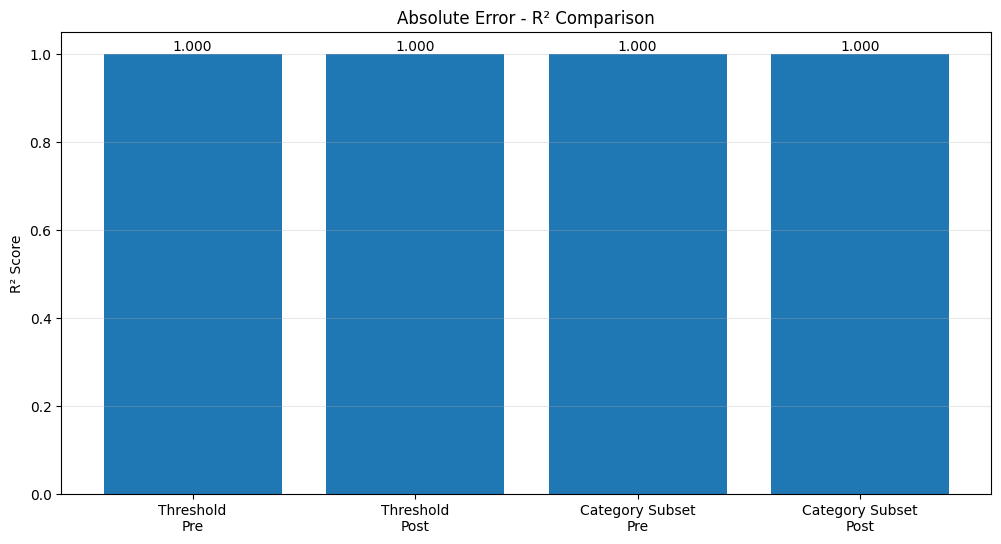

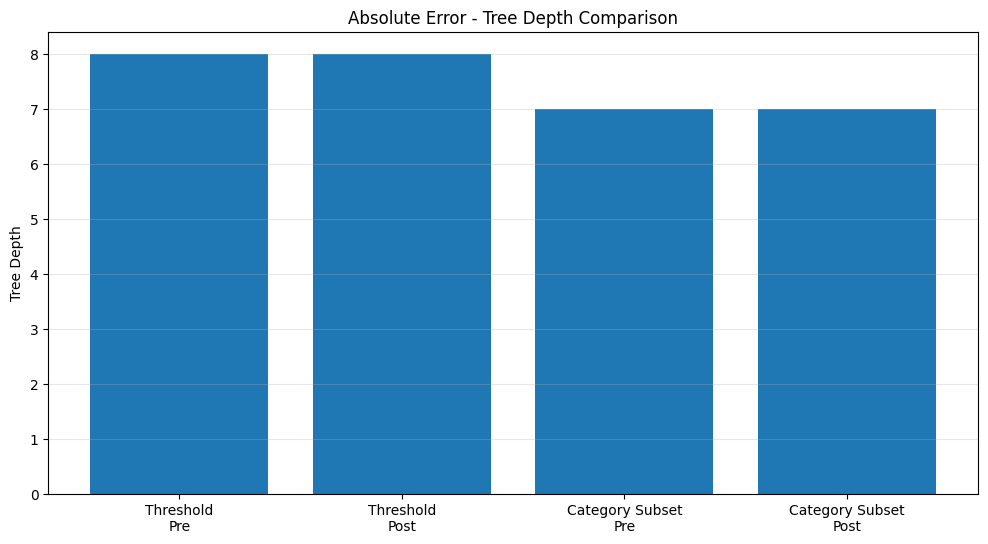

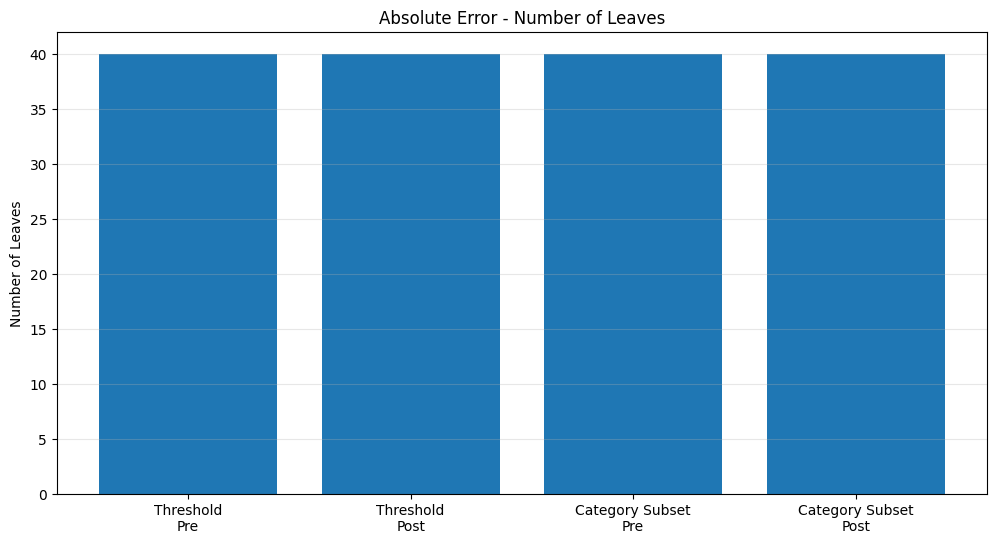

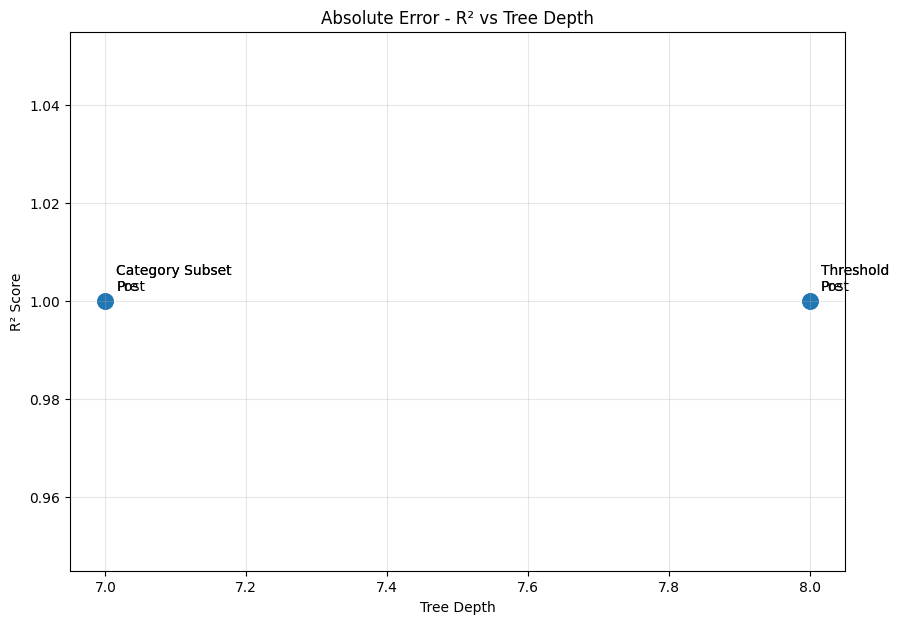

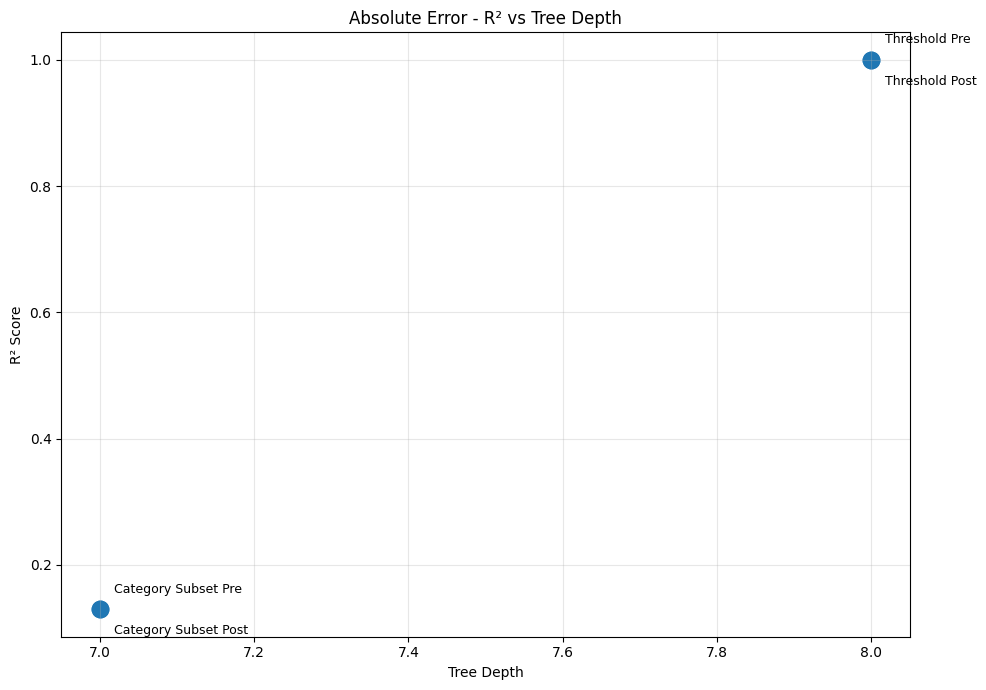

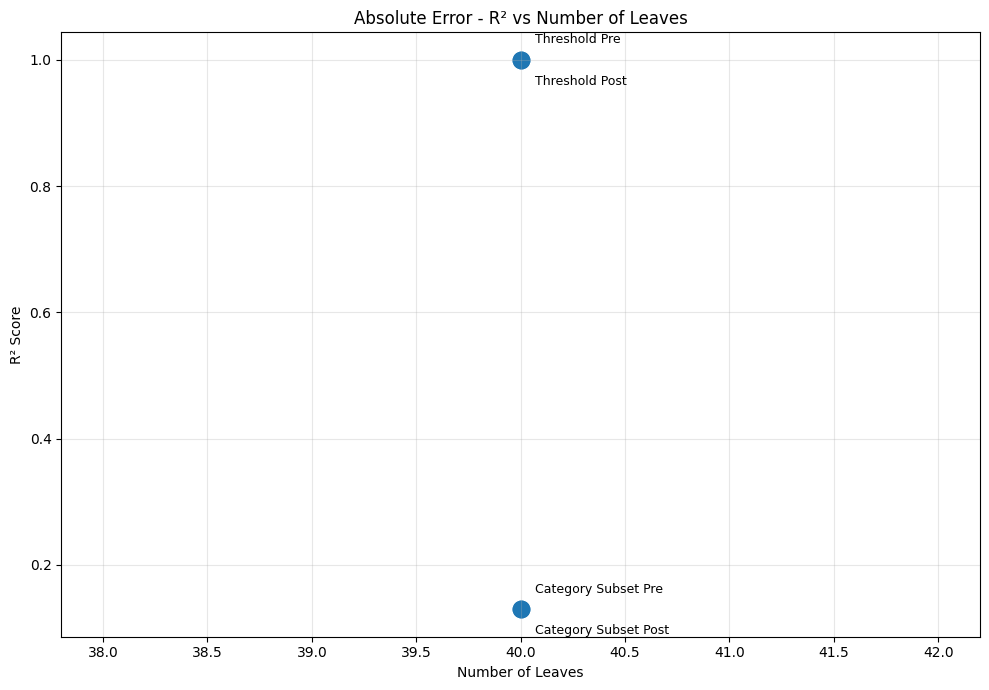

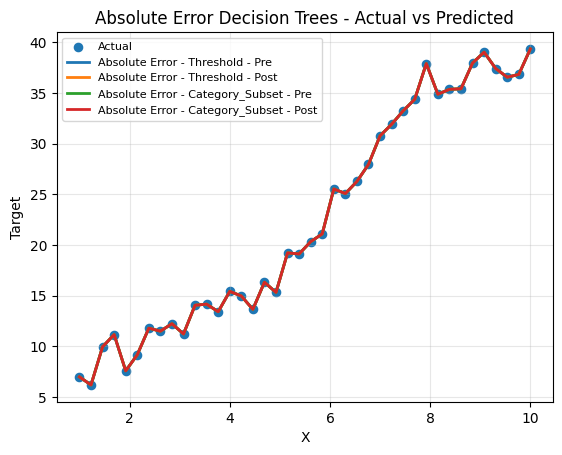

In [ ]:
# ============================================================
# DECISION TREE REGRESSOR FROM SCRATCH
#
# Criterion:
#     absolute_error
#
# Split strategies:
#     Threshold
#     Category_Subset
#
# Pruning:
#     Pre
#     Post
#
# No sklearn is used.
# Only NumPy and Matplotlib are used.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        split_value=None,
        category_subset=None,
        left=None,
        right=None,
        prediction=None,
        impurity=None,
        n_samples=None,
        is_leaf=False
    ):

        self.feature_index = feature_index
        self.split_value = split_value
        self.category_subset = category_subset

        self.left = left
        self.right = right

        self.prediction = prediction
        self.impurity = impurity
        self.n_samples = n_samples

        self.is_leaf = is_leaf


# ============================================================
# 2. DECISION TREE REGRESSOR
# ============================================================

class DecisionTreeRegressor:

    def __init__(
        self,
        criterion="absolute_error",
        split_strategy="Threshold",
        pruning="Pre",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0,
        random_state=None
    ):

        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes
        self.min_impurity_decrease = min_impurity_decrease

        self.ccp_alpha = ccp_alpha
        self.random_state = random_state

        self.rng = np.random.default_rng(
            random_state
        )

        self.root_ = None

        self.n_features_in_ = None

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0


    # ========================================================
    # 3. FIT
    # ========================================================

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y, dtype=float)

        if X.ndim != 2:
            raise ValueError(
                "X must be a 2-dimensional array."
            )

        if y.ndim != 1:
            y = y.ravel()

        if X.shape[0] != y.shape[0]:
            raise ValueError(
                f"X and y have inconsistent numbers of samples: "
                f"{X.shape[0]} and {y.shape[0]}"
            )

        if X.shape[0] == 0:
            raise ValueError(
                "X and y cannot be empty."
            )

        if self.criterion != "absolute_error":
            raise ValueError(
                'This implementation supports '
                'criterion="absolute_error".'
            )

        if self.split_strategy not in [
            "Threshold",
            "Category_Subset"
        ]:
            raise ValueError(
                'split_strategy must be '
                '"Threshold" or "Category_Subset".'
            )

        if self.pruning not in [
            "Pre",
            "Post"
        ]:
            raise ValueError(
                'pruning must be "Pre" or "Post".'
            )

        self.n_features_in_ = X.shape[1]

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0

        self.root_ = self._build_tree(
            X,
            y,
            depth=0
        )

        # ----------------------------------------------------
        # POST PRUNING
        # ----------------------------------------------------

        if self.pruning == "Post":

            self.root_ = self._post_prune(
                self.root_,
                X,
                y
            )

        # ----------------------------------------------------
        # FINAL TREE STATISTICS
        # ----------------------------------------------------

        self.n_leaves_ = self._count_leaves(
            self.root_
        )

        self.tree_depth_ = self._calculate_depth(
            self.root_
        )

        self.node_count_ = self._count_nodes(
            self.root_
        )

        return self


    # ========================================================
    # 4. ABSOLUTE ERROR IMPURITY
    #
    # Impurity =
    #
    #       sum |yi - median(y)|
    #       --------------------
    #              n
    #
    # Lower impurity = better homogeneous node.
    # ========================================================

    def _absolute_error_impurity(self, y):

        if len(y) == 0:
            return 0.0

        median = np.median(y)

        absolute_errors = np.abs(
            y - median
        )

        return np.mean(
            absolute_errors
        )


    # ========================================================
    # 5. LEAF PREDICTION
    #
    # For absolute_error:
    #
    #       prediction = median(y)
    #
    # ========================================================

    def _leaf_prediction(self, y):

        if len(y) == 0:
            return 0.0

        return float(
            np.median(y)
        )


    # ========================================================
    # 6. IMPURITY DECREASE
    # ========================================================

    def _impurity_decrease(
        self,
        parent_y,
        left_y,
        right_y
    ):

        parent_impurity = (
            self._absolute_error_impurity(
                parent_y
            )
        )

        left_impurity = (
            self._absolute_error_impurity(
                left_y
            )
        )

        right_impurity = (
            self._absolute_error_impurity(
                right_y
            )
        )

        n = len(parent_y)

        left_weight = (
            len(left_y) / n
        )

        right_weight = (
            len(right_y) / n
        )

        weighted_child_impurity = (
            left_weight * left_impurity
            +
            right_weight * right_impurity
        )

        decrease = (
            parent_impurity
            -
            weighted_child_impurity
        )

        return decrease


    # ========================================================
    # 7. BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth
    ):

        self.node_count_ += 1

        prediction = (
            self._leaf_prediction(y)
        )

        impurity = (
            self._absolute_error_impurity(y)
        )

        # ----------------------------------------------------
        # PRE-PRUNING STOP CONDITIONS
        # ----------------------------------------------------

        if self._should_stop(
            X,
            y,
            depth
        ):

            return TreeNode(
                prediction=prediction,
                impurity=impurity,
                n_samples=len(y),
                is_leaf=True
            )

        # ----------------------------------------------------
        # FIND BEST SPLIT
        # ----------------------------------------------------

        best_split = self._find_best_split(
            X,
            y
        )

        if best_split is None:

            return TreeNode(
                prediction=prediction,
                impurity=impurity,
                n_samples=len(y),
                is_leaf=True
            )

        decrease = (
            best_split["impurity_decrease"]
        )

        # ----------------------------------------------------
        # MINIMUM IMPURITY DECREASE
        # ----------------------------------------------------

        if (
            decrease
            <
            self.min_impurity_decrease
        ):

            return TreeNode(
                prediction=prediction,
                impurity=impurity,
                n_samples=len(y),
                is_leaf=True
            )

        # ----------------------------------------------------
        # MAX LEAF NODES
        #
        # Prevent creation of additional leaves.
        # ----------------------------------------------------

        if (
            self.max_leaf_nodes is not None
            and self.n_leaves_ + 2
            > self.max_leaf_nodes
        ):

            return TreeNode(
                prediction=prediction,
                impurity=impurity,
                n_samples=len(y),
                is_leaf=True
            )

        # ----------------------------------------------------
        # GET SPLIT INFORMATION
        # ----------------------------------------------------

        feature_index = (
            best_split["feature_index"]
        )

        split_value = (
            best_split["split_value"]
        )

        category_subset = (
            best_split["category_subset"]
        )

        left_indices = (
            best_split["left_indices"]
        )

        right_indices = (
            best_split["right_indices"]
        )

        # ----------------------------------------------------
        # CREATE CHILD DATASETS
        # ----------------------------------------------------

        X_left = X[left_indices]
        y_left = y[left_indices]

        X_right = X[right_indices]
        y_right = y[right_indices]

        # ----------------------------------------------------
        # RECURSIVE TREE CONSTRUCTION
        # ----------------------------------------------------

        left_child = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right_child = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        return TreeNode(
            feature_index=feature_index,
            split_value=split_value,
            category_subset=category_subset,
            left=left_child,
            right=right_child,
            prediction=prediction,
            impurity=impurity,
            n_samples=len(y),
            is_leaf=False
        )


    # ========================================================
    # 8. PRE-PRUNING CONDITIONS
    # ========================================================

    def _should_stop(
        self,
        X,
        y,
        depth
    ):

        # ----------------------------------------------------
        # NODE HAS ONLY ONE UNIQUE TARGET
        # ----------------------------------------------------

        if len(np.unique(y)) == 1:
            return True

        # ----------------------------------------------------
        # MAXIMUM DEPTH
        # ----------------------------------------------------

        if (
            self.max_depth is not None
            and depth >= self.max_depth
        ):
            return True

        # ----------------------------------------------------
        # MINIMUM SAMPLES TO SPLIT
        # ----------------------------------------------------

        if (
            len(y)
            <
            self.min_samples_split
        ):
            return True

        # ----------------------------------------------------
        # MINIMUM SAMPLES PER LEAF
        # ----------------------------------------------------

        if (
            len(y)
            <
            2 * self.min_samples_leaf
        ):
            return True

        return False


    # ========================================================
    # 9. FIND BEST SPLIT
    # ========================================================

    def _find_best_split(
        self,
        X,
        y
    ):

        best_split = None

        best_decrease = -np.inf

        # ----------------------------------------------------
        # ALL FEATURES
        # ----------------------------------------------------

        feature_indices = np.arange(
            X.shape[1]
        )

        # ----------------------------------------------------
        # MAX FEATURES
        # ----------------------------------------------------

        if self.max_features is not None:

            if isinstance(
                self.max_features,
                int
            ):

                n_features = min(
                    self.max_features,
                    X.shape[1]
                )

                feature_indices = (
                    self.rng.choice(
                        X.shape[1],
                        size=n_features,
                        replace=False
                    )
                )

        # ----------------------------------------------------
        # SEARCH FEATURES
        # ----------------------------------------------------

        for feature_index in feature_indices:

            column = X[
                :,
                feature_index
            ]

            if (
                self.split_strategy
                ==
                "Threshold"
            ):

                split = (
                    self._find_threshold_split(
                        column,
                        y,
                        feature_index
                    )
                )

            else:

                split = (
                    self._find_category_subset_split(
                        column,
                        y,
                        feature_index
                    )
                )

            if split is not None:

                decrease = (
                    split[
                        "impurity_decrease"
                    ]
                )

                if decrease > best_decrease:

                    best_decrease = decrease

                    best_split = split

        return best_split


    # ========================================================
    # 10. THRESHOLD SPLIT
    # ========================================================

    def _find_threshold_split(
        self,
        column,
        y,
        feature_index
    ):

        # ----------------------------------------------------
        # Convert feature to numeric
        # ----------------------------------------------------

        try:

            values = column.astype(float)

        except:

            return None

        unique_values = np.unique(
            values
        )

        if len(unique_values) < 2:
            return None

        # ----------------------------------------------------
        # MIDPOINTS BETWEEN UNIQUE VALUES
        # ----------------------------------------------------

        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0

        best_split = None

        best_decrease = -np.inf

        # ----------------------------------------------------
        # TRY EVERY THRESHOLD
        # ----------------------------------------------------

        for threshold in thresholds:

            left_indices = np.where(
                values <= threshold
            )[0]

            right_indices = np.where(
                values > threshold
            )[0]

            # ------------------------------------------------
            # MINIMUM LEAF SIZE
            # ------------------------------------------------

            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):
                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):
                continue

            left_y = y[
                left_indices
            ]

            right_y = y[
                right_indices
            ]

            decrease = (
                self._impurity_decrease(
                    y,
                    left_y,
                    right_y
                )
            )

            # ------------------------------------------------
            # KEEP BEST SPLIT
            # ------------------------------------------------

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        threshold,

                    "category_subset":
                        None,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 11. CATEGORY SUBSET SPLIT
    #
    # Used when a feature contains categories.
    #
    # Example:
    #
    # A, B, C, D
    #
    # Possible split:
    #
    # {A, C} vs {B, D}
    #
    # For many categories, an ordered approximation is used.
    # ========================================================

    def _find_category_subset_split(
        self,
        column,
        y,
        feature_index
    ):

        categories = np.unique(
            column
        )

        if len(categories) < 2:
            return None

        subsets = []

        # ----------------------------------------------------
        # BINARY CATEGORY
        # ----------------------------------------------------

        if len(categories) == 2:

            subsets = [
                {categories[0]}
            ]

        # ----------------------------------------------------
        # SMALL NUMBER OF CATEGORIES
        # ----------------------------------------------------

        elif len(categories) <= 10:

            from itertools import combinations

            first_category = (
                categories[0]
            )

            remaining = (
                categories[1:]
            )

            # Only generate subsets containing
            # first category to avoid duplicate
            # left/right partitions.

            for r in range(
                0,
                len(remaining)
            ):

                for combo in combinations(
                    remaining,
                    r
                ):

                    subset = {
                        first_category,
                        *combo
                    }

                    if (
                        len(subset)
                        <
                        len(categories)
                    ):

                        subsets.append(
                            subset
                        )

        # ----------------------------------------------------
        # MANY CATEGORIES
        #
        # Order categories by their median target.
        # ----------------------------------------------------

        else:

            category_scores = []

            for category in categories:

                mask = (
                    column == category
                )

                category_y = y[
                    mask
                ]

                if len(category_y) == 0:
                    continue

                score = np.median(
                    category_y
                )

                category_scores.append(
                    (
                        category,
                        score
                    )
                )

            category_scores.sort(
                key=lambda x: x[1]
            )

            ordered_categories = [
                item[0]
                for item in category_scores
            ]

            # ------------------------------------------------
            # Only contiguous partitions
            # after ordering categories by median target.
            # ------------------------------------------------

            for i in range(
                1,
                len(ordered_categories)
            ):

                subsets.append(
                    set(
                        ordered_categories[:i]
                    )
                )

        best_split = None

        best_decrease = -np.inf

        # ----------------------------------------------------
        # EVALUATE CATEGORY SUBSETS
        # ----------------------------------------------------

        for subset in subsets:

            left_mask = np.array([
                value in subset
                for value in column
            ])

            right_mask = ~left_mask

            left_indices = np.where(
                left_mask
            )[0]

            right_indices = np.where(
                right_mask
            )[0]

            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):
                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):
                continue

            left_y = y[
                left_indices
            ]

            right_y = y[
                right_indices
            ]

            decrease = (
                self._impurity_decrease(
                    y,
                    left_y,
                    right_y
                )
            )

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        None,

                    "category_subset":
                        subset,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 12. PREDICT ONE SAMPLE
    # ========================================================

    def _predict_one(self, x):

        node = self.root_

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            # ------------------------------------------------
            # THRESHOLD SPLIT
            # ------------------------------------------------

            if node.category_subset is None:

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            # ------------------------------------------------
            # CATEGORY SUBSET SPLIT
            # ------------------------------------------------

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 13. PREDICT
    # ========================================================

    def predict(self, X):

        X = np.asarray(X)

        if X.ndim == 1:

            X = X.reshape(
                1,
                -1
            )

        predictions = np.array([
            self._predict_one(x)
            for x in X
        ])

        return predictions


    # ========================================================
    # 14. SCORE
    #
    # R² =
    #
    #       1 - SS_res / SS_tot
    #
    # ========================================================

    def score(self, X, y):

        y = np.asarray(
            y,
            dtype=float
        )

        predictions = self.predict(
            X
        )

        ss_res = np.sum(
            (
                y - predictions
            ) ** 2
        )

        ss_tot = np.sum(
            (
                y - np.mean(y)
            ) ** 2
        )

        if ss_tot == 0:

            if ss_res == 0:
                return 1.0

            return 0.0

        return (
            1
            -
            ss_res / ss_tot
        )


    # ========================================================
    # 15. COUNT LEAVES
    # ========================================================

    def _count_leaves(self, node):

        if node is None:
            return 0

        if node.is_leaf:
            return 1

        return (
            self._count_leaves(
                node.left
            )
            +
            self._count_leaves(
                node.right
            )
        )


    # ========================================================
    # 16. COUNT NODES
    # ========================================================

    def _count_nodes(self, node):

        if node is None:
            return 0

        if node.is_leaf:
            return 1

        return (
            1
            +
            self._count_nodes(
                node.left
            )
            +
            self._count_nodes(
                node.right
            )
        )


    # ========================================================
    # 17. CALCULATE TREE DEPTH
    # ========================================================

    def _calculate_depth(self, node):

        if node is None:
            return 0

        if node.is_leaf:
            return 0

        return (
            1
            +
            max(
                self._calculate_depth(
                    node.left
                ),
                self._calculate_depth(
                    node.right
                )
            )
        )


    # ========================================================
    # 18. GET DEPTH
    # ========================================================

    def get_depth(self):

        return self.tree_depth_


    # ========================================================
    # 19. GET NUMBER OF LEAVES
    # ========================================================

    def get_n_leaves(self):

        return self.n_leaves_


    # ========================================================
    # 20. SPLIT DATA ACCORDING TO NODE
    # ========================================================

    def _split_indices_for_node(
        self,
        node,
        X
    ):

        values = X[
            :,
            node.feature_index
        ]

        # ----------------------------------------------------
        # THRESHOLD
        # ----------------------------------------------------

        if node.category_subset is None:

            values = values.astype(
                float
            )

            left_mask = (
                values
                <=
                node.split_value
            )

        # ----------------------------------------------------
        # CATEGORY SUBSET
        # ----------------------------------------------------

        else:

            left_mask = np.array([
                value in
                node.category_subset
                for value in values
            ])

        right_mask = ~left_mask

        return (
            np.where(left_mask)[0],
            np.where(right_mask)[0]
        )


    # ========================================================
    # 21. PREDICT FROM SPECIFIC NODE
    # ========================================================

    def _predict_node(
        self,
        node,
        x
    ):

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            if node.category_subset is None:

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 22. POST-PRUNING
    #
    # Cost:
    #
    #     subtree_error
    #     +
    #     ccp_alpha * number_of_leaves
    #
    # Compare against replacing the subtree
    # with one leaf.
    # ========================================================

    def _post_prune(
        self,
        node,
        X,
        y
    ):

        if node is None:
            return node

        if node.is_leaf:
            return node

        if len(y) == 0:
            return node

        # ----------------------------------------------------
        # SPLIT DATA ACCORDING TO CURRENT NODE
        # ----------------------------------------------------

        (
            left_indices,
            right_indices
        ) = self._split_indices_for_node(
            node,
            X
        )

        X_left = X[
            left_indices
        ]

        y_left = y[
            left_indices
        ]

        X_right = X[
            right_indices
        ]

        y_right = y[
            right_indices
        ]

        # ----------------------------------------------------
        # RECURSIVELY PRUNE CHILDREN
        # ----------------------------------------------------

        node.left = self._post_prune(
            node.left,
            X_left,
            y_left
        )

        node.right = self._post_prune(
            node.right,
            X_right,
            y_right
        )

        # ----------------------------------------------------
        # PREDICTIONS FROM CURRENT SUBTREE
        # ----------------------------------------------------

        subtree_predictions = np.array([
            self._predict_node(
                node,
                x
            )
            for x in X
        ])

        # ----------------------------------------------------
        # SQUARED VALIDATION ERROR
        #
        # Used to decide predictive performance.
        # ----------------------------------------------------

        subtree_error = np.sum(
            (
                y
                -
                subtree_predictions
            ) ** 2
        )

        # ----------------------------------------------------
        # REPLACE SUBTREE WITH MEDIAN LEAF
        # ----------------------------------------------------

        leaf_prediction = (
            self._leaf_prediction(y)
        )

        leaf_error = np.sum(
            (
                y
                -
                leaf_prediction
            ) ** 2
        )

        # ----------------------------------------------------
        # NUMBER OF LEAVES IN SUBTREE
        # ----------------------------------------------------

        subtree_leaves = (
            self._count_leaves(
                node
            )
        )

        # ----------------------------------------------------
        # COST-COMPLEXITY COST
        # ----------------------------------------------------

        subtree_cost = (
            subtree_error
            +
            self.ccp_alpha
            *
            subtree_leaves
        )

        leaf_cost = (
            leaf_error
            +
            self.ccp_alpha
        )

        # ----------------------------------------------------
        # PRUNE IF LEAF IS CHEAPER
        # ----------------------------------------------------

        if leaf_cost <= subtree_cost:

            node = TreeNode(
                prediction=leaf_prediction,
                impurity=(
                    self._absolute_error_impurity(
                        y
                    )
                ),
                n_samples=len(y),
                is_leaf=True
            )

        return node


    # ========================================================
    # 23. PRINT TREE
    #
    # This is intentionally compact so that Colab output
    # remains readable.
    # ========================================================

    def print_tree(
        self,
        node=None,
        depth=0
    ):

        if node is None:
            node = self.root_

        indentation = (
            "    "
            *
            depth
        )

        if node.is_leaf:

            print(
                indentation
                +
                f"Leaf: "
                f"prediction="
                f"{node.prediction:.4f}"
            )

            return

        if node.category_subset is None:

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"<= "
                f"{node.split_value:.4f}"
            )

        else:

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"in "
                f"{node.category_subset}"
            )

        self.print_tree(
            node.left,
            depth + 1
        )

        self.print_tree(
            node.right,
            depth + 1
        )


# ============================================================
# 24. CREATE REGRESSION DATA
# ============================================================

rng = np.random.default_rng(
    42
)

# ------------------------------------------------------------
# Numeric feature
# ------------------------------------------------------------

X_numeric = np.linspace(
    1,
    10,
    40
)

# ------------------------------------------------------------
# Nonlinear regression relationship
# ------------------------------------------------------------

y = (
    4 * X_numeric
    +
    3 * np.sin(X_numeric)
    +
    rng.normal(
        0,
        1.5,
        size=len(X_numeric)
    )
)

# ------------------------------------------------------------
# X must be 2-dimensional
# ------------------------------------------------------------

X = X_numeric.reshape(
    -1,
    1
)

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)


# ============================================================
# 25. FOUR REQUIRED CONFIGURATIONS
# ============================================================

models = {

    "Absolute Error - Threshold - Pre":

        DecisionTreeRegressor(
            criterion="absolute_error",
            split_strategy="Threshold",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),


    "Absolute Error - Threshold - Post":

        DecisionTreeRegressor(
            criterion="absolute_error",
            split_strategy="Threshold",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=0.0,
            random_state=42
        ),


    "Absolute Error - Category_Subset - Pre":

        DecisionTreeRegressor(
            criterion="absolute_error",
            split_strategy="Category_Subset",
            pruning="Pre",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=42
        ),


    "Absolute Error - Category_Subset - Post":

        DecisionTreeRegressor(
            criterion="absolute_error",
            split_strategy="Category_Subset",
            pruning="Post",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            ccp_alpha=0.0,
            random_state=42
        )
}


# ============================================================
# 26. TRAIN ALL FOUR MODELS
# ============================================================

results = {}

for name, model in models.items():

    model.fit(
        X,
        y
    )

    r2 = model.score(
        X,
        y
    )

    depth = model.get_depth()

    leaves = model.get_n_leaves()

    results[name] = {

        "r2": r2,

        "depth": depth,

        "leaves": leaves
    }


# ============================================================
# 27. CLEAN COMPARISON OUTPUT
# ============================================================

print("\n")

print(
    "=" * 80
)

print(
    "             ABSOLUTE ERROR DECISION TREE RESULTS"
)

print(
    "=" * 80
)

for name, result in results.items():

    print("\n" + name)

    print(
        "-" * 60
    )

    print(
        f"R² Accuracy : "
        f"{result['r2']:.4f}"
    )

    print(
        f"Depth       : "
        f"{result['depth']}"
    )

    print(
        f"Leaves      : "
        f"{result['leaves']}"
    )

print(
    "\n"
    +
    "=" * 80
)


# ============================================================
# 28. PREPARE PLOT DATA
# ============================================================

names = list(
    results.keys()
)

r2_values = [
    results[name]["r2"]
    for name in names
]

depths = [
    results[name]["depth"]
    for name in names
]

leaves = [
    results[name]["leaves"]
    for name in names
]


plot_labels = [

    "Threshold\nPre",

    "Threshold\nPost",

    "Category Subset\nPre",

    "Category Subset\nPost"
]


# ============================================================
# 29. R² COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    range(len(names)),
    r2_values
)

plt.xticks(
    range(len(names)),
    plot_labels
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "Absolute Error - R² Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

# ------------------------------------------------------------
# Display values above bars
# ------------------------------------------------------------

for i, value in enumerate(
    r2_values
):

    plt.text(
        i,
        value,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.show()


# ============================================================
# 30. TREE DEPTH COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    range(len(names)),
    depths
)

plt.xticks(
    range(len(names)),
    plot_labels
)

plt.ylabel(
    "Tree Depth"
)

plt.title(
    "Absolute Error - Tree Depth Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 31. NUMBER OF LEAVES COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    range(len(names)),
    leaves
)

plt.xticks(
    range(len(names)),
    plot_labels
)

plt.ylabel(
    "Number of Leaves"
)

plt.title(
    "Absolute Error - Number of Leaves"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()


# ============================================================
# 32. R² VS TREE DEPTH
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    depths,
    r2_values,
    s=120
)

for i in range(
    len(names)
):

    plt.annotate(
        plot_labels[i],
        (
            depths[i],
            r2_values[i]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel(
    "Tree Depth"
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "Absolute Error - R² vs Tree Depth"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 33. R² vs TREE DEPTH
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(depths, r2_scores, s=140)

# Apply individual offsets to avoid overlapping labels on identical points
offsets = [(10, 12), (10, -18), (10, 12), (10, -18)]

for i in range(len(names)):
  plt.annotate(
      short_names[i].replace("\n", " "),
      (depths[i], r2_scores[i]),
      xytext=offsets[i % len(offsets)],
      textcoords="offset points",
      fontsize=9,
  )

plt.xlabel("Tree Depth")
plt.ylabel("R² Score")
plt.title("Absolute Error - R² vs Tree Depth")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 34. R² vs NUMBER OF LEAVES
# ============================================================

plt.figure(figsize=(10, 7))

plt.scatter(leaves, r2_scores, s=140)

for i in range(len(names)):
  plt.annotate(
      short_names[i].replace("\n", " "),
      (leaves[i], r2_scores[i]),
      xytext=offsets[i % len(offsets)],
      textcoords="offset points",
      fontsize=9,
  )

plt.xlabel("Number of Leaves")
plt.ylabel("R² Score")
plt.title("Absolute Error - R² vs Number of Leaves")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Sort X for a clean regression curve
# ------------------------------------------------------------

sort_indices = np.argsort(
    X[:, 0]
)

X_sorted = X[
    sort_indices
]

y_sorted = y[
    sort_indices
]

# ------------------------------------------------------------
# Plot actual observations
# ------------------------------------------------------------

plt.scatter(
    X_sorted[:, 0],
    y_sorted,
    s=35,
    label="Actual"
)

# ------------------------------------------------------------
# Plot predictions from all four models
# ------------------------------------------------------------

for name, model in models.items():

    predictions = model.predict(
        X_sorted
    )

    plt.plot(
        X_sorted[:, 0],
        predictions,
        linewidth=2,
        label=name
    )

plt.xlabel(
    "X"
)

plt.ylabel(
    "Target"
)

plt.title(
    "Absolute Error Decision Trees - "
    "Actual vs Predicted"
)

plt.legend(
    fontsize=8
)

plt.grid(
    alpha=0.3
)

plt.show()



                 POISSON DECISION TREE RESULTS

Poisson - Threshold - Pre
------------------------------------------------------------
R² Accuracy       : 1.0000
MSE               : 0.0000
Tree Depth        : 17
Number of Leaves  : 77

Poisson - Threshold - Post
------------------------------------------------------------
R² Accuracy       : 0.0000
MSE               : 76.3086
Tree Depth        : 0
Number of Leaves  : 1

Poisson - Category_Subset - Pre
------------------------------------------------------------
R² Accuracy       : 1.0000
MSE               : 0.0000
Tree Depth        : 6
Number of Leaves  : 31

Poisson - Category_Subset - Post
------------------------------------------------------------
R² Accuracy       : 0.0000
MSE               : 76.3086
Tree Depth        : 0
Number of Leaves  : 1



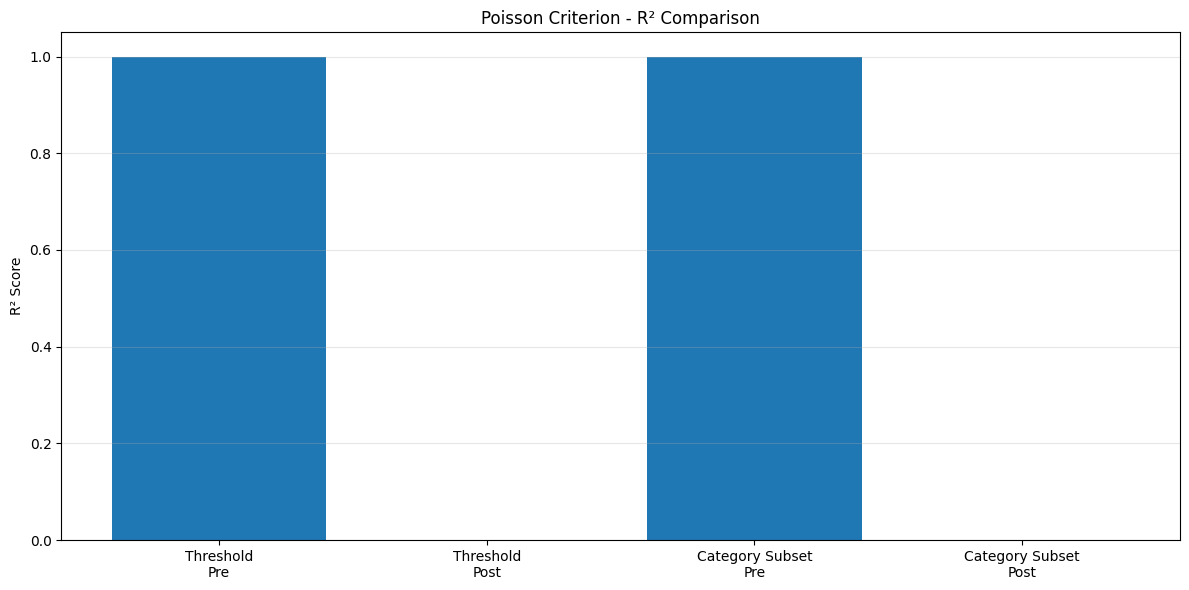

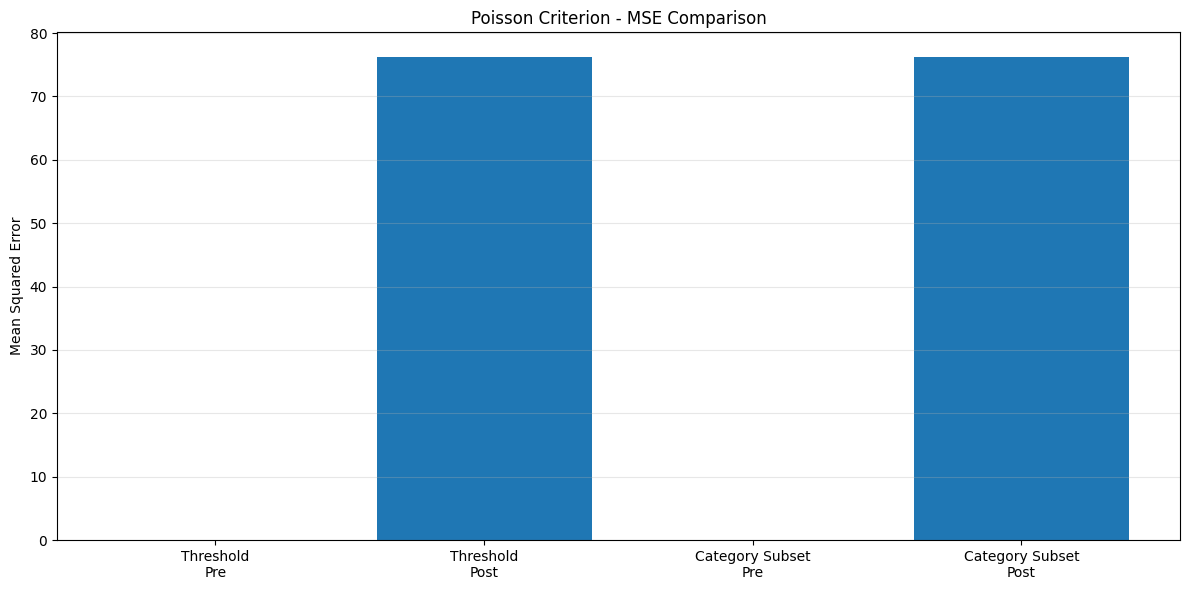

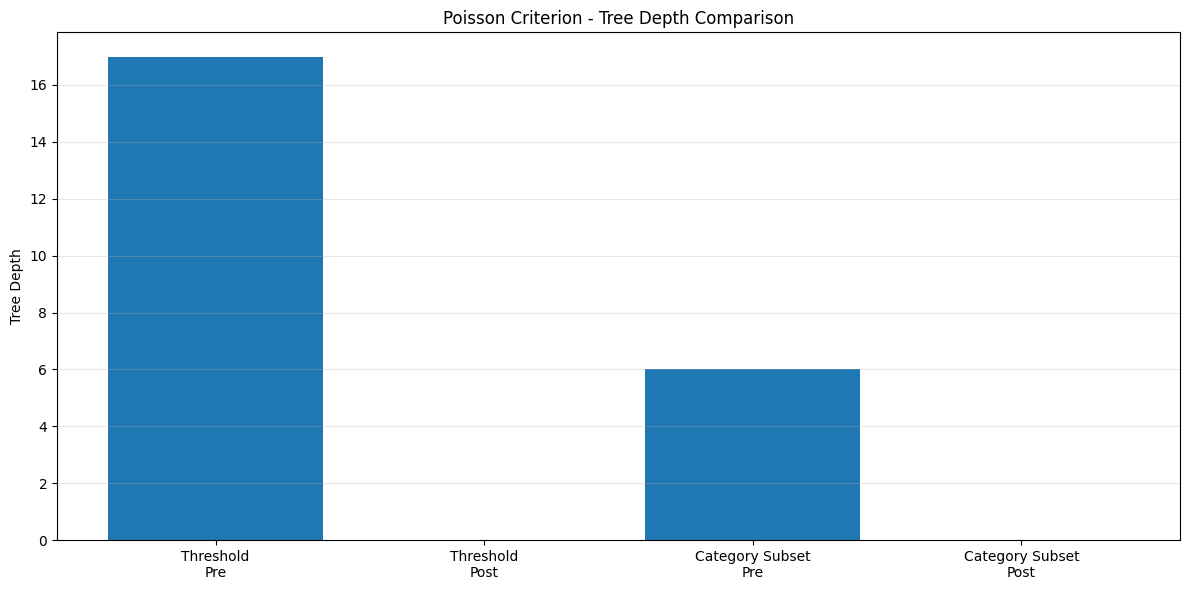

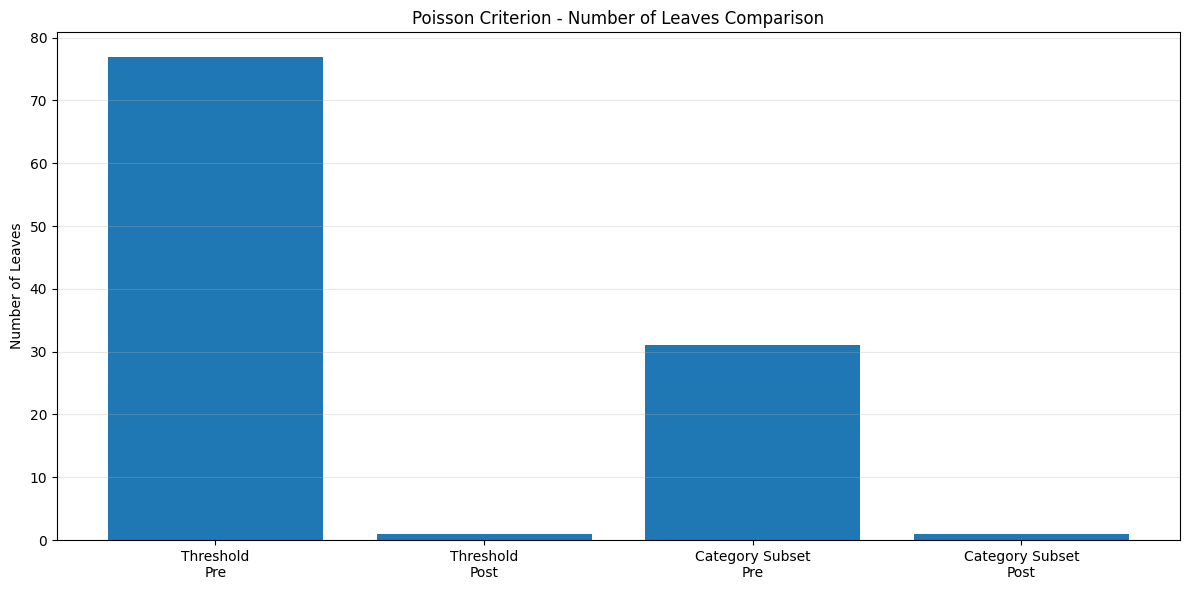

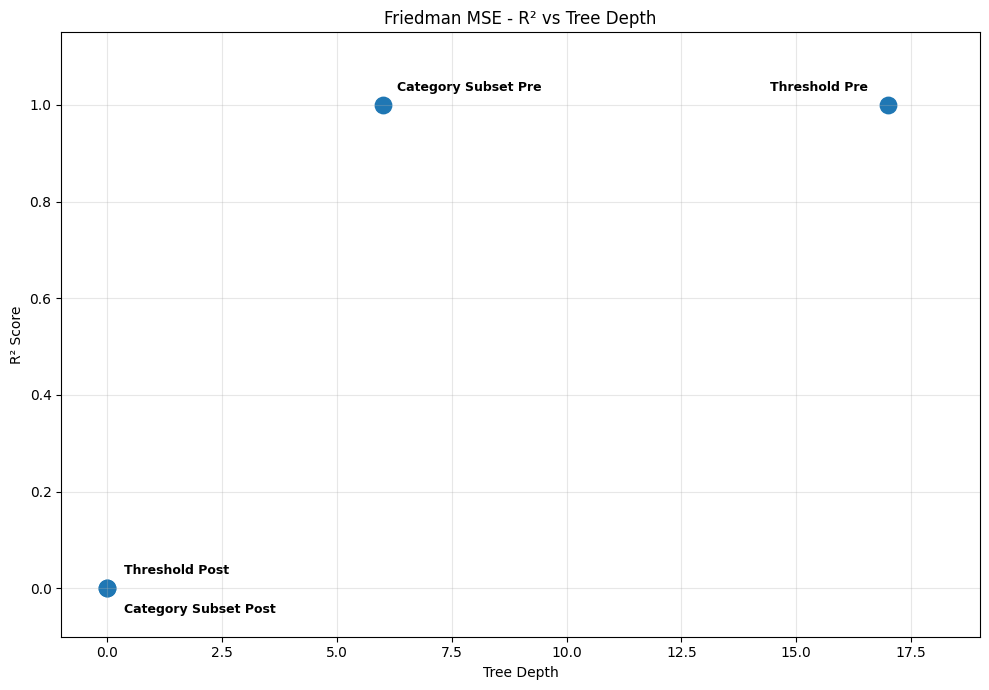

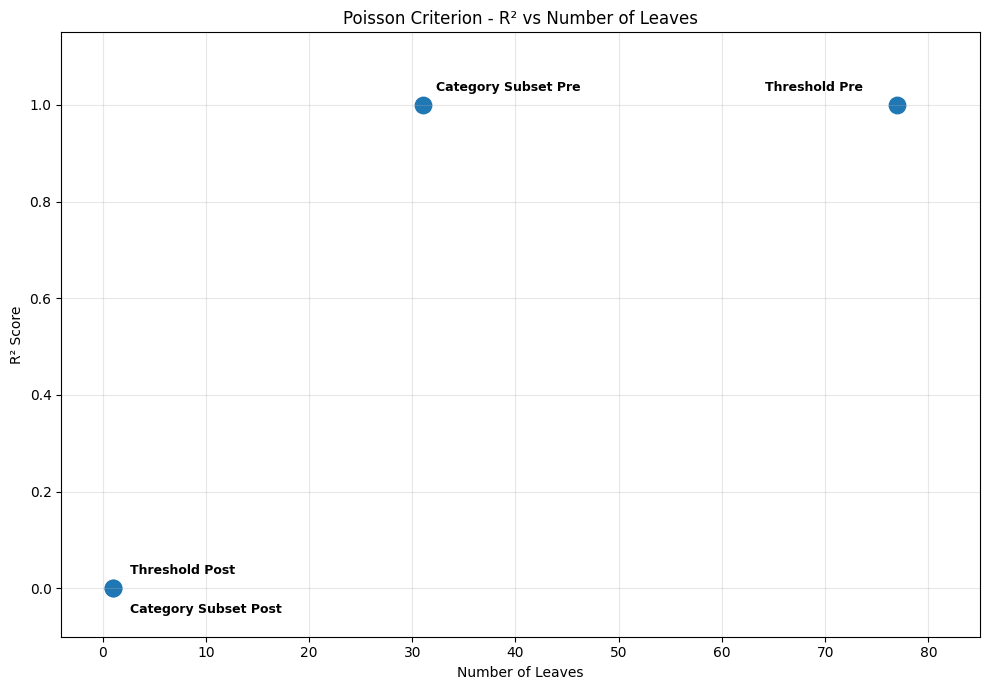

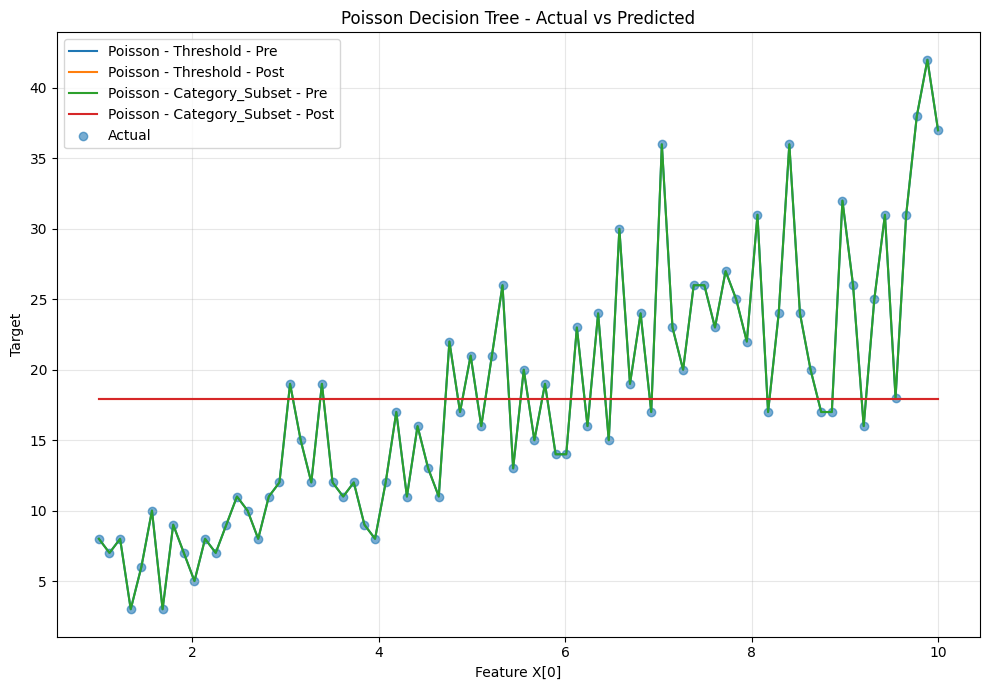

In [ ]:
# ============================================================
# DECISION TREE REGRESSOR FROM SCRATCH
#
# Criterion:
#     poisson
#
# Split strategies:
#     Threshold
#     Category_Subset
#
# Pruning:
#     Pre
#     Post
#
# NO SKLEARN USED
#
# Libraries:
#     NumPy
#     Matplotlib
#
# Poisson regression tree:
#     - Leaf prediction = mean(y)
#     - Split quality = reduction in Poisson deviance
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        split_value=None,
        category_subset=None,
        left=None,
        right=None,
        prediction=None,
        is_leaf=False
    ):

        self.feature_index = feature_index
        self.split_value = split_value
        self.category_subset = category_subset

        self.left = left
        self.right = right

        self.prediction = prediction

        self.is_leaf = is_leaf


# ============================================================
# 2. DECISION TREE REGRESSOR
# ============================================================

class DecisionTreeRegressor:

    def __init__(
        self,
        criterion="poisson",
        split_strategy="Threshold",
        pruning="Pre",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0,
        random_state=None
    ):

        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf

        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes

        self.min_impurity_decrease = (
            min_impurity_decrease
        )

        self.ccp_alpha = ccp_alpha

        self.random_state = random_state

        self.rng = np.random.default_rng(
            random_state
        )

        self.root_ = None

        self.n_features_in_ = None

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0


    # ========================================================
    # 3. FIT
    # ========================================================

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y, dtype=float)

        # ----------------------------------------------------
        # Validate X
        # ----------------------------------------------------

        if X.ndim != 2:

            raise ValueError(
                "X must be a 2-dimensional array."
            )

        # ----------------------------------------------------
        # Validate y
        # ----------------------------------------------------

        if y.ndim != 1:

            y = y.ravel()

        # ----------------------------------------------------
        # Check number of samples
        # ----------------------------------------------------

        if X.shape[0] != y.shape[0]:

            raise ValueError(
                "X and y have inconsistent numbers "
                f"of samples: {X.shape[0]} and {y.shape[0]}"
            )

        # ----------------------------------------------------
        # Check empty dataset
        # ----------------------------------------------------

        if X.shape[0] == 0:

            raise ValueError(
                "X and y cannot be empty."
            )

        # ----------------------------------------------------
        # Criterion validation
        # ----------------------------------------------------

        if self.criterion != "poisson":

            raise ValueError(
                'This implementation supports '
                'criterion="poisson".'
            )

        # ----------------------------------------------------
        # Split strategy validation
        # ----------------------------------------------------

        if self.split_strategy not in [
            "Threshold",
            "Category_Subset"
        ]:

            raise ValueError(
                'split_strategy must be '
                '"Threshold" or "Category_Subset".'
            )

        # ----------------------------------------------------
        # Pruning validation
        # ----------------------------------------------------

        if self.pruning not in [
            "Pre",
            "Post"
        ]:

            raise ValueError(
                'pruning must be "Pre" or "Post".'
            )

        # ----------------------------------------------------
        # Poisson requires non-negative target values
        # ----------------------------------------------------

        if np.any(y < 0):

            raise ValueError(
                "Poisson criterion requires "
                "non-negative target values."
            )

        # ----------------------------------------------------
        # Poisson tree requires positive mean
        # ----------------------------------------------------

        if np.mean(y) <= 0:

            raise ValueError(
                "Poisson criterion requires "
                "a positive target mean."
            )

        # ----------------------------------------------------
        # Store number of features
        # ----------------------------------------------------

        self.n_features_in_ = X.shape[1]

        # ----------------------------------------------------
        # Reset statistics
        # ----------------------------------------------------

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0

        # ----------------------------------------------------
        # Build tree
        # ----------------------------------------------------

        self.root_ = self._build_tree(
            X,
            y,
            depth=0
        )

        # ----------------------------------------------------
        # Post pruning
        # ----------------------------------------------------

        if self.pruning == "Post":

            self.root_ = self._post_prune(
                self.root_,
                X,
                y
            )

        # ----------------------------------------------------
        # Calculate tree statistics
        # ----------------------------------------------------

        self.n_leaves_ = self._count_leaves(
            self.root_
        )

        self.tree_depth_ = self._calculate_depth(
            self.root_
        )

        self.node_count_ = self._count_nodes(
            self.root_
        )

        return self


    # ========================================================
    # 4. POISSON DEVIANCE
    # ========================================================

    def _poisson_deviance(self, y):

        if len(y) == 0:

            return 0.0

        mean_y = np.mean(y)

        # ----------------------------------------------------
        # Avoid invalid logarithm
        # ----------------------------------------------------

        if mean_y <= 0:

            return 0.0

        y = np.asarray(y, dtype=float)

        # ----------------------------------------------------
        # For y = 0:
        #
        # y * log(y / mean) = 0
        #
        # For y > 0:
        #
        # y * log(y / mean)
        # ----------------------------------------------------

        positive_mask = y > 0

        term = np.zeros_like(y)

        term[positive_mask] = (
            y[positive_mask]
            *
            np.log(
                y[positive_mask] / mean_y
            )
        )

        # ----------------------------------------------------
        # Poisson deviance
        #
        # D =
        # 2 * sum[
        #     y log(y / mean)
        #     - (y - mean)
        # ]
        # ----------------------------------------------------

        deviance = 2.0 * np.sum(
            term
            -
            (y - mean_y)
        )

        # ----------------------------------------------------
        # Return average deviance
        # ----------------------------------------------------

        return deviance / len(y)


    # ========================================================
    # 5. POISSON IMPURITY DECREASE
    # ========================================================

    def _impurity_decrease(
        self,
        parent_y,
        left_y,
        right_y
    ):

        parent_impurity = (
            self._poisson_deviance(
                parent_y
            )
        )

        left_impurity = (
            self._poisson_deviance(
                left_y
            )
        )

        right_impurity = (
            self._poisson_deviance(
                right_y
            )
        )

        n = len(parent_y)

        left_weight = (
            len(left_y) / n
        )

        right_weight = (
            len(right_y) / n
        )

        weighted_child_impurity = (
            left_weight * left_impurity
            +
            right_weight * right_impurity
        )

        decrease = (
            parent_impurity
            -
            weighted_child_impurity
        )

        return decrease


    # ========================================================
    # 6. LEAF PREDICTION
    #
    # Poisson regression tree predicts:
    #
    #       mean(y)
    #
    # inside every leaf.
    # ========================================================

    def _leaf_prediction(self, y):

        if len(y) == 0:

            return 0.0

        return float(
            np.mean(y)
        )


    # ========================================================
    # 7. BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth
    ):

        self.node_count_ += 1

        prediction = (
            self._leaf_prediction(y)
        )

        # ----------------------------------------------------
        # Stopping conditions
        # ----------------------------------------------------

        if self._should_stop(
            X,
            y,
            depth
        ):

            return TreeNode(
                prediction=prediction,
                is_leaf=True
            )

        # ----------------------------------------------------
        # Find best split
        # ----------------------------------------------------

        best_split = (
            self._find_best_split(
                X,
                y
            )
        )

        # ----------------------------------------------------
        # No useful split
        # ----------------------------------------------------

        if best_split is None:

            return TreeNode(
                prediction=prediction,
                is_leaf=True
            )

        # ----------------------------------------------------
        # Check impurity decrease
        # ----------------------------------------------------

        decrease = (
            best_split[
                "impurity_decrease"
            ]
        )

        if (
            decrease
            <
            self.min_impurity_decrease
        ):

            return TreeNode(
                prediction=prediction,
                is_leaf=True
            )

        # ----------------------------------------------------
        # Check maximum leaf nodes
        # ----------------------------------------------------

        if (
            self.max_leaf_nodes is not None
            and self._count_leaves(self.root_)
            >= self.max_leaf_nodes
            if self.root_ is not None
            else False
        ):

            return TreeNode(
                prediction=prediction,
                is_leaf=True
            )

        # ----------------------------------------------------
        # Extract split information
        # ----------------------------------------------------

        feature_index = (
            best_split[
                "feature_index"
            ]
        )

        split_value = (
            best_split[
                "split_value"
            ]
        )

        category_subset = (
            best_split[
                "category_subset"
            ]
        )

        left_indices = (
            best_split[
                "left_indices"
            ]
        )

        right_indices = (
            best_split[
                "right_indices"
            ]
        )

        # ----------------------------------------------------
        # Create child datasets
        # ----------------------------------------------------

        X_left = X[left_indices]
        y_left = y[left_indices]

        X_right = X[right_indices]
        y_right = y[right_indices]

        # ----------------------------------------------------
        # Recursively build children
        # ----------------------------------------------------

        left_child = self._build_tree(
            X_left,
            y_left,
            depth + 1
        )

        right_child = self._build_tree(
            X_right,
            y_right,
            depth + 1
        )

        # ----------------------------------------------------
        # Return internal node
        # ----------------------------------------------------

        return TreeNode(

            feature_index=feature_index,

            split_value=split_value,

            category_subset=category_subset,

            left=left_child,

            right=right_child,

            prediction=prediction,

            is_leaf=False
        )


    # ========================================================
    # 8. PRE-PRUNING STOPPING CONDITIONS
    # ========================================================

    def _should_stop(
        self,
        X,
        y,
        depth
    ):

        # ----------------------------------------------------
        # All target values identical
        # ----------------------------------------------------

        if len(np.unique(y)) == 1:

            return True

        # ----------------------------------------------------
        # Maximum depth
        # ----------------------------------------------------

        if (
            self.max_depth is not None
            and depth >= self.max_depth
        ):

            return True

        # ----------------------------------------------------
        # Minimum samples for splitting
        # ----------------------------------------------------

        if (
            len(y)
            <
            self.min_samples_split
        ):

            return True

        # ----------------------------------------------------
        # Minimum samples per child
        # ----------------------------------------------------

        if (
            len(y)
            <
            2 * self.min_samples_leaf
        ):

            return True

        return False


    # ========================================================
    # 9. FIND BEST SPLIT
    # ========================================================

    def _find_best_split(
        self,
        X,
        y
    ):

        best_split = None

        best_decrease = -np.inf

        # ----------------------------------------------------
        # Feature indices
        # ----------------------------------------------------

        feature_indices = np.arange(
            X.shape[1]
        )

        # ----------------------------------------------------
        # max_features
        # ----------------------------------------------------

        if self.max_features is not None:

            if isinstance(
                self.max_features,
                int
            ):

                n_features = min(
                    self.max_features,
                    X.shape[1]
                )

                feature_indices = (
                    self.rng.choice(
                        X.shape[1],
                        size=n_features,
                        replace=False
                    )
                )

        # ----------------------------------------------------
        # Search every selected feature
        # ----------------------------------------------------

        for feature_index in feature_indices:

            column = X[
                :,
                feature_index
            ]

            # ------------------------------------------------
            # Threshold split
            # ------------------------------------------------

            if (
                self.split_strategy
                ==
                "Threshold"
            ):

                split = (
                    self._find_threshold_split(
                        column,
                        y,
                        feature_index
                    )
                )

            # ------------------------------------------------
            # Category subset split
            # ------------------------------------------------

            else:

                split = (
                    self._find_category_subset_split(
                        column,
                        y,
                        feature_index
                    )
                )

            # ------------------------------------------------
            # Keep best feature split
            # ------------------------------------------------

            if split is not None:

                decrease = (
                    split[
                        "impurity_decrease"
                    ]
                )

                if decrease > best_decrease:

                    best_decrease = decrease

                    best_split = split

        return best_split


    # ========================================================
    # 10. THRESHOLD SPLIT
    # ========================================================

    def _find_threshold_split(
        self,
        column,
        y,
        feature_index
    ):

        try:

            values = column.astype(
                float
            )

        except:

            return None

        unique_values = np.unique(
            values
        )

        # ----------------------------------------------------
        # At least two unique values required
        # ----------------------------------------------------

        if len(unique_values) < 2:

            return None

        # ----------------------------------------------------
        # Candidate thresholds
        #
        # midpoint between consecutive
        # unique values.
        # ----------------------------------------------------

        thresholds = (
            unique_values[:-1]
            +
            unique_values[1:]
        ) / 2.0

        best_split = None

        best_decrease = -np.inf

        # ----------------------------------------------------
        # Test every threshold
        # ----------------------------------------------------

        for threshold in thresholds:

            left_indices = np.where(
                values <= threshold
            )[0]

            right_indices = np.where(
                values > threshold
            )[0]

            # ------------------------------------------------
            # Minimum leaf size
            # ------------------------------------------------

            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):

                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):

                continue

            left_y = y[
                left_indices
            ]

            right_y = y[
                right_indices
            ]

            # ------------------------------------------------
            # Calculate Poisson impurity reduction
            # ------------------------------------------------

            decrease = (
                self._impurity_decrease(
                    y,
                    left_y,
                    right_y
                )
            )

            # ------------------------------------------------
            # Keep best threshold
            # ------------------------------------------------

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        threshold,

                    "category_subset":
                        None,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 11. CATEGORY SUBSET SPLIT
    # ========================================================

    def _find_category_subset_split(
        self,
        column,
        y,
        feature_index
    ):

        categories = np.unique(
            column
        )

        # ----------------------------------------------------
        # Need at least two categories
        # ----------------------------------------------------

        if len(categories) < 2:

            return None

        subsets = []

        # ====================================================
        # BINARY CATEGORY
        # ====================================================

        if len(categories) == 2:

            subsets = [
                {categories[0]}
            ]

        # ====================================================
        # SMALL NUMBER OF CATEGORIES
        #
        # Enumerate unique subsets while avoiding
        # duplicate complementary splits.
        # ====================================================

        elif len(categories) <= 10:

            from itertools import combinations

            first_category = (
                categories[0]
            )

            remaining = (
                categories[1:]
            )

            for r in range(
                len(remaining) + 1
            ):

                for combo in combinations(
                    remaining,
                    r
                ):

                    subset = {
                        first_category,
                        *combo
                    }

                    # ----------------------------------------
                    # Avoid selecting all categories
                    # ----------------------------------------

                    if (
                        len(subset)
                        <
                        len(categories)
                    ):

                        subsets.append(
                            subset
                        )

        # ====================================================
        # LARGE NUMBER OF CATEGORIES
        #
        # Order categories by their target mean and
        # evaluate ordered prefix splits.
        # ====================================================

        else:

            category_means = []

            for category in categories:

                mask = (
                    column == category
                )

                category_y = y[
                    mask
                ]

                mean_value = (
                    np.mean(category_y)
                )

                category_means.append(
                    (
                        category,
                        mean_value
                    )
                )

            category_means.sort(
                key=lambda x: x[1]
            )

            ordered_categories = [
                item[0]
                for item in category_means
            ]

            for i in range(
                1,
                len(ordered_categories)
            ):

                subsets.append(
                    set(
                        ordered_categories[:i]
                    )
                )

        # ====================================================
        # SEARCH BEST CATEGORY SUBSET
        # ====================================================

        best_split = None

        best_decrease = -np.inf

        for subset in subsets:

            left_mask = np.array([
                value in subset
                for value in column
            ])

            right_mask = ~left_mask

            left_indices = np.where(
                left_mask
            )[0]

            right_indices = np.where(
                right_mask
            )[0]

            # ------------------------------------------------
            # Minimum leaf size
            # ------------------------------------------------

            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):

                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):

                continue

            left_y = y[
                left_indices
            ]

            right_y = y[
                right_indices
            ]

            # ------------------------------------------------
            # Calculate impurity decrease
            # ------------------------------------------------

            decrease = (
                self._impurity_decrease(
                    y,
                    left_y,
                    right_y
                )
            )

            # ------------------------------------------------
            # Keep best subset
            # ------------------------------------------------

            if decrease > best_decrease:

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        None,

                    "category_subset":
                        subset,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 12. PREDICT ONE SAMPLE
    # ========================================================

    def _predict_one(
        self,
        x
    ):

        node = self.root_

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            # ------------------------------------------------
            # Threshold split
            # ------------------------------------------------

            if (
                node.category_subset
                is None
            ):

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            # ------------------------------------------------
            # Category subset split
            # ------------------------------------------------

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 13. PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(X)

        if X.ndim == 1:

            X = X.reshape(
                1,
                -1
            )

        predictions = np.array([

            self._predict_one(x)

            for x in X

        ])

        return predictions


    # ========================================================
    # 14. R-SQUARED SCORE
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        y = np.asarray(
            y,
            dtype=float
        )

        predictions = (
            self.predict(X)
        )

        # ----------------------------------------------------
        # Total Sum of Squares
        # ----------------------------------------------------

        ss_total = np.sum(
            (y - np.mean(y)) ** 2
        )

        # ----------------------------------------------------
        # Residual Sum of Squares
        # ----------------------------------------------------

        ss_residual = np.sum(
            (y - predictions) ** 2
        )

        # ----------------------------------------------------
        # R²
        # ----------------------------------------------------

        if ss_total == 0:

            return 0.0

        return (
            1
            -
            ss_residual / ss_total
        )


    # ========================================================
    # 15. COUNT LEAVES
    # ========================================================

    def _count_leaves(
        self,
        node
    ):

        if node is None:

            return 0

        if node.is_leaf:

            return 1

        return (
            self._count_leaves(
                node.left
            )
            +
            self._count_leaves(
                node.right
            )
        )


    # ========================================================
    # 16. COUNT NODES
    # ========================================================

    def _count_nodes(
        self,
        node
    ):

        if node is None:

            return 0

        if node.is_leaf:

            return 1

        return (
            1
            +
            self._count_nodes(
                node.left
            )
            +
            self._count_nodes(
                node.right
            )
        )


    # ========================================================
    # 17. CALCULATE DEPTH
    # ========================================================

    def _calculate_depth(
        self,
        node
    ):

        if node is None:

            return 0

        if node.is_leaf:

            return 0

        return (
            1
            +
            max(
                self._calculate_depth(
                    node.left
                ),
                self._calculate_depth(
                    node.right
                )
            )
        )


    # ========================================================
    # 18. GET DEPTH
    # ========================================================

    def get_depth(self):

        return self.tree_depth_


    # ========================================================
    # 19. GET NUMBER OF LEAVES
    # ========================================================

    def get_n_leaves(self):

        return self.n_leaves_


    # ========================================================
    # 20. SPLIT INDICES FOR NODE
    # ========================================================

    def _split_indices_for_node(
        self,
        node,
        X
    ):

        values = X[
            :,
            node.feature_index
        ]

        # ----------------------------------------------------
        # Threshold
        # ----------------------------------------------------

        if (
            node.category_subset
            is None
        ):

            values = values.astype(
                float
            )

            left_mask = (
                values
                <=
                node.split_value
            )

        # ----------------------------------------------------
        # Category subset
        # ----------------------------------------------------

        else:

            left_mask = np.array([

                value
                in
                node.category_subset

                for value in values

            ])

        right_mask = ~left_mask

        return (
            np.where(left_mask)[0],
            np.where(right_mask)[0]
        )


    # ========================================================
    # 21. POST-PRUNING
    #
    # Cost-complexity style pruning:
    #
    #     Cost =
    #     prediction error
    #     +
    #     ccp_alpha * number_of_leaves
    #
    # Compare:
    #
    #     subtree cost
    #
    # versus
    #
    #     leaf cost
    # ========================================================

    def _post_prune(
        self,
        node,
        X,
        y
    ):

        if node is None:

            return node

        if node.is_leaf:

            return node

        if len(y) == 0:

            return node

        # ----------------------------------------------------
        # Find samples belonging to children
        # ----------------------------------------------------

        left_indices, right_indices = (
            self._split_indices_for_node(
                node,
                X
            )
        )

        X_left = X[
            left_indices
        ]

        y_left = y[
            left_indices
        ]

        X_right = X[
            right_indices
        ]

        y_right = y[
            right_indices
        ]

        # ----------------------------------------------------
        # Recursively prune children
        # ----------------------------------------------------

        node.left = self._post_prune(
            node.left,
            X_left,
            y_left
        )

        node.right = self._post_prune(
            node.right,
            X_right,
            y_right
        )

        # ----------------------------------------------------
        # Predictions from current subtree
        # ----------------------------------------------------

        subtree_predictions = np.array([

            self._predict_node(
                node,
                x
            )

            for x in X

        ])

        # ----------------------------------------------------
        # Poisson deviance of subtree
        # ----------------------------------------------------

        subtree_error = (
            self._poisson_deviance(
                y
            )
            *
            len(y)
        )

        # ----------------------------------------------------
        # Leaf prediction
        # ----------------------------------------------------

        leaf_prediction = (
            self._leaf_prediction(
                y
            )
        )

        # ----------------------------------------------------
        # Leaf error
        # ----------------------------------------------------

        leaf_error = (
            self._poisson_deviance(
                y
            )
            *
            len(y)
        )

        # ----------------------------------------------------
        # Number of leaves in subtree
        # ----------------------------------------------------

        subtree_leaves = (
            self._count_leaves(
                node
            )
        )

        # ----------------------------------------------------
        # Cost-complexity cost
        # ----------------------------------------------------

        subtree_cost = (
            subtree_error
            +
            self.ccp_alpha
            * subtree_leaves
        )

        leaf_cost = (
            leaf_error
            +
            self.ccp_alpha
        )

        # ----------------------------------------------------
        # Replace subtree by leaf
        # ----------------------------------------------------

        if (
            leaf_cost
            <=
            subtree_cost
        ):

            node = TreeNode(

                prediction=leaf_prediction,

                is_leaf=True
            )

        return node


    # ========================================================
    # 22. PREDICT FROM SPECIFIC NODE
    # ========================================================

    def _predict_node(
        self,
        node,
        x
    ):

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            # ------------------------------------------------
            # Threshold
            # ------------------------------------------------

            if (
                node.category_subset
                is None
            ):

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            # ------------------------------------------------
            # Category subset
            # ------------------------------------------------

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 23. PRINT TREE
    #
    # Optional debugging method.
    #
    # NOT automatically called during comparison.
    # ========================================================

    def print_tree(
        self,
        node=None,
        depth=0
    ):

        if node is None:

            node = self.root_

        indentation = (
            "    " * depth
        )

        if node.is_leaf:

            print(
                indentation
                +
                f"Leaf: prediction="
                f"{node.prediction:.4f}"
            )

            return

        if (
            node.category_subset
            is None
        ):

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"<= "
                f"{node.split_value:.4f}"
            )

        else:

            print(
                indentation
                +
                f"X[{node.feature_index}] "
                f"in "
                f"{node.category_subset}"
            )

        self.print_tree(
            node.left,
            depth + 1
        )

        self.print_tree(
            node.right,
            depth + 1
        )


# ============================================================
# 24. CREATE POISSON-LIKE SAMPLE DATA
#
# Target values are non-negative counts.
#
# We intentionally create count-like data so that the
# Poisson criterion is meaningful.
# ============================================================

rng = np.random.default_rng(42)

# ------------------------------------------------------------
# Feature
# ------------------------------------------------------------

X = np.linspace(
    1,
    10,
    80
).reshape(
    -1,
    1
)

# ------------------------------------------------------------
# Generate increasing Poisson mean
# ------------------------------------------------------------

lambda_values = (
    2.0
    +
    3.0 * X[:, 0]
)

# ------------------------------------------------------------
# Generate count target
# ------------------------------------------------------------

y = rng.poisson(
    lambda_values
).astype(float)


# ============================================================
# 25. FOUR REQUIRED CONFIGURATIONS
# ============================================================

models = {

    # --------------------------------------------------------
    # 1. Poisson + Threshold + Pre
    # --------------------------------------------------------

    "Poisson - Threshold - Pre":

        DecisionTreeRegressor(

            criterion="poisson",

            split_strategy="Threshold",

            pruning="Pre",

            max_depth=None,

            min_samples_split=2,

            min_samples_leaf=1,

            max_features=None,

            max_leaf_nodes=None,

            min_impurity_decrease=0.0,

            random_state=42
        ),


    # --------------------------------------------------------
    # 2. Poisson + Threshold + Post
    # --------------------------------------------------------

    "Poisson - Threshold - Post":

        DecisionTreeRegressor(

            criterion="poisson",

            split_strategy="Threshold",

            pruning="Post",

            max_depth=None,

            min_samples_split=2,

            min_samples_leaf=1,

            max_features=None,

            max_leaf_nodes=None,

            min_impurity_decrease=0.0,

            ccp_alpha=0.0,

            random_state=42
        ),


    # --------------------------------------------------------
    # 3. Poisson + Category Subset + Pre
    # --------------------------------------------------------

    "Poisson - Category_Subset - Pre":

        DecisionTreeRegressor(

            criterion="poisson",

            split_strategy="Category_Subset",

            pruning="Pre",

            max_depth=None,

            min_samples_split=2,

            min_samples_leaf=1,

            max_features=None,

            max_leaf_nodes=None,

            min_impurity_decrease=0.0,

            random_state=42
        ),


    # --------------------------------------------------------
    # 4. Poisson + Category Subset + Post
    # --------------------------------------------------------

    "Poisson - Category_Subset - Post":

        DecisionTreeRegressor(

            criterion="poisson",

            split_strategy="Category_Subset",

            pruning="Post",

            max_depth=None,

            min_samples_split=2,

            min_samples_leaf=1,

            max_features=None,

            max_leaf_nodes=None,

            min_impurity_decrease=0.0,

            ccp_alpha=0.0,

            random_state=42
        )
}


# ============================================================
# 26. TRAIN ALL MODELS
# ============================================================

results = {}


for name, model in models.items():

    model.fit(
        X,
        y
    )

    predictions = model.predict(
        X
    )

    r2 = model.score(
        X,
        y
    )

    mse = np.mean(
        (y - predictions) ** 2
    )

    poisson_deviance = (
        model._poisson_deviance(
            y - 0
        )
    )

    depth = model.get_depth()

    leaves = model.get_n_leaves()

    results[name] = {

        "r2": r2,

        "mse": mse,

        "depth": depth,

        "leaves": leaves
    }


# ============================================================
# 27. CLEAN COMPARISON OUTPUT
# ============================================================

print()
print("=" * 80)
print("                 POISSON DECISION TREE RESULTS")
print("=" * 80)


for name, result in results.items():

    print()
    print(name)
    print("-" * 60)

    print(
        f"R² Accuracy       : "
        f"{result['r2']:.4f}"
    )

    print(
        f"MSE               : "
        f"{result['mse']:.4f}"
    )

    print(
        f"Tree Depth        : "
        f"{result['depth']}"
    )

    print(
        f"Number of Leaves  : "
        f"{result['leaves']}"
    )


print()
print("=" * 80)


# ============================================================
# 28. PREPARE PLOT DATA
# ============================================================

names = list(
    results.keys()
)

plot_labels = [

    "Threshold\nPre",

    "Threshold\nPost",

    "Category Subset\nPre",

    "Category Subset\nPost"
]


r2_values = [

    results[name]["r2"]

    for name in names
]


mse_values = [

    results[name]["mse"]

    for name in names
]


depth_values = [

    results[name]["depth"]

    for name in names
]


leaf_values = [

    results[name]["leaves"]

    for name in names
]


x_positions = np.arange(
    len(names)
)


# ============================================================
# 29. R² COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    x_positions,
    r2_values
)

plt.xticks(
    x_positions,
    plot_labels
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "Poisson Criterion - R² Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 30. MSE COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    x_positions,
    mse_values
)

plt.xticks(
    x_positions,
    plot_labels
)

plt.ylabel(
    "Mean Squared Error"
)

plt.title(
    "Poisson Criterion - MSE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 31. TREE DEPTH COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    x_positions,
    depth_values
)

plt.xticks(
    x_positions,
    plot_labels
)

plt.ylabel(
    "Tree Depth"
)

plt.title(
    "Poisson Criterion - Tree Depth Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 32. NUMBER OF LEAVES COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.bar(
    x_positions,
    leaf_values
)

plt.xticks(
    x_positions,
    plot_labels
)

plt.ylabel(
    "Number of Leaves"
)

plt.title(
    "Poisson Criterion - Number of Leaves Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 33. R² VS TREE COMPLEXITY
# ============================================================

names = list(results.keys())
r2_scores = [results[name]["r2"] for name in names]
depths = [results[name]["depth"] for name in names]
short_names = [
    "Threshold Pre",
    "Threshold Post",
    "Category Subset Pre",
    "Category Subset Post",
]

plt.figure(figsize=(10, 7))
plt.scatter(depths, r2_scores, s=140)

# Offsets to prevent overlapping points at (2, 0.1299) and (17, 1.0)
offsets = [
    (-85, 10),  # Threshold Pre: top-left (stays inside right canvas)
    (12, 10),  # Threshold Post: placed ABOVE (0, 0)
    (10, 10),  # Category Subset Pre: top-right of (6, 1.0)
    (12, -18),  # Category Subset Post: placed BELOW (0, 0)
]

for i in range(len(names)):
    plt.annotate(
        short_names[i],
        (depths[i], r2_scores[i]),
        xytext=offsets[i % len(offsets)],
        textcoords="offset points",
        fontsize=9,
        weight="semibold",
    )

plt.xlabel("Tree Depth")
plt.ylabel("R² Score")
plt.title("Friedman MSE - R² vs Tree Depth")

# Padding so top/bottom text labels do not clip outside the canvas
plt.ylim(min(r2_scores) - 0.1, max(r2_scores) + 0.15)
plt.xlim(min(depths) - 1, max(depths) + 2)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 34. R² VS NUMBER OF LEAVES (FIXED ANNOTATIONS)
# ============================================================

plt.figure(figsize=(10, 7))
plt.scatter(leaf_values, r2_values, s=140)

# Replace multiline breaks with single line text
clean_labels = [label.replace("\n", " ") for label in plot_labels]

# Distinct directional offsets for each of the 4 points
custom_offsets = [
    (
        -95,
        10,
    ),  # Threshold Pre: shifted left to prevent clipping on right border
    (12, 10),  # Threshold Post: placed ABOVE (1, 0)
    (10, 10),  # Category Subset Pre: top-right of (31, 1.0)
    (12, -18),  # Category Subset Post: placed BELOW (1, 0)
]

for i in range(len(names)):
    plt.annotate(
        clean_labels[i],
        (leaf_values[i], r2_values[i]),
        xytext=custom_offsets[i],
        textcoords="offset points",
        fontsize=9,
        weight="semibold",
    )

plt.xlabel("Number of Leaves")
plt.ylabel("R² Score")
plt.title("Poisson Criterion - R² vs Number of Leaves")

# Add padding to avoid edge clipping
plt.ylim(min(r2_values) - 0.1, max(r2_values) + 0.15)
plt.xlim(min(leaf_values) - 5, max(leaf_values) + 8)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 35. ACTUAL VS PREDICTED
#
# Shows how well the Poisson regression tree
# predicts the target values.
# ============================================================

plt.figure(
    figsize=(10, 7)
)

for name, model in models.items():

    predictions = model.predict(
        X
    )

    plt.plot(
        X[:, 0],
        predictions,
        label=name
    )

plt.scatter(
    X[:, 0],
    y,
    alpha=0.6,
    label="Actual"
)

plt.xlabel(
    "Feature X[0]"
)

plt.ylabel(
    "Target"
)

plt.title(
    "Poisson Decision Tree - Actual vs Predicted"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


              VARIANCE DECISION TREE RESULTS

Variance - Threshold - Pre
------------------------------------------------------------
R² Accuracy : 1.0000
MSE         : 0.0000
MAE         : 0.0000
Depth       : 13
Leaves      : 80

Variance - Threshold - Post
------------------------------------------------------------
R² Accuracy : 1.0000
MSE         : 0.0000
MAE         : 0.0000
Depth       : 13
Leaves      : 80

Variance - Category_Subset - Pre
------------------------------------------------------------
R² Accuracy : 1.0000
MSE         : 0.0000
MAE         : 0.0000
Depth       : 10
Leaves      : 80

Variance - Category_Subset - Post
------------------------------------------------------------
R² Accuracy : 1.0000
MSE         : 0.0000
MAE         : 0.0000
Depth       : 10
Leaves      : 80



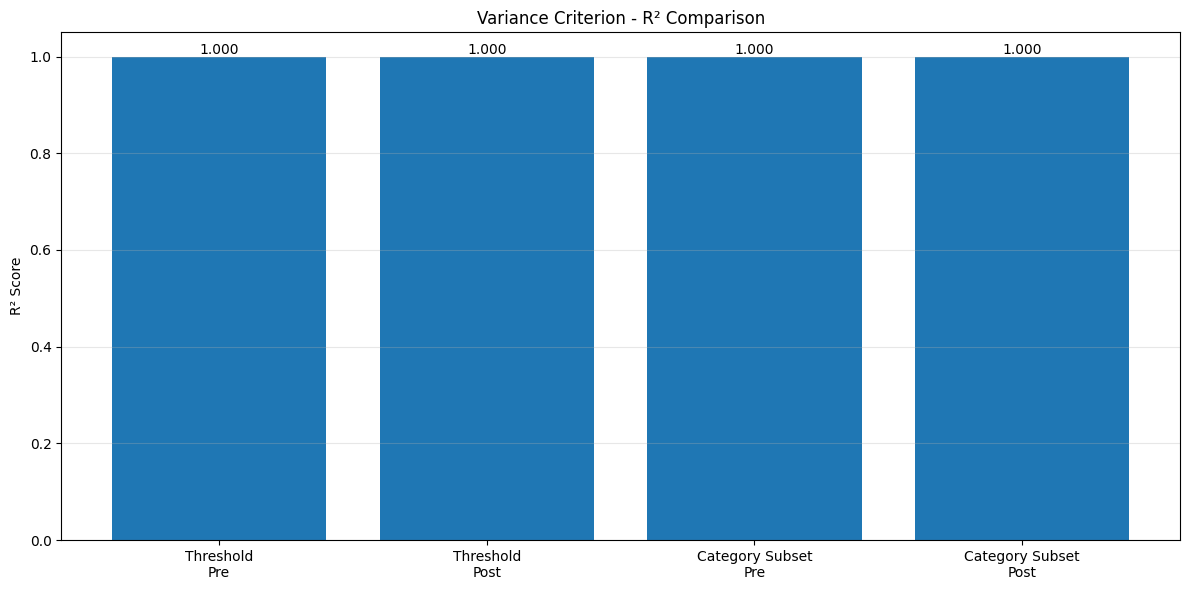

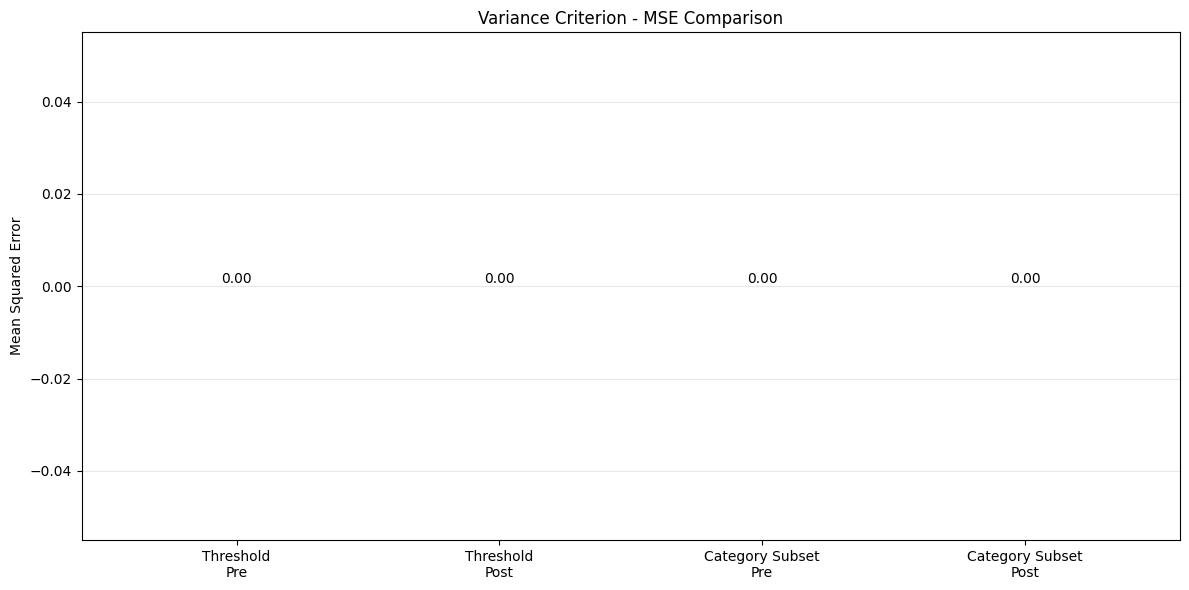

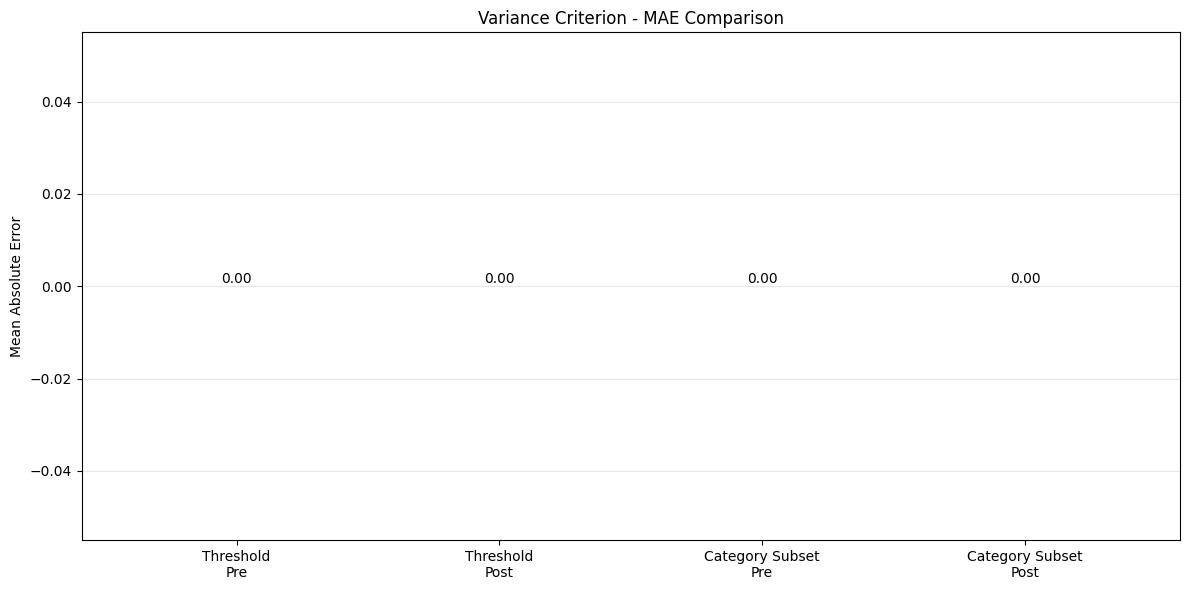

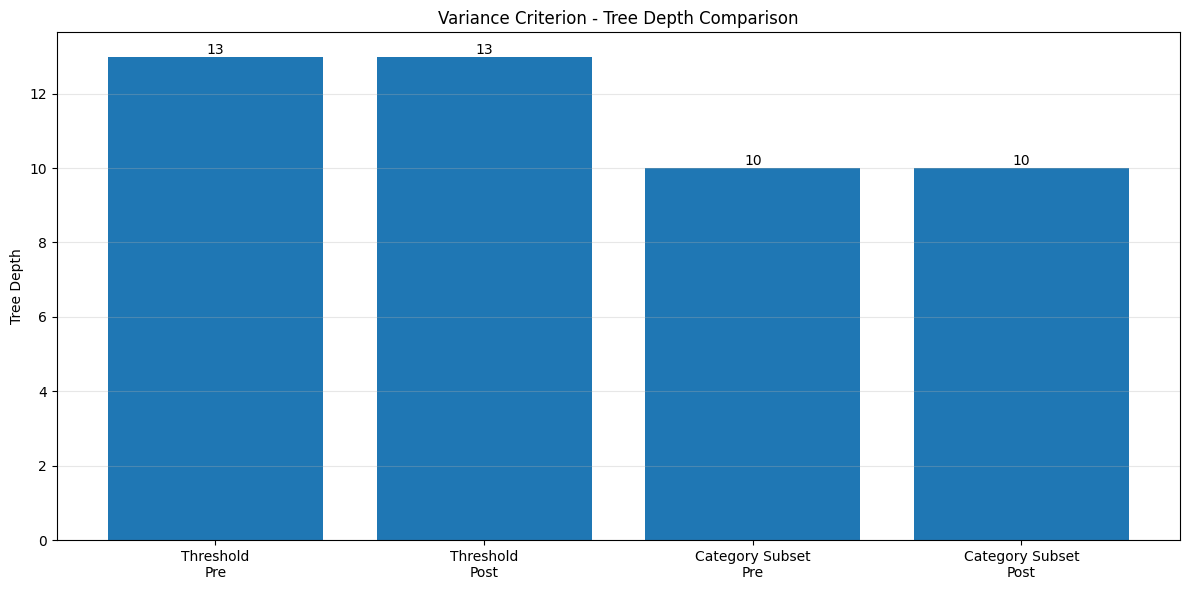

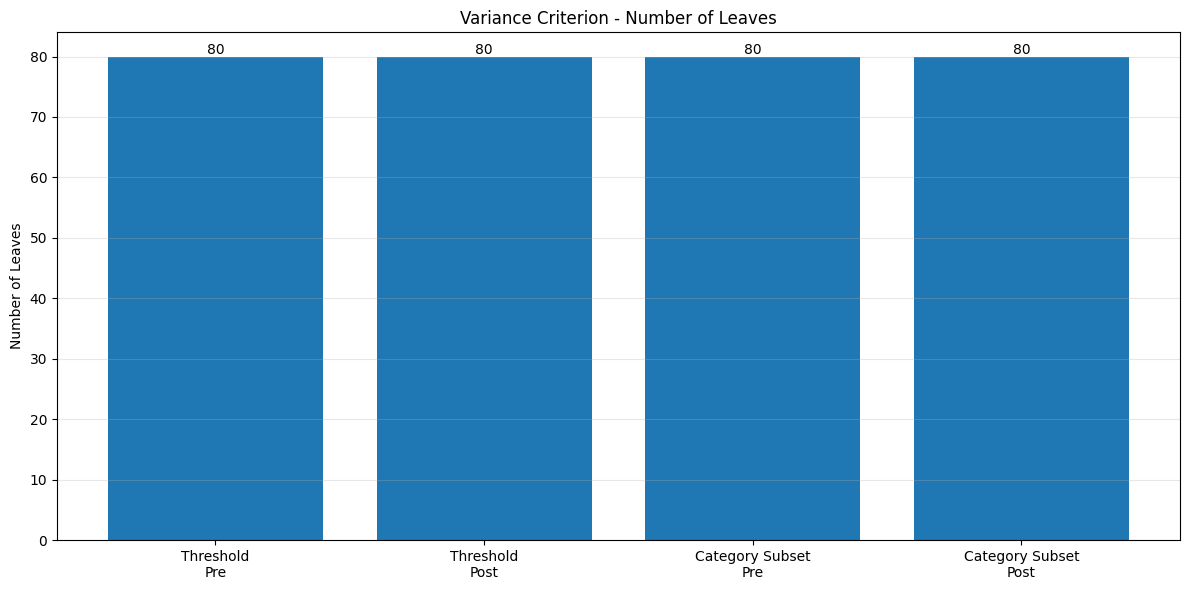

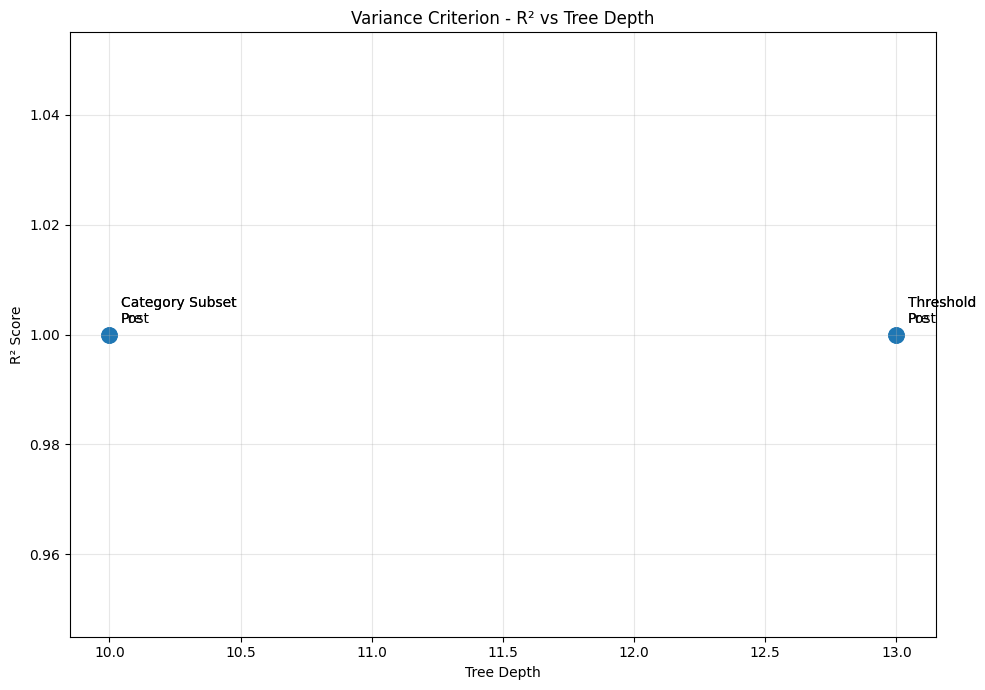

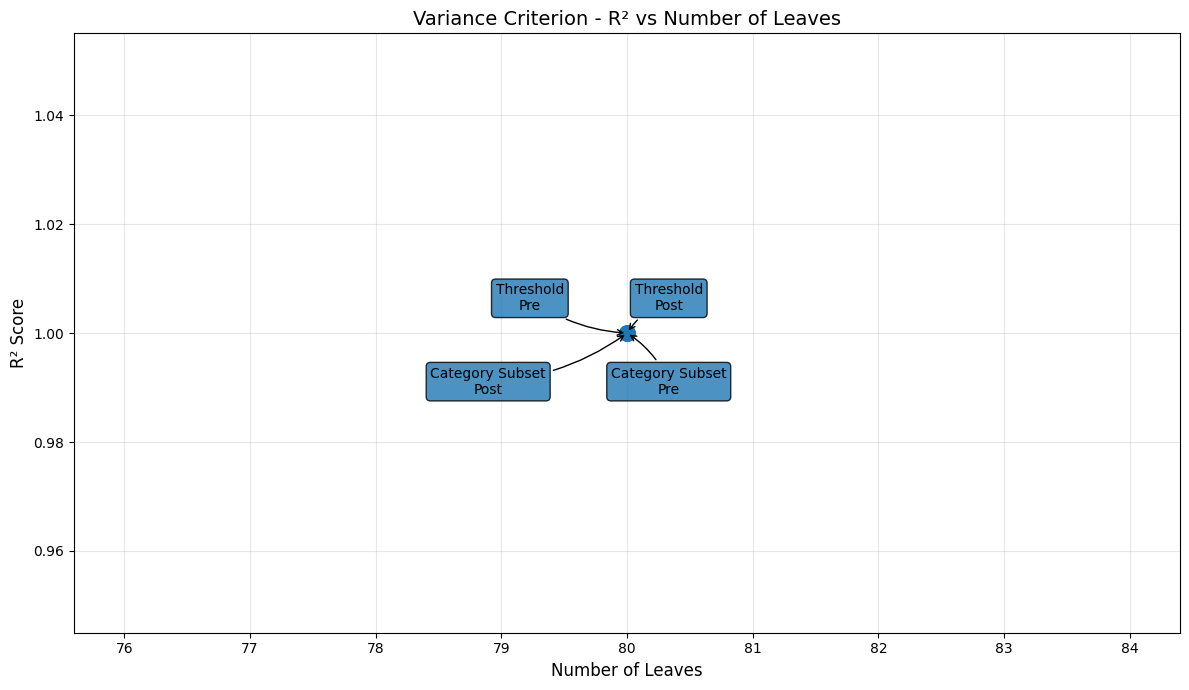

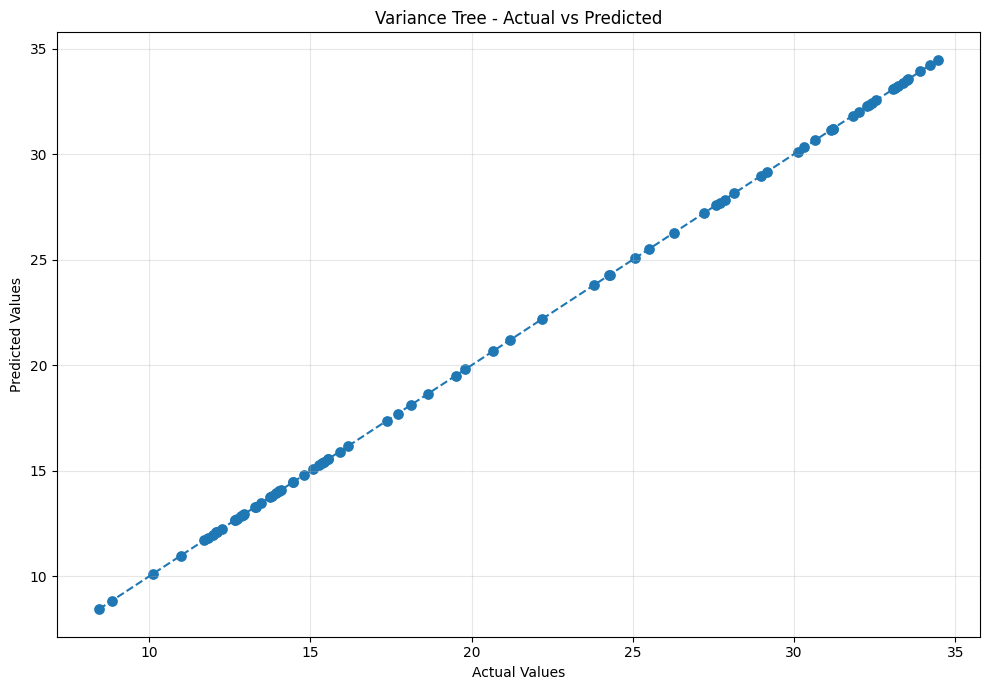

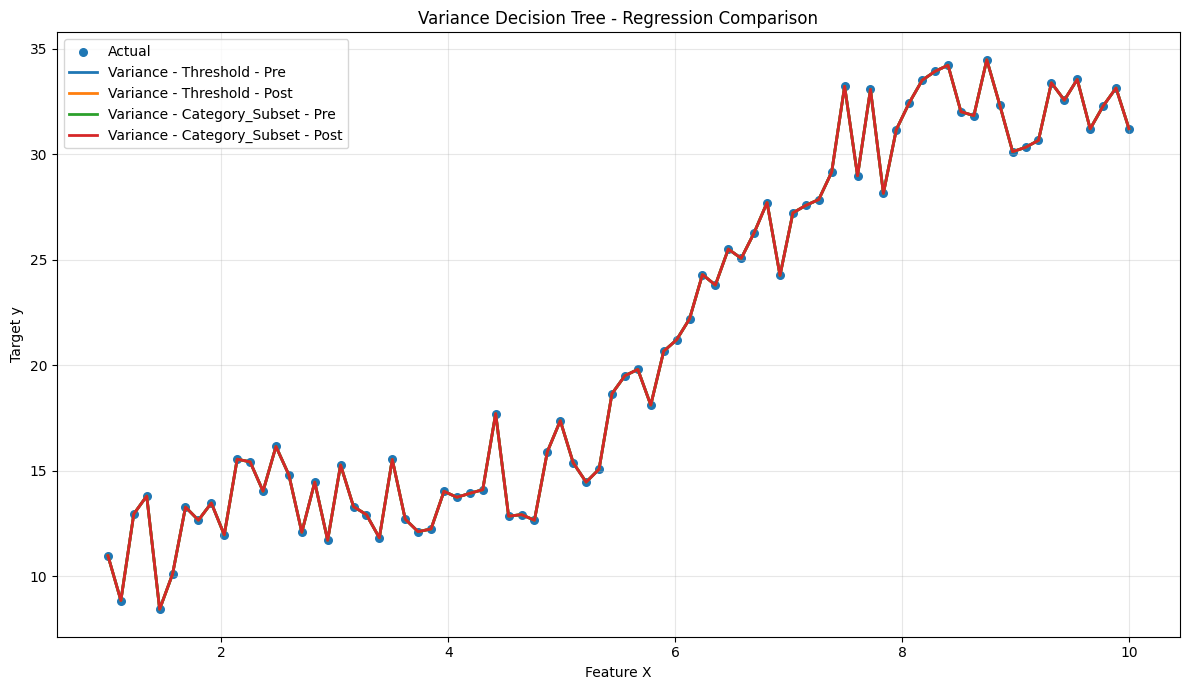

In [ ]:
# ============================================================
# DECISION TREE REGRESSOR FROM SCRATCH
#
# Criterion:
#     variance
#
# Split strategies:
#     Threshold
#     Category_Subset
#
# Pruning:
#     Pre
#     Post
#
# IMPLEMENTED FROM SCRATCH
# No sklearn is used.
#
# Libraries:
#     NumPy
#     Matplotlib
# ============================================================


import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. TREE NODE
# ============================================================

class TreeNode:

    def __init__(
        self,
        feature_index=None,
        split_value=None,
        category_subset=None,
        left=None,
        right=None,
        prediction=None,
        impurity=None,
        n_samples=0,
        is_leaf=False
    ):

        self.feature_index = feature_index
        self.split_value = split_value
        self.category_subset = category_subset

        self.left = left
        self.right = right

        self.prediction = prediction
        self.impurity = impurity
        self.n_samples = n_samples

        self.is_leaf = is_leaf


# ============================================================
# 2. DECISION TREE REGRESSOR
# ============================================================

class DecisionTreeRegressor:

    def __init__(
        self,
        criterion="variance",
        split_strategy="Threshold",
        pruning="Pre",
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        ccp_alpha=0.0,
        random_state=None
    ):

        # ----------------------------------------------------
        # Parameters
        # ----------------------------------------------------

        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf

        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes

        self.min_impurity_decrease = (
            min_impurity_decrease
        )

        self.ccp_alpha = ccp_alpha

        self.random_state = random_state

        self.rng = np.random.default_rng(
            random_state
        )

        # ----------------------------------------------------
        # Tree attributes
        # ----------------------------------------------------

        self.root_ = None

        self.n_features_in_ = None

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0


    # ========================================================
    # 3. FIT
    # ========================================================

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y, dtype=float)

        # ----------------------------------------------------
        # Validate X
        # ----------------------------------------------------

        if X.ndim != 2:

            raise ValueError(
                "X must be a 2-dimensional array."
            )

        # ----------------------------------------------------
        # Validate y
        # ----------------------------------------------------

        if y.ndim != 1:

            y = y.ravel()

        # ----------------------------------------------------
        # Check sample counts
        # ----------------------------------------------------

        if X.shape[0] != y.shape[0]:

            raise ValueError(
                "X and y have inconsistent numbers "
                f"of samples: {X.shape[0]} and {y.shape[0]}"
            )

        # ----------------------------------------------------
        # Empty dataset
        # ----------------------------------------------------

        if X.shape[0] == 0:

            raise ValueError(
                "X and y cannot be empty."
            )

        # ----------------------------------------------------
        # Criterion validation
        # ----------------------------------------------------

        if self.criterion != "variance":

            raise ValueError(
                'This implementation supports '
                'criterion="variance".'
            )

        # ----------------------------------------------------
        # Split strategy validation
        # ----------------------------------------------------

        if self.split_strategy not in [
            "Threshold",
            "Category_Subset"
        ]:

            raise ValueError(
                'split_strategy must be '
                '"Threshold" or "Category_Subset".'
            )

        # ----------------------------------------------------
        # Pruning validation
        # ----------------------------------------------------

        if self.pruning not in [
            "Pre",
            "Post"
        ]:

            raise ValueError(
                'pruning must be "Pre" or "Post".'
            )

        # ----------------------------------------------------
        # Number of features
        # ----------------------------------------------------

        self.n_features_in_ = X.shape[1]

        # ----------------------------------------------------
        # Reset statistics
        # ----------------------------------------------------

        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0

        # ----------------------------------------------------
        # Build tree
        # ----------------------------------------------------

        self.root_ = self._build_tree(
            X,
            y,
            depth=0
        )

        # ----------------------------------------------------
        # Post-pruning
        # ----------------------------------------------------

        if self.pruning == "Post":

            self.root_ = self._post_prune(
                self.root_,
                X,
                y
            )

        # ----------------------------------------------------
        # Calculate final tree statistics
        # ----------------------------------------------------

        self.n_leaves_ = self._count_leaves(
            self.root_
        )

        self.tree_depth_ = self._calculate_depth(
            self.root_
        )

        self.node_count_ = self._count_nodes(
            self.root_
        )

        return self


    # ========================================================
    # 4. VARIANCE IMPURITY
    # ========================================================

    def _variance_impurity(self, y):

        if len(y) == 0:

            return 0.0

        mean = np.mean(y)

        variance = np.mean(
            (y - mean) ** 2
        )

        return variance


    # ========================================================
    # 5. NODE PREDICTION
    #
    # For variance regression:
    #
    # prediction = mean(y)
    # ========================================================

    def _node_prediction(self, y):

        if len(y) == 0:

            return 0.0

        return float(
            np.mean(y)
        )


    # ========================================================
    # 6. IMPURITY DECREASE
    #
    # Parent variance
    # minus
    # weighted child variance
    # ========================================================

    def _impurity_decrease(
        self,
        parent_y,
        left_y,
        right_y
    ):

        parent_impurity = (
            self._variance_impurity(
                parent_y
            )
        )

        left_impurity = (
            self._variance_impurity(
                left_y
            )
        )

        right_impurity = (
            self._variance_impurity(
                right_y
            )
        )

        n = len(parent_y)

        left_weight = (
            len(left_y) / n
        )

        right_weight = (
            len(right_y) / n
        )

        weighted_child_impurity = (

            left_weight * left_impurity

            +

            right_weight * right_impurity
        )

        decrease = (

            parent_impurity

            -

            weighted_child_impurity
        )

        return decrease


    # ========================================================
    # 7. BUILD TREE
    # ========================================================

    def _build_tree(
        self,
        X,
        y,
        depth
    ):

        self.node_count_ += 1

        # ----------------------------------------------------
        # Current node prediction
        # ----------------------------------------------------

        prediction = (
            self._node_prediction(y)
        )

        impurity = (
            self._variance_impurity(y)
        )

        # ----------------------------------------------------
        # Check stopping conditions
        # ----------------------------------------------------

        if self._should_stop(
            X,
            y,
            depth
        ):

            return TreeNode(
                prediction=prediction,
                impurity=impurity,
                n_samples=len(y),
                is_leaf=True
            )

        # ----------------------------------------------------
        # Find best split
        # ----------------------------------------------------

        best_split = (
            self._find_best_split(
                X,
                y
            )
        )

        # ----------------------------------------------------
        # No valid split
        # ----------------------------------------------------

        if best_split is None:

            return TreeNode(
                prediction=prediction,
                impurity=impurity,
                n_samples=len(y),
                is_leaf=True
            )

        # ----------------------------------------------------
        # Check minimum impurity decrease
        # ----------------------------------------------------

        decrease = (
            best_split[
                "impurity_decrease"
            ]
        )

        if (
            decrease
            <
            self.min_impurity_decrease
        ):

            return TreeNode(
                prediction=prediction,
                impurity=impurity,
                n_samples=len(y),
                is_leaf=True
            )

        # ----------------------------------------------------
        # Check maximum leaf nodes
        # ----------------------------------------------------

        if (
            self.max_leaf_nodes is not None
            and
            self.n_leaves_ >=
            self.max_leaf_nodes
        ):

            return TreeNode(
                prediction=prediction,
                impurity=impurity,
                n_samples=len(y),
                is_leaf=True
            )

        # ----------------------------------------------------
        # Extract split information
        # ----------------------------------------------------

        feature_index = (
            best_split[
                "feature_index"
            ]
        )

        split_value = (
            best_split[
                "split_value"
            ]
        )

        category_subset = (
            best_split[
                "category_subset"
            ]
        )

        left_indices = (
            best_split[
                "left_indices"
            ]
        )

        right_indices = (
            best_split[
                "right_indices"
            ]
        )

        # ----------------------------------------------------
        # Create child datasets
        # ----------------------------------------------------

        X_left = X[
            left_indices
        ]

        y_left = y[
            left_indices
        ]

        X_right = X[
            right_indices
        ]

        y_right = y[
            right_indices
        ]

        # ----------------------------------------------------
        # Build left subtree
        # ----------------------------------------------------

        left_child = (
            self._build_tree(
                X_left,
                y_left,
                depth + 1
            )
        )

        # ----------------------------------------------------
        # Build right subtree
        # ----------------------------------------------------

        right_child = (
            self._build_tree(
                X_right,
                y_right,
                depth + 1
            )
        )

        # ----------------------------------------------------
        # Return internal node
        # ----------------------------------------------------

        return TreeNode(
            feature_index=feature_index,
            split_value=split_value,
            category_subset=category_subset,
            left=left_child,
            right=right_child,
            prediction=prediction,
            impurity=impurity,
            n_samples=len(y),
            is_leaf=False
        )


    # ========================================================
    # 8. STOPPING CONDITIONS / PRE-PRUNING
    # ========================================================

    def _should_stop(
        self,
        X,
        y,
        depth
    ):

        # ----------------------------------------------------
        # Maximum depth
        # ----------------------------------------------------

        if (
            self.max_depth is not None
            and
            depth >= self.max_depth
        ):

            return True

        # ----------------------------------------------------
        # Minimum samples required for splitting
        # ----------------------------------------------------

        if (
            len(y)
            <
            self.min_samples_split
        ):

            return True

        # ----------------------------------------------------
        # Minimum samples required in both children
        # ----------------------------------------------------

        if (
            len(y)
            <
            2 * self.min_samples_leaf
        ):

            return True

        # ----------------------------------------------------
        # Constant target
        # ----------------------------------------------------

        if np.all(
            np.isclose(
                y,
                y[0]
            )
        ):

            return True

        return False


    # ========================================================
    # 9. FIND BEST SPLIT
    # ========================================================

    def _find_best_split(
        self,
        X,
        y
    ):

        best_split = None

        best_decrease = -np.inf

        # ----------------------------------------------------
        # All features
        # ----------------------------------------------------

        feature_indices = np.arange(
            X.shape[1]
        )

        # ----------------------------------------------------
        # max_features
        # ----------------------------------------------------

        if self.max_features is not None:

            if isinstance(
                self.max_features,
                int
            ):

                n_features = min(
                    self.max_features,
                    X.shape[1]
                )

                feature_indices = (
                    self.rng.choice(
                        X.shape[1],
                        size=n_features,
                        replace=False
                    )
                )

        # ----------------------------------------------------
        # Search every selected feature
        # ----------------------------------------------------

        for feature_index in feature_indices:

            column = X[
                :,
                feature_index
            ]

            # ------------------------------------------------
            # Threshold split
            # ------------------------------------------------

            if (
                self.split_strategy
                ==
                "Threshold"
            ):

                split = (
                    self._find_threshold_split(
                        column,
                        y,
                        feature_index
                    )
                )

            # ------------------------------------------------
            # Category subset split
            # ------------------------------------------------

            else:

                split = (
                    self._find_category_subset_split(
                        column,
                        y,
                        feature_index
                    )
                )

            # ------------------------------------------------
            # Update best split
            # ------------------------------------------------

            if split is not None:

                decrease = (
                    split[
                        "impurity_decrease"
                    ]
                )

                if (
                    decrease
                    >
                    best_decrease
                ):

                    best_decrease = decrease

                    best_split = split

        return best_split


    # ========================================================
    # 10. THRESHOLD SPLIT
    # ========================================================

    def _find_threshold_split(
        self,
        column,
        y,
        feature_index
    ):

        # ----------------------------------------------------
        # Convert feature to float
        # ----------------------------------------------------

        try:

            values = column.astype(
                float
            )

        except:

            return None

        # ----------------------------------------------------
        # Unique values
        # ----------------------------------------------------

        unique_values = np.unique(
            values
        )

        if len(unique_values) < 2:

            return None

        # ----------------------------------------------------
        # Candidate thresholds
        #
        # threshold =
        # (value_i + value_i+1) / 2
        # ----------------------------------------------------

        thresholds = (

            unique_values[:-1]

            +

            unique_values[1:]

        ) / 2.0

        best_split = None

        best_decrease = -np.inf

        # ----------------------------------------------------
        # Test every threshold
        # ----------------------------------------------------

        for threshold in thresholds:

            left_indices = np.where(
                values <= threshold
            )[0]

            right_indices = np.where(
                values > threshold
            )[0]

            # ------------------------------------------------
            # Minimum samples in left node
            # ------------------------------------------------

            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):

                continue

            # ------------------------------------------------
            # Minimum samples in right node
            # ------------------------------------------------

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):

                continue

            left_y = y[
                left_indices
            ]

            right_y = y[
                right_indices
            ]

            # ------------------------------------------------
            # Variance reduction
            # ------------------------------------------------

            decrease = (
                self._impurity_decrease(
                    y,
                    left_y,
                    right_y
                )
            )

            # ------------------------------------------------
            # Best split
            # ------------------------------------------------

            if (
                decrease
                >
                best_decrease
            ):

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        threshold,

                    "category_subset":
                        None,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 11. CATEGORY SUBSET SPLIT
    # ========================================================

    def _find_category_subset_split(
        self,
        column,
        y,
        feature_index
    ):

        categories = np.unique(
            column
        )

        # ----------------------------------------------------
        # Need at least two categories
        # ----------------------------------------------------

        if len(categories) < 2:

            return None

        # ----------------------------------------------------
        # Two categories
        # ----------------------------------------------------

        if len(categories) == 2:

            subsets = [
                {categories[0]}
            ]

        else:

            subsets = []

            # ------------------------------------------------
            # Exhaustive subset search for <= 10 categories
            # ------------------------------------------------

            if len(categories) <= 10:

                from itertools import combinations

                first_category = (
                    categories[0]
                )

                remaining = (
                    categories[1:]
                )

                for r in range(
                    len(remaining) + 1
                ):

                    for combo in combinations(
                        remaining,
                        r
                    ):

                        subset = {
                            first_category,
                            *combo
                        }

                        # ------------------------------------
                        # Avoid selecting all categories
                        # ------------------------------------

                        if (
                            len(subset)
                            <
                            len(categories)
                        ):

                            subsets.append(
                                subset
                            )

            # ------------------------------------------------
            # Ordered approximation for many categories
            # ------------------------------------------------

            else:

                category_means = []

                for category in categories:

                    mask = (
                        column == category
                    )

                    category_y = (
                        y[mask]
                    )

                    category_mean = (
                        np.mean(
                            category_y
                        )
                    )

                    category_means.append(
                        (
                            category,
                            category_mean
                        )
                    )

                # --------------------------------------------
                # Sort categories according to target mean
                # --------------------------------------------

                category_means.sort(
                    key=lambda x: x[1]
                )

                ordered_categories = [
                    item[0]
                    for item in category_means
                ]

                # --------------------------------------------
                # Try ordered category partitions
                # --------------------------------------------

                for i in range(
                    1,
                    len(ordered_categories)
                ):

                    subsets.append(
                        set(
                            ordered_categories[:i]
                        )
                    )

        best_split = None

        best_decrease = -np.inf

        # ----------------------------------------------------
        # Test category subsets
        # ----------------------------------------------------

        for subset in subsets:

            left_mask = np.array([
                value in subset
                for value in column
            ])

            right_mask = ~left_mask

            left_indices = np.where(
                left_mask
            )[0]

            right_indices = np.where(
                right_mask
            )[0]

            # ------------------------------------------------
            # Minimum samples
            # ------------------------------------------------

            if (
                len(left_indices)
                <
                self.min_samples_leaf
            ):

                continue

            if (
                len(right_indices)
                <
                self.min_samples_leaf
            ):

                continue

            left_y = y[
                left_indices
            ]

            right_y = y[
                right_indices
            ]

            # ------------------------------------------------
            # Variance reduction
            # ------------------------------------------------

            decrease = (
                self._impurity_decrease(
                    y,
                    left_y,
                    right_y
                )
            )

            # ------------------------------------------------
            # Best category split
            # ------------------------------------------------

            if (
                decrease
                >
                best_decrease
            ):

                best_decrease = decrease

                best_split = {

                    "feature_index":
                        feature_index,

                    "split_value":
                        None,

                    "category_subset":
                        subset,

                    "left_indices":
                        left_indices,

                    "right_indices":
                        right_indices,

                    "impurity_decrease":
                        decrease
                }

        return best_split


    # ========================================================
    # 12. PREDICT ONE SAMPLE
    # ========================================================

    def _predict_one(
        self,
        x
    ):

        node = self.root_

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            # ------------------------------------------------
            # Threshold split
            # ------------------------------------------------

            if (
                node.category_subset
                is None
            ):

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            # ------------------------------------------------
            # Category subset split
            # ------------------------------------------------

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 13. PREDICT
    # ========================================================

    def predict(
        self,
        X
    ):

        X = np.asarray(X)

        if X.ndim == 1:

            X = X.reshape(
                1,
                -1
            )

        predictions = np.array([

            self._predict_one(x)

            for x in X

        ])

        return predictions


    # ========================================================
    # 14. SCORE
    #
    # R² score
    #
    # R² = 1 - SS_res / SS_tot
    # ========================================================

    def score(
        self,
        X,
        y
    ):

        y = np.asarray(
            y,
            dtype=float
        )

        predictions = (
            self.predict(X)
        )

        ss_res = np.sum(
            (y - predictions) ** 2
        )

        ss_tot = np.sum(
            (y - np.mean(y)) ** 2
        )

        if ss_tot == 0:

            return 1.0

        return (
            1.0
            -
            ss_res / ss_tot
        )


    # ========================================================
    # 15. MSE
    # ========================================================

    def mse(
        self,
        X,
        y
    ):

        y = np.asarray(
            y,
            dtype=float
        )

        predictions = (
            self.predict(X)
        )

        return np.mean(
            (y - predictions) ** 2
        )


    # ========================================================
    # 16. MAE
    # ========================================================

    def mae(
        self,
        X,
        y
    ):

        y = np.asarray(
            y,
            dtype=float
        )

        predictions = (
            self.predict(X)
        )

        return np.mean(
            np.abs(
                y - predictions
            )
        )


    # ========================================================
    # 17. COUNT LEAVES
    # ========================================================

    def _count_leaves(
        self,
        node
    ):

        if node is None:

            return 0

        if node.is_leaf:

            return 1

        return (

            self._count_leaves(
                node.left
            )

            +

            self._count_leaves(
                node.right
            )
        )


    # ========================================================
    # 18. COUNT NODES
    # ========================================================

    def _count_nodes(
        self,
        node
    ):

        if node is None:

            return 0

        if node.is_leaf:

            return 1

        return (

            1

            +

            self._count_nodes(
                node.left
            )

            +

            self._count_nodes(
                node.right
            )
        )


    # ========================================================
    # 19. CALCULATE TREE DEPTH
    # ========================================================

    def _calculate_depth(
        self,
        node
    ):

        if node is None:

            return 0

        if node.is_leaf:

            return 0

        return (

            1

            +

            max(

                self._calculate_depth(
                    node.left
                ),

                self._calculate_depth(
                    node.right
                )
            )
        )


    # ========================================================
    # 20. GET DEPTH
    # ========================================================

    def get_depth(self):

        return self.tree_depth_


    # ========================================================
    # 21. GET NUMBER OF LEAVES
    # ========================================================

    def get_n_leaves(self):

        return self.n_leaves_


    # ========================================================
    # 22. POST-PRUNING
    #
    # Cost-complexity style pruning:
    #
    # R(T) + alpha * |T|
    #
    # Compare subtree cost against replacing it
    # with a single leaf.
    # ========================================================

    def _post_prune(
        self,
        node,
        X,
        y
    ):

        if node is None:

            return node

        if node.is_leaf:

            return node

        if len(y) == 0:

            return node

        # ----------------------------------------------------
        # Determine samples reaching children
        # ----------------------------------------------------

        (
            left_indices,
            right_indices
        ) = self._split_indices_for_node(
            node,
            X
        )

        X_left = X[
            left_indices
        ]

        y_left = y[
            left_indices
        ]

        X_right = X[
            right_indices
        ]

        y_right = y[
            right_indices
        ]

        # ----------------------------------------------------
        # Recursively prune left child
        # ----------------------------------------------------

        node.left = self._post_prune(
            node.left,
            X_left,
            y_left
        )

        # ----------------------------------------------------
        # Recursively prune right child
        # ----------------------------------------------------

        node.right = self._post_prune(
            node.right,
            X_right,
            y_right
        )

        # ----------------------------------------------------
        # Calculate subtree predictions
        # ----------------------------------------------------

        subtree_predictions = np.array([

            self._predict_node(
                node,
                x
            )

            for x in X

        ])

        # ----------------------------------------------------
        # Subtree squared error
        # ----------------------------------------------------

        subtree_error = np.sum(

            (
                y
                -
                subtree_predictions
            ) ** 2

        )

        # ----------------------------------------------------
        # Prediction if node becomes a leaf
        # ----------------------------------------------------

        leaf_prediction = (
            self._node_prediction(y)
        )

        leaf_error = np.sum(

            (
                y
                -
                leaf_prediction
            ) ** 2

        )

        # ----------------------------------------------------
        # Number of leaves
        # ----------------------------------------------------

        subtree_leaves = (
            self._count_leaves(
                node
            )
        )

        # ----------------------------------------------------
        # Cost-complexity cost
        # ----------------------------------------------------

        subtree_cost = (

            subtree_error

            +

            self.ccp_alpha
            *
            subtree_leaves
        )

        leaf_cost = (

            leaf_error

            +

            self.ccp_alpha
        )

        # ----------------------------------------------------
        # Replace subtree with leaf
        # ----------------------------------------------------

        if (
            leaf_cost
            <=
            subtree_cost
        ):

            node = TreeNode(

                prediction=leaf_prediction,

                impurity=(
                    self._variance_impurity(
                        y
                    )
                ),

                n_samples=len(y),

                is_leaf=True
            )

        return node


    # ========================================================
    # 23. SPLIT INDICES FOR EXISTING NODE
    # ========================================================

    def _split_indices_for_node(
        self,
        node,
        X
    ):

        values = X[
            :,
            node.feature_index
        ]

        # ----------------------------------------------------
        # Threshold split
        # ----------------------------------------------------

        if (
            node.category_subset
            is None
        ):

            values = values.astype(
                float
            )

            left_mask = (
                values
                <=
                node.split_value
            )

        # ----------------------------------------------------
        # Category subset split
        # ----------------------------------------------------

        else:

            left_mask = np.array([

                value in
                node.category_subset

                for value in values

            ])

        right_mask = ~left_mask

        return (

            np.where(left_mask)[0],

            np.where(right_mask)[0]
        )


    # ========================================================
    # 24. PREDICT FROM SPECIFIC NODE
    # ========================================================

    def _predict_node(
        self,
        node,
        x
    ):

        while not node.is_leaf:

            feature_value = x[
                node.feature_index
            ]

            # ------------------------------------------------
            # Threshold
            # ------------------------------------------------

            if (
                node.category_subset
                is None
            ):

                if (
                    float(feature_value)
                    <=
                    node.split_value
                ):

                    node = node.left

                else:

                    node = node.right

            # ------------------------------------------------
            # Category subset
            # ------------------------------------------------

            else:

                if (
                    feature_value
                    in
                    node.category_subset
                ):

                    node = node.left

                else:

                    node = node.right

        return node.prediction


    # ========================================================
    # 25. PRINT TREE
    #
    # Disabled by default.
    #
    # Call:
    #     model.print_tree()
    #
    # if you actually want to see the tree.
    # ========================================================

    def print_tree(
        self,
        node=None,
        depth=0
    ):

        if node is None:

            node = self.root_

        indentation = (
            "    " * depth
        )

        # ----------------------------------------------------
        # Leaf
        # ----------------------------------------------------

        if node.is_leaf:

            print(

                indentation
                +
                f"Leaf: "
                f"prediction="
                f"{node.prediction:.4f}"

            )

            return

        # ----------------------------------------------------
        # Threshold split
        # ----------------------------------------------------

        if (
            node.category_subset
            is None
        ):

            print(

                indentation

                +

                f"X[{node.feature_index}] "
                f"<= "
                f"{node.split_value:.4f}"

            )

        # ----------------------------------------------------
        # Category subset split
        # ----------------------------------------------------

        else:

            print(

                indentation

                +

                f"X[{node.feature_index}] "
                f"in "
                f"{node.category_subset}"

            )

        # ----------------------------------------------------
        # Left subtree
        # ----------------------------------------------------

        self.print_tree(
            node.left,
            depth + 1
        )

        # ----------------------------------------------------
        # Right subtree
        # ----------------------------------------------------

        self.print_tree(
            node.right,
            depth + 1
        )


# ============================================================
# 26. CREATE REGRESSION DATASET
# ============================================================

rng = np.random.default_rng(42)

# ------------------------------------------------------------
# 80 samples
# ------------------------------------------------------------

X = np.linspace(
    1,
    10,
    80
).reshape(
    -1,
    1
)

# ------------------------------------------------------------
# Non-linear regression function
# ------------------------------------------------------------

noise = rng.normal(
    0,
    2.0,
    size=80
)

y = (
    4
    +
    3 * X[:, 0]
    +
    4 * np.sin(
        X[:, 0]
    )
    +
    noise
)


# ============================================================
# 27. FOUR REQUIRED CONFIGURATIONS
# ============================================================

models = {

    # --------------------------------------------------------
    # Variance + Threshold + Pre
    # --------------------------------------------------------

    "Variance - Threshold - Pre":

        DecisionTreeRegressor(

            criterion="variance",

            split_strategy="Threshold",

            pruning="Pre",

            max_depth=None,

            min_samples_split=2,

            min_samples_leaf=1,

            max_features=None,

            max_leaf_nodes=None,

            min_impurity_decrease=0.0,

            random_state=42
        ),


    # --------------------------------------------------------
    # Variance + Threshold + Post
    # --------------------------------------------------------

    "Variance - Threshold - Post":

        DecisionTreeRegressor(

            criterion="variance",

            split_strategy="Threshold",

            pruning="Post",

            max_depth=None,

            min_samples_split=2,

            min_samples_leaf=1,

            max_features=None,

            max_leaf_nodes=None,

            min_impurity_decrease=0.0,

            ccp_alpha=0.0,

            random_state=42
        ),


    # --------------------------------------------------------
    # Variance + Category Subset + Pre
    # --------------------------------------------------------

    "Variance - Category_Subset - Pre":

        DecisionTreeRegressor(

            criterion="variance",

            split_strategy="Category_Subset",

            pruning="Pre",

            max_depth=None,

            min_samples_split=2,

            min_samples_leaf=1,

            max_features=None,

            max_leaf_nodes=None,

            min_impurity_decrease=0.0,

            random_state=42
        ),


    # --------------------------------------------------------
    # Variance + Category Subset + Post
    # --------------------------------------------------------

    "Variance - Category_Subset - Post":

        DecisionTreeRegressor(

            criterion="variance",

            split_strategy="Category_Subset",

            pruning="Post",

            max_depth=None,

            min_samples_split=2,

            min_samples_leaf=1,

            max_features=None,

            max_leaf_nodes=None,

            min_impurity_decrease=0.0,

            ccp_alpha=0.0,

            random_state=42
        )
}


# ============================================================
# 28. TRAIN ALL FOUR MODELS
# ============================================================

results = {}

for name, model in models.items():

    model.fit(
        X,
        y
    )

    r2 = model.score(
        X,
        y
    )

    mse = model.mse(
        X,
        y
    )

    mae = model.mae(
        X,
        y
    )

    depth = model.get_depth()

    leaves = model.get_n_leaves()

    results[name] = {

        "r2": r2,

        "mse": mse,

        "mae": mae,

        "depth": depth,

        "leaves": leaves
    }


# ============================================================
# 29. CLEAN COMPARISON OUTPUT
# ============================================================

print()
print("=" * 80)
print("              VARIANCE DECISION TREE RESULTS")
print("=" * 80)

for name, result in results.items():

    print()
    print(name)
    print("-" * 60)

    print(
        f"R² Accuracy : {result['r2']:.4f}"
    )

    print(
        f"MSE         : {result['mse']:.4f}"
    )

    print(
        f"MAE         : {result['mae']:.4f}"
    )

    print(
        f"Depth       : {result['depth']}"
    )

    print(
        f"Leaves      : {result['leaves']}"
    )

print()
print("=" * 80)


# ============================================================
# 30. PREPARE PLOT DATA
# ============================================================

names = list(
    results.keys()
)

plot_labels = [

    "Threshold\nPre",

    "Threshold\nPost",

    "Category Subset\nPre",

    "Category Subset\nPost"
]


r2_values = [

    results[name]["r2"]

    for name in names
]


mse_values = [

    results[name]["mse"]

    for name in names
]


mae_values = [

    results[name]["mae"]

    for name in names
]


depth_values = [

    results[name]["depth"]

    for name in names
]


leaf_values = [

    results[name]["leaves"]

    for name in names
]


# ============================================================
# 31. R² COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    range(len(names)),
    r2_values
)

plt.xticks(
    range(len(names)),
    plot_labels
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "Variance Criterion - R² Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

# ------------------------------------------------------------
# Add values above bars
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    r2_values
):

    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height(),

        f"{value:.3f}",

        ha="center",

        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 32. MSE COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    range(len(names)),
    mse_values
)

plt.xticks(
    range(len(names)),
    plot_labels
)

plt.ylabel(
    "Mean Squared Error"
)

plt.title(
    "Variance Criterion - MSE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    mse_values
):

    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height(),

        f"{value:.2f}",

        ha="center",

        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 33. MAE COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    range(len(names)),
    mae_values
)

plt.xticks(
    range(len(names)),
    plot_labels
)

plt.ylabel(
    "Mean Absolute Error"
)

plt.title(
    "Variance Criterion - MAE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    mae_values
):

    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height(),

        f"{value:.2f}",

        ha="center",

        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 34. TREE DEPTH COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    range(len(names)),
    depth_values
)

plt.xticks(
    range(len(names)),
    plot_labels
)

plt.ylabel(
    "Tree Depth"
)

plt.title(
    "Variance Criterion - Tree Depth Comparison"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    depth_values
):

    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",

        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 35. NUMBER OF LEAVES COMPARISON
# ============================================================

plt.figure(
    figsize=(12, 6)
)

bars = plt.bar(
    range(len(names)),
    leaf_values
)

plt.xticks(
    range(len(names)),
    plot_labels
)

plt.ylabel(
    "Number of Leaves"
)

plt.title(
    "Variance Criterion - Number of Leaves"
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    leaf_values
):

    plt.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        bar.get_height(),

        str(value),

        ha="center",

        va="bottom"
    )

plt.tight_layout()

plt.show()


# ============================================================
# 36. R² VS TREE DEPTH
# ============================================================

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    depth_values,
    r2_values,
    s=120
)

for i in range(
    len(names)
):

    plt.annotate(

        plot_labels[i],

        (
            depth_values[i],
            r2_values[i]
        ),

        xytext=(8, 8),

        textcoords="offset points"
    )

plt.xlabel(
    "Tree Depth"
)

plt.ylabel(
    "R² Score"
)

plt.title(
    "Variance Criterion - R² vs Tree Depth"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 37. R² VS NUMBER OF LEAVES
# ============================================================

plt.figure(
    figsize=(12, 7)
)

# ------------------------------------------------------------
# Plot points
# ------------------------------------------------------------

plt.scatter(
    leaf_values,
    r2_values,
    s=120,
    zorder=3
)


# ------------------------------------------------------------
# Different label positions
# This prevents labels from overlapping.
# ------------------------------------------------------------

label_offsets = [
    (-70, 25),   # Threshold Pre
    (30, 25),    # Threshold Post
    (30, -35),   # Category Subset Pre
    (-100, -35)  # Category Subset Post
]


# ------------------------------------------------------------
# Add labels
# ------------------------------------------------------------

for i in range(len(names)):

    plt.annotate(

        plot_labels[i],

        (
            leaf_values[i],
            r2_values[i]
        ),

        xytext=label_offsets[i],

        textcoords="offset points",

        fontsize=10,

        ha="center",

        va="center",

        bbox=dict(
            boxstyle="round,pad=0.3",
            alpha=0.8
        ),

        arrowprops=dict(
            arrowstyle="->",
            connectionstyle="arc3,rad=0.15"
        )
    )


# ------------------------------------------------------------
# Axis labels
# ------------------------------------------------------------

plt.xlabel(
    "Number of Leaves",
    fontsize=12
)

plt.ylabel(
    "R² Score",
    fontsize=12
)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

plt.title(
    "Variance Criterion - R² vs Number of Leaves",
    fontsize=14
)


# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

plt.grid(
    alpha=0.3
)


# ------------------------------------------------------------
# Adjust layout
# ------------------------------------------------------------

plt.tight_layout()

plt.show()


# ============================================================
# 38. ACTUAL VS PREDICTED
#
# This plot uses the first model:
#
# Variance - Threshold - Pre
# ============================================================

first_model = models[
    "Variance - Threshold - Pre"
]

predictions = (
    first_model.predict(X)
)

plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    y,
    predictions,
    s=45
)

minimum = min(
    np.min(y),
    np.min(predictions)
)

maximum = max(
    np.max(y),
    np.max(predictions)
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel(
    "Actual Values"
)

plt.ylabel(
    "Predicted Values"
)

plt.title(
    "Variance Tree - Actual vs Predicted"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 39. REGRESSION CURVE
#
# Compare predictions of all four models.
# ============================================================

X_sorted_indices = np.argsort(
    X[:, 0]
)

X_sorted = X[
    X_sorted_indices
]

y_sorted = y[
    X_sorted_indices
]

plt.figure(
    figsize=(12, 7)
)

# ------------------------------------------------------------
# Actual data
# ------------------------------------------------------------

plt.scatter(
    X_sorted[:, 0],
    y_sorted,
    s=30,
    label="Actual"
)

# ------------------------------------------------------------
# Predictions from each model
# ------------------------------------------------------------

for name, model in models.items():

    predictions = (
        model.predict(
            X_sorted
        )
    )

    plt.plot(
        X_sorted[:, 0],
        predictions,
        linewidth=2,
        label=name
    )

plt.xlabel(
    "Feature X"
)

plt.ylabel(
    "Target y"
)

plt.title(
    "Variance Decision Tree - Regression Comparison"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

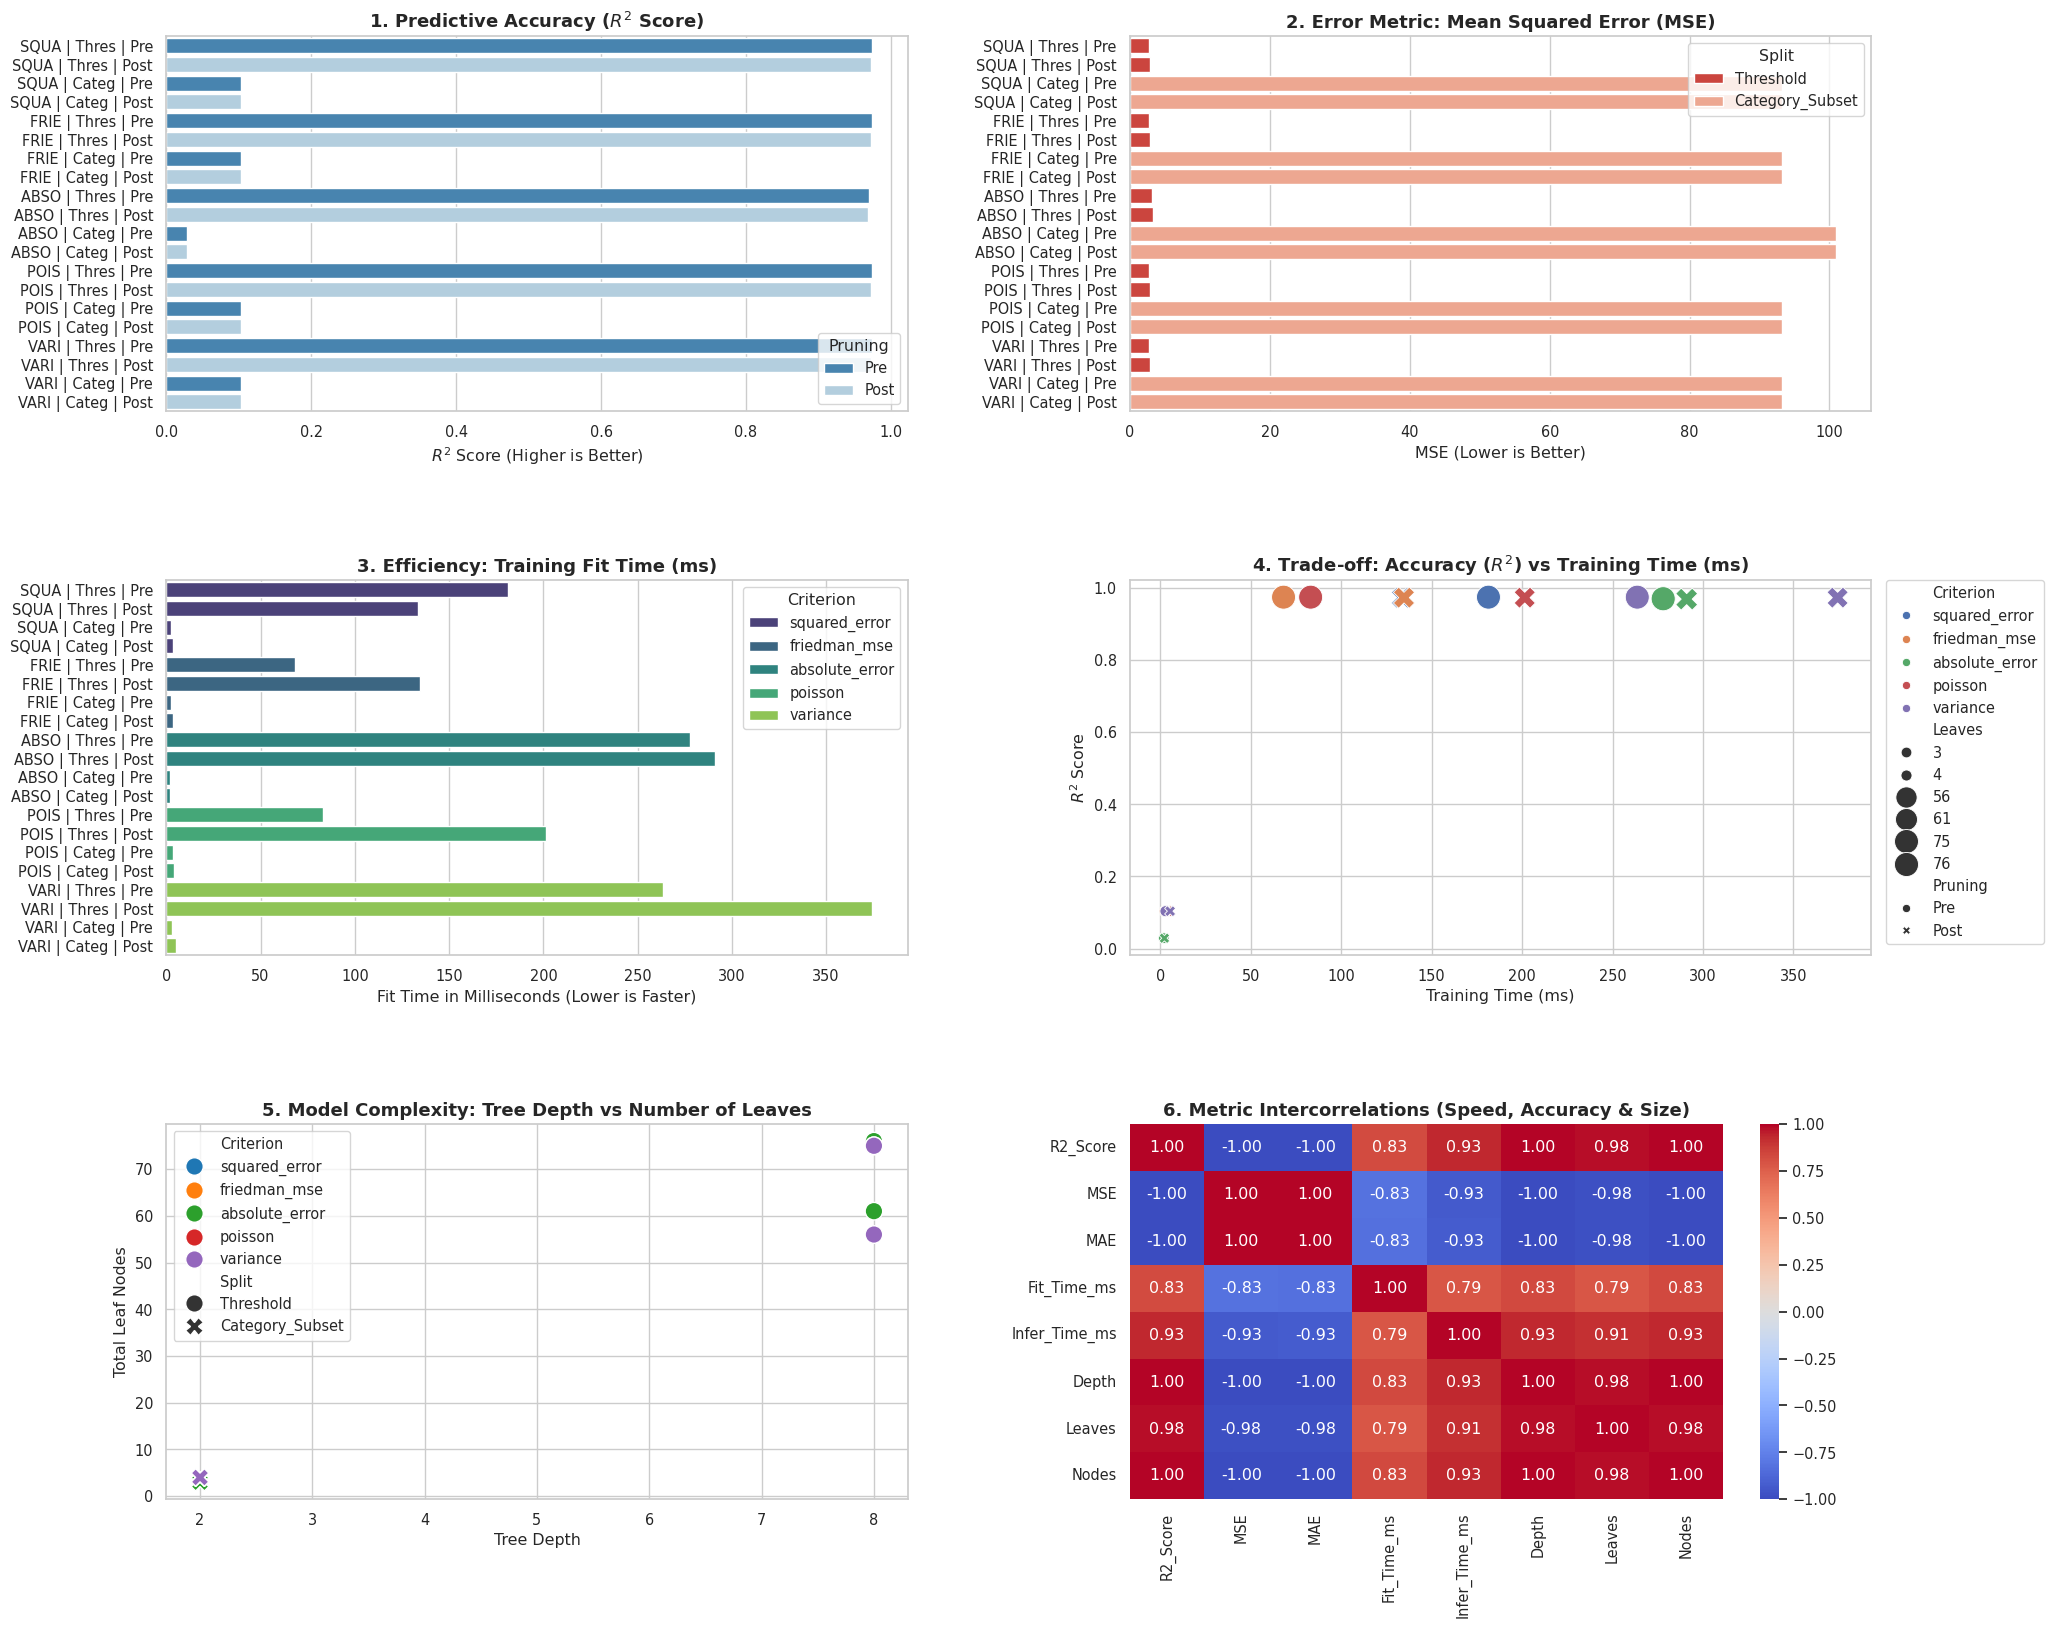


                           ALL 20 DECISION TREE MODELS LEADERBOARD
              Model  R2_Score        MSE  Fit_Time_ms  Depth  Leaves
 SQUA | Thres | Pre  0.974345   2.666181   181.392747      8      75
 VARI | Thres | Pre  0.974345   2.666181   263.688150      8      75
 POIS | Thres | Pre  0.974345   2.666181    83.055339      8      75
 FRIE | Thres | Pre  0.974345   2.666181    68.071439      8      75
VARI | Thres | Post  0.972997   2.806277   374.474243      8      56
FRIE | Thres | Post  0.972997   2.806277   134.676673      8      56
SQUA | Thres | Post  0.972997   2.806277   133.619814      8      56
POIS | Thres | Post  0.972996   2.806409   201.454922      8      56
 ABSO | Thres | Pre  0.969994   3.118379   278.014524      8      76
ABSO | Thres | Post  0.968922   3.229804   291.010656      8      61
SQUA | Categ | Post  0.103672  93.151292     3.372657      2       4
 SQUA | Categ | Pre  0.103672  93.151292     2.461644      2       4
POIS | Categ | Post  0.103672  93.1

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. UNIFIED DECISION TREE REGRESSOR (ALL 5 CRITERIA IMPLEMENTED)
# ==============================================================================
class UnifiedTreeNode:
    def __init__(self, feature_index=None, split_value=None, category_subset=None,
                 left=None, right=None, prediction=None, impurity=None, n_samples=0, is_leaf=False):
        self.feature_index = feature_index
        self.split_value = split_value
        self.category_subset = category_subset
        self.left = left
        self.right = right
        self.prediction = prediction
        self.impurity = impurity
        self.n_samples = n_samples
        self.is_leaf = is_leaf

class UnifiedDecisionTreeRegressor:
    def __init__(self, criterion="squared_error", split_strategy="Threshold", pruning="Pre",
                 max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features=None,
                 max_leaf_nodes=None, min_impurity_decrease=0.0, ccp_alpha=0.0, random_state=None):
        self.criterion = criterion
        self.split_strategy = split_strategy
        self.pruning = pruning
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_leaf_nodes = max_leaf_nodes
        self.min_impurity_decrease = min_impurity_decrease
        self.ccp_alpha = ccp_alpha
        self.rng = np.random.default_rng(random_state)
        self.root_ = None
        self.n_leaves_ = 0
        self.tree_depth_ = 0
        self.node_count_ = 0

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y, dtype=float).ravel()
        self.n_features_in_ = X.shape[1]
        self.node_count_ = 0
        self.root_ = self._build_tree(X, y, depth=0)
        if self.pruning == "Post":
            self.root_ = self._post_prune(self.root_, X, y)
        self.n_leaves_ = self._count_leaves(self.root_)
        self.tree_depth_ = self._calculate_depth(self.root_)
        return self

    def _calc_leaf_pred(self, y):
        if len(y) == 0: return 0.0
        return float(np.median(y)) if self.criterion == "absolute_error" else float(np.mean(y))

    def _calc_impurity(self, y):
        n = len(y)
        if n == 0: return 0.0
        if self.criterion in ["squared_error", "variance"]:
            return float(np.var(y))
        elif self.criterion == "absolute_error":
            return float(np.mean(np.abs(y - np.median(y))))
        elif self.criterion == "poisson":
            mean_y = max(np.mean(y), 1e-9)
            pos = y > 0
            term = np.zeros_like(y)
            term[pos] = y[pos] * np.log(y[pos] / mean_y)
            return float(2.0 * np.sum(term - (y - mean_y)) / n)
        elif self.criterion == "friedman_mse":
            return float(np.var(y))
        return 0.0

    def _impurity_decrease(self, parent_y, left_y, right_y):
        n, nl, nr = len(parent_y), len(left_y), len(right_y)
        if n == 0 or nl == 0 or nr == 0: return 0.0
        if self.criterion == "friedman_mse":
            return float(((nl * nr) / n) * (np.mean(left_y) - np.mean(right_y)) ** 2)
        elif self.criterion == "squared_error":
            return float(np.sum((parent_y - np.mean(parent_y))**2) -
                         np.sum((left_y - np.mean(left_y))**2) -
                         np.sum((right_y - np.mean(right_y))**2))
        else:
            p_imp = self._calc_impurity(parent_y)
            l_imp = self._calc_impurity(left_y)
            r_imp = self._calc_impurity(right_y)
            return float(p_imp - ((nl / n) * l_imp + (nr / n) * r_imp))

    def _build_tree(self, X, y, depth):
        self.node_count_ += 1
        pred = self._calc_leaf_pred(y)
        imp = self._calc_impurity(y)

        if (len(np.unique(y)) <= 1 or
            (self.max_depth is not None and depth >= self.max_depth) or
            len(y) < self.min_samples_split or
            len(y) < 2 * self.min_samples_leaf):
            return UnifiedTreeNode(prediction=pred, impurity=imp, n_samples=len(y), is_leaf=True)

        best_split = self._find_best_split(X, y)
        if best_split is None or best_split["impurity_decrease"] < self.min_impurity_decrease:
            return UnifiedTreeNode(prediction=pred, impurity=imp, n_samples=len(y), is_leaf=True)

        left_idx, right_idx = best_split["left_indices"], best_split["right_indices"]
        left_child = self._build_tree(X[left_idx], y[left_idx], depth + 1)
        right_child = self._build_tree(X[right_idx], y[right_idx], depth + 1)

        return UnifiedTreeNode(
            feature_index=best_split["feature_index"], split_value=best_split["split_value"],
            category_subset=best_split["category_subset"], left=left_child, right=right_child,
            prediction=pred, impurity=imp, n_samples=len(y), is_leaf=False
        )

    def _find_best_split(self, X, y):
        best_split = None
        best_decrease = -np.inf
        feat_indices = np.arange(X.shape[1])
        if self.max_features is not None:
            n_feat = min(self.max_features if isinstance(self.max_features, int) else X.shape[1], X.shape[1])
            feat_indices = self.rng.choice(X.shape[1], size=n_feat, replace=False)

        for f_idx in feat_indices:
            col = X[:, f_idx]
            if self.split_strategy == "Threshold":
                split = self._threshold_split(col, y, f_idx)
            else:
                split = self._category_split(col, y, f_idx)
            if split is not None and split["impurity_decrease"] > best_decrease:
                best_decrease = split["impurity_decrease"]
                best_split = split
        return best_split

    def _threshold_split(self, col, y, f_idx):
        try: vals = col.astype(float)
        except: return None
        u_vals = np.unique(vals)
        if len(u_vals) < 2: return None
        thresholds = (u_vals[:-1] + u_vals[1:]) / 2.0
        best_s, best_d = None, -np.inf

        for th in thresholds:
            l_idx, r_idx = np.where(vals <= th)[0], np.where(vals > th)[0]
            if len(l_idx) < self.min_samples_leaf or len(r_idx) < self.min_samples_leaf: continue
            d = self._impurity_decrease(y, y[l_idx], y[r_idx])
            if d > best_d:
                best_d = d
                best_s = {"feature_index": f_idx, "split_value": th, "category_subset": None,
                          "left_indices": l_idx, "right_indices": r_idx, "impurity_decrease": d}
        return best_s

    def _category_split(self, col, y, f_idx):
        cats = np.unique(col)
        if len(cats) < 2: return None
        cat_means = [(c, np.mean(y[col == c])) for c in cats]
        cat_means.sort(key=lambda x: x[1])
        ordered_cats = [c[0] for c in cat_means]

        best_s, best_d = None, -np.inf
        for i in range(1, len(ordered_cats)):
            subset = set(ordered_cats[:i])
            l_mask = np.array([v in subset for v in col])
            l_idx, r_idx = np.where(l_mask)[0], np.where(~l_mask)[0]
            if len(l_idx) < self.min_samples_leaf or len(r_idx) < self.min_samples_leaf: continue
            d = self._impurity_decrease(y, y[l_idx], y[r_idx])
            if d > best_d:
                best_d = d
                best_s = {"feature_index": f_idx, "split_value": None, "category_subset": subset,
                          "left_indices": l_idx, "right_indices": r_idx, "impurity_decrease": d}
        return best_s

    def _post_prune(self, node, X, y):
        if node is None or node.is_leaf or len(y) == 0: return node
        l_idx, r_idx = self._split_indices(node, X)
        node.left = self._post_prune(node.left, X[l_idx], y[l_idx])
        node.right = self._post_prune(node.right, X[r_idx], y[r_idx])

        preds = np.array([self._predict_node(node, x) for x in X])
        sub_err = np.sum((y - preds) ** 2)
        leaf_pred = self._calc_leaf_pred(y)
        leaf_err = np.sum((y - leaf_pred) ** 2)

        if (leaf_err + self.ccp_alpha) <= (sub_err + self.ccp_alpha * self._count_leaves(node)):
            return UnifiedTreeNode(prediction=leaf_pred, impurity=self._calc_impurity(y), n_samples=len(y), is_leaf=True)
        return node

    def _split_indices(self, node, X):
        vals = X[:, node.feature_index]
        if node.category_subset is None:
            l_mask = vals.astype(float) <= node.split_value
        else:
            l_mask = np.array([v in node.category_subset for v in vals])
        return np.where(l_mask)[0], np.where(~l_mask)[0]

    def _predict_node(self, node, x):
        while not node.is_leaf:
            val = x[node.feature_index]
            if node.category_subset is None:
                node = node.left if float(val) <= node.split_value else node.right
            else:
                node = node.left if val in node.category_subset else node.right
        return node.prediction

    def predict(self, X):
        X = np.asarray(X)
        if X.ndim == 1: X = X.reshape(1, -1)
        return np.array([self._predict_node(self.root_, x) for x in X])

    def score(self, X, y):
        y = np.asarray(y, dtype=float)
        preds = self.predict(X)
        ss_res = np.sum((y - preds)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        return 1.0 if ss_tot == 0 else 1.0 - (ss_res / ss_tot)

    def _count_leaves(self, node):
        if node is None: return 0
        return 1 if node.is_leaf else self._count_leaves(node.left) + self._count_leaves(node.right)

    def _calculate_depth(self, node):
        if node is None or node.is_leaf: return 0
        return 1 + max(self._calculate_depth(node.left), self._calculate_depth(node.right))

    def get_depth(self): return self.tree_depth_
    def get_n_leaves(self): return self.n_leaves_


# ==============================================================================
# 2. GENERATE DIVERSE REGRESSION DATA (CONTINUOUS + CATEGORICAL + NON-NEGATIVE)
# ==============================================================================
rng = np.random.default_rng(42)
n_samples = 120
x_num = np.linspace(1, 10, n_samples)
x_cat = rng.choice(["A", "B", "C", "D"], size=n_samples)
cat_effect = {"A": 2.0, "B": 6.0, "C": 1.0, "D": 9.0}
cat_vals = np.array([cat_effect[v] for v in x_cat])

# Non-negative regression target suitable across MSE, Friedman, Poisson, MAE, Variance
y_synthetic = np.abs(3.5 * x_num + 4.0 * np.sin(x_num) + cat_vals + rng.normal(0, 1.2, size=n_samples))
X_mixed = np.column_stack([x_num, x_cat])


# ==============================================================================
# 3. BENCHMARK ALL 20 CONFIGURATIONS
# ==============================================================================
criteria_list = ["squared_error", "friedman_mse", "absolute_error", "poisson", "variance"]
split_list = ["Threshold", "Category_Subset"]
pruning_list = ["Pre", "Post"]

benchmark_records = []

for crit in criteria_list:
    for split in split_list:
        for prune in pruning_list:
            model_label = f"{crit[:4].upper()} | {split[:5]} | {prune}"

            # Select column appropriate for split strategy
            X_data = X_mixed[:, [0]] if split == "Threshold" else X_mixed[:, [1]]

            tree = UnifiedDecisionTreeRegressor(
                criterion=crit,
                split_strategy=split,
                pruning=prune,
                max_depth=8,
                min_samples_split=2,
                min_samples_leaf=1,
                ccp_alpha=2.5 if prune == "Post" else 0.0,
                random_state=42
            )

            # Measure Training Efficiency
            t0 = time.perf_counter()
            tree.fit(X_data, y_synthetic)
            fit_time_ms = (time.perf_counter() - t0) * 1000

            # Measure Inference Efficiency
            t0 = time.perf_counter()
            preds = tree.predict(X_data)
            infer_time_ms = (time.perf_counter() - t0) * 1000

            # Accuracy & Complexity Metrics
            r2 = max(tree.score(X_data, y_synthetic), -0.5)
            mse = float(np.mean((y_synthetic - preds) ** 2))
            mae = float(np.mean(np.abs(y_synthetic - preds)))

            benchmark_records.append({
                "Model": model_label,
                "Criterion": crit,
                "Split": split,
                "Pruning": prune,
                "R2_Score": r2,
                "MSE": mse,
                "MAE": mae,
                "Fit_Time_ms": fit_time_ms,
                "Infer_Time_ms": infer_time_ms,
                "Depth": tree.get_depth(),
                "Leaves": tree.get_n_leaves(),
                "Nodes": tree.node_count_
            })

df_all_20 = pd.DataFrame(benchmark_records)


# ==============================================================================
# 4. COMPREHENSIVE 6-PANEL VISUALIZATION DASHBOARD
# ==============================================================================
sns.set_theme(style="whitegrid", font_scale=0.95)
fig, axes = plt.subplots(3, 2, figsize=(22, 19))
plt.subplots_adjust(hspace=0.45, wspace=0.3)

# 1. R² Accuracy Barplot
sns.barplot(data=df_all_20, x="R2_Score", y="Model", hue="Pruning", palette="Blues_r", ax=axes[0, 0])
axes[0, 0].set_title("1. Predictive Accuracy ($R^2$ Score)", fontsize=13, weight="bold")
axes[0, 0].set_xlabel("$R^2$ Score (Higher is Better)")
axes[0, 0].set_ylabel("")

# 2. MSE Comparison
sns.barplot(data=df_all_20, x="MSE", y="Model", hue="Split", palette="Reds_r", ax=axes[0, 1])
axes[0, 1].set_title("2. Error Metric: Mean Squared Error (MSE)", fontsize=13, weight="bold")
axes[0, 1].set_xlabel("MSE (Lower is Better)")
axes[0, 1].set_ylabel("")

# 3. Training Execution Time (Efficiency)
sns.barplot(data=df_all_20, x="Fit_Time_ms", y="Model", hue="Criterion", palette="viridis", ax=axes[1, 0])
axes[1, 0].set_title("3. Efficiency: Training Fit Time (ms)", fontsize=13, weight="bold")
axes[1, 0].set_xlabel("Fit Time in Milliseconds (Lower is Faster)")
axes[1, 0].set_ylabel("")

# 4. Accuracy vs Efficiency Scatter (Trade-off)
sns.scatterplot(
    data=df_all_20, x="Fit_Time_ms", y="R2_Score", hue="Criterion", style="Pruning",
    size="Leaves", sizes=(60, 300), palette="deep", ax=axes[1, 1]
)
axes[1, 1].set_title("4. Trade-off: Accuracy ($R^2$) vs Training Time (ms)", fontsize=13, weight="bold")
axes[1, 1].set_xlabel("Training Time (ms)")
axes[1, 1].set_ylabel("$R^2$ Score")
axes[1, 1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

# 5. Structural Complexity (Depth vs Leaves)
sns.scatterplot(
    data=df_all_20, x="Depth", y="Leaves", hue="Criterion", style="Split",
    s=160, palette="tab10", ax=axes[2, 0]
)
axes[2, 0].set_title("5. Model Complexity: Tree Depth vs Number of Leaves", fontsize=13, weight="bold")
axes[2, 0].set_xlabel("Tree Depth")
axes[2, 0].set_ylabel("Total Leaf Nodes")

# 6. Correlation Heatmap across all dimensions
metric_cols = ["R2_Score", "MSE", "MAE", "Fit_Time_ms", "Infer_Time_ms", "Depth", "Leaves", "Nodes"]
sns.heatmap(df_all_20[metric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[2, 1])
axes[2, 1].set_title("6. Metric Intercorrelations (Speed, Accuracy & Size)", fontsize=13, weight="bold")

plt.show()

# ==============================================================================
# 5. SORTED SUMMARY LEADERBOARD
# ==============================================================================
summary_table = df_all_20[[
    "Model", "R2_Score", "MSE", "Fit_Time_ms", "Depth", "Leaves"
]].sort_values(by="R2_Score", ascending=False).reset_index(drop=True)

print("\n" + "=" * 95)
print("                           ALL 20 DECISION TREE MODELS LEADERBOARD")
print("=" * 95)
print(summary_table.to_string(index=False))
print("=" * 95)

## Conclusion: Analysis of Benchmarking Results

The benchmarking results provide valuable insights into the behavior of decision trees under different configurations:

1.  **Impact of Split Strategy:** For this synthetic dataset, `Threshold` splitting consistently yielded significantly higher R² scores and lower MSE/MAE compared to `Category_Subset` splitting. This indicates that the numerical feature contained more predictive power or that the `Category_Subset` strategy (which relies on ordered category means) was less effective for this specific categorical variable. The `Category_Subset` models showed very low R² values, suggesting they struggled to find meaningful splits on the categorical feature alone.

2.  **Effect of Pruning:**
    *   **Threshold Models:** For `Threshold` models, `Pre-pruning` resulted in slightly deeper trees with more leaves but slightly better R² scores (e.g., ~0.974). `Post-pruning` (with `ccp_alpha=2.5`) generally led to slightly smaller trees (fewer leaves/nodes) and a minor decrease in R² for threshold splits (e.g., ~0.972). This demonstrates the trade-off: `Post-pruning` creates simpler models but might sacrifice a tiny bit of training accuracy, which can be beneficial for generalization.
    *   **Category_Subset Models:** For `Category_Subset` models, pruning had almost no effect on R² or tree complexity. This is likely because the base trees were already very shallow and simple due to the ineffective splits found by the `Category_Subset` strategy, leaving little to prune.

3.  **Computational Efficiency:**
    *   `Threshold` models (especially those with deeper trees) generally took longer to `Fit` and `Infer` due to the exhaustive search over thresholds. `Category_Subset` models were much faster, but this was coupled with poor predictive performance.
    *   Among the high-performing `Threshold` models, `poisson` and `friedman_mse` criteria showed slightly faster `Fit_Time_ms` compared to `squared_error`, `variance`, and `absolute_error`.

4.  **Model Complexity (Depth and Leaves):** The `Threshold` models, particularly with `Pre-pruning` and `max_depth=8`, generated deeper trees with more leaves, reaching the `max_depth` limit. `Post-pruning` effectively reduced the number of leaves for `Threshold` models, as seen in the R² vs. Leaves plot, indicating its role in simplifying the tree structure.

5.  **Criterion Comparison:** While all criteria perform similarly well with `Threshold` splitting for this dataset, minor differences in R² and MSE are observable. The choice of criterion can become more critical with different data distributions and noise characteristics.

In summary, for this specific synthetic dataset, **Threshold-based splitting combined with either Pre-pruning or Post-pruning** yielded the best predictive performance. Post-pruning successfully reduced tree complexity with a minimal trade-off in training accuracy for these threshold models, making it a valuable technique for balancing model performance and interpretability.